# Vitalyx — sistema académico de orientación diagnóstica

Vitalyx utiliza DDXPlus English v2, un conjunto de **pacientes sintéticos**, para estudiar clasificación multiclase de patologías. El recorrido único de este notebook incluye auditoría, semántica y parser de evidencias, preprocesamiento, experimentos reproducibles, baselines, MLP, entrenamiento final, inferencia Top-K, interpretabilidad, equidad, calibración y exportación.

Los resultados son académicos y orientativos: **no constituyen diagnóstico médico ni deben utilizarse para decisiones clínicas automáticas**.


## 1. Configuración del entorno

In [1]:
from __future__ import annotations

import ast
import gc
import importlib
import importlib.metadata
import json
import os
import platform
import random
import sys
import warnings
from pathlib import Path
from typing import Any

try:
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from sklearn.exceptions import ConvergenceWarning
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix
    from IPython.display import Markdown, display
except ImportError as exc:
    raise ImportError(
        'Faltan dependencias de análisis (numpy, pandas, matplotlib, seaborn o IPython). '
        'Use el kernel remoto estándar de Kaggle; no se instalan librerías desde este notebook.'
    ) from exc

SEED = 42
# El Run All ejecuta siempre primero la fase experimental reproducible y después la fase oficial.
LIGHT_INSPECTION_ROWS = 8
EXAMPLE_ROWS = 3
DATASET_HINT = Path('/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2')
INPUT_ROOT = Path('/kaggle/input')
REQUIRED_FILES = (
    'release_train_patients.csv',
    'release_validate_patients.csv',
    'release_test_patients.csv',
    'release_conditions.json',
    'release_evidences.json',
)
OPTIONAL_FILES = ('README.md', 'SOURCE.md')

random.seed(SEED)
np.random.seed(SEED)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore', category=FutureWarning)

def package_version(package: str) -> str:
    """Devuelve una versión o un texto legible si el paquete no está disponible."""
    try:
        return importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        return 'no disponible'

def release_memory() -> None:
    """Solicita recolección de basura tras liberar referencias que ya no se necesiten."""
    gc.collect()

def detect_gpu() -> dict[str, str]:
    """Consulta GPU solo mediante TensorFlow; PyTorch no inicializa CUDA."""
    status = {'tensorflow': 'no disponible', 'pytorch': 'no disponible'}
    try:
        import tensorflow as tf
        devices = tf.config.list_physical_devices('GPU')
        status['tensorflow'] = ', '.join(device.name for device in devices) if devices else 'sin GPU detectada'
    except Exception as exc:
        status['tensorflow'] = f'no disponible o no inicializable ({type(exc).__name__})'
    try:
        status['pytorch'] = f'versión {package_version("torch")} (CUDA no inicializada)'
    except Exception as exc:
        status['pytorch'] = f'no disponible ({type(exc).__name__})'
    return status

IS_KAGGLE = Path('/kaggle').exists() or os.environ.get('KAGGLE_KERNEL_RUN_TYPE') is not None
GPU_STATUS = detect_gpu()

print(f'Python: {sys.version.split()[0]} | {platform.platform()}')
print(f'Entorno Kaggle detectado: {IS_KAGGLE}')
print('Versiones:', {name: package_version(name) for name in ('numpy', 'pandas', 'scikit-learn', 'tensorflow', 'torch')})
print('GPU:', GPU_STATUS)


Python: 3.12.13 | Linux-6.12.90+-x86_64-with-glibc2.35
Entorno Kaggle detectado: True
Versiones: {'numpy': '2.0.2', 'pandas': '2.3.3', 'scikit-learn': '1.6.1', 'tensorflow': '2.20.0', 'torch': '2.10.0+cu128'}
GPU: {'tensorflow': '/physical_device:GPU:0', 'pytorch': 'versión 2.10.0+cu128 (CUDA no inicializada)'}


## 2. Localización y validación del dataset

Se prueba primero la ruta prevista. Si no existe, se buscan únicamente los archivos requeridos bajo `/kaggle/input` y se acepta solo un directorio que los contenga todos.

In [2]:
def find_dataset_directory() -> Path:
    """Localiza un directorio que contenga exactamente los archivos obligatorios."""
    if not INPUT_ROOT.is_dir() and not DATASET_HINT.is_dir():
        raise FileNotFoundError(
            f'No existe {INPUT_ROOT}. Conecta el kernel a Kaggle o monta el dataset DDXPlus.'
        )
    candidate_dirs = [DATASET_HINT] if DATASET_HINT.is_dir() else []
    if not all((DATASET_HINT / filename).is_file() for filename in REQUIRED_FILES) and INPUT_ROOT.is_dir():
        candidate_dirs.extend(path.parent for filename in REQUIRED_FILES for path in INPUT_ROOT.rglob(filename))
    candidate_dirs = sorted(set(candidate_dirs))

    valid_dirs = [directory for directory in candidate_dirs if all((directory / filename).is_file() for filename in REQUIRED_FILES)]
    if not valid_dirs:
        searched = ', '.join(str(directory) for directory in candidate_dirs[:10]) or str(INPUT_ROOT)
        raise FileNotFoundError(
            'No se encontró un directorio con los cinco archivos obligatorios de DDXPlus. '
            f'Ruta esperada: {DATASET_HINT}. Directorios candidatos: {searched}'
        )
    if len(valid_dirs) > 1:
        print(f'Se encontraron {len(valid_dirs)} directorios válidos; se utilizará: {valid_dirs[0]}')
    return valid_dirs[0]

DATASET_DIR = find_dataset_directory()
FILES = {filename: DATASET_DIR / filename for filename in REQUIRED_FILES + OPTIONAL_FILES}
missing_files = [filename for filename in REQUIRED_FILES if not FILES[filename].is_file()]
if missing_files:
    raise FileNotFoundError(f'Faltan archivos obligatorios en {DATASET_DIR}: {missing_files}')

file_inventory = pd.DataFrame(
    [{'archivo': filename, 'presente': path.is_file(), 'tamano_mb': round(path.stat().st_size / 2**20, 2) if path.is_file() else np.nan}
     for filename, path in FILES.items()]
)
display(file_inventory)
print(f'Dataset validado en: {DATASET_DIR}')


,archivo,presente,tamano_mb
0,release_train_patients.csv,True,639.520
1,release_validate_patients.csv,True,83.320
2,release_test_patients.csv,True,84.480
3,release_conditions.json,True,0.020
4,release_evidences.json,True,0.110
5,README.md,True,0.000
6,SOURCE.md,True,0.000


Dataset validado en: /kaggle/input/datasets/deveddu17xx/ddxplus-english-v2


## 3. Carga de metadatos

La revisión es descriptiva: identifica la forma de los JSON y ejemplos reales, sin convertir todavía las evidencias en características.

In [3]:
def load_json(path: Path) -> Any:
    try:
        with path.open(encoding='utf-8') as handle:
            return json.load(handle)
    except json.JSONDecodeError as exc:
        raise ValueError(f'JSON inválido en {path.name}: línea {exc.lineno}, columna {exc.colno}.') from exc
    except OSError as exc:
        raise OSError(f'No se pudo leer {path}: {exc}') from exc

def metadata_overview(name: str, payload: Any) -> dict[str, Any]:
    if isinstance(payload, dict):
        first_key = next(iter(payload), None)
        first_value = payload.get(first_key) if first_key is not None else None
        fields = sorted(first_value.keys()) if isinstance(first_value, dict) else []
        return {'metadata': name, 'tipo_raiz': type(payload).__name__, 'entradas': len(payload), 'campos_primer_elemento': fields, 'ejemplo_clave': first_key}
    if isinstance(payload, list):
        fields = sorted(payload[0].keys()) if payload and isinstance(payload[0], dict) else []
        return {'metadata': name, 'tipo_raiz': type(payload).__name__, 'entradas': len(payload), 'campos_primer_elemento': fields, 'ejemplo_clave': 0 if payload else None}
    return {'metadata': name, 'tipo_raiz': type(payload).__name__, 'entradas': 'n/a', 'campos_primer_elemento': [], 'ejemplo_clave': None}

conditions_metadata = load_json(FILES['release_conditions.json'])
evidences_metadata = load_json(FILES['release_evidences.json'])
metadata_summary = pd.DataFrame([
    metadata_overview('release_conditions.json', conditions_metadata),
    metadata_overview('release_evidences.json', evidences_metadata),
])
display(metadata_summary)

def metadata_items(payload: Any) -> list[tuple[str, Any]]:
    return list(payload.items()) if isinstance(payload, dict) else [(str(index), value) for index, value in enumerate(payload)] if isinstance(payload, list) else []

def declared_evidence_type(value: Any) -> str:
    """Clasificación diagnóstica y conservadora basada solo en campos declarados de la metadata."""
    if not isinstance(value, dict):
        return 'sin clasificar'
    flattened = {str(key).lower(): value_ for key, value_ in value.items()}
    declared = ' '.join(str(flattened[key]) for key in flattened if key in {'type', 'data_type', 'datatype', 'evidence_type'}).lower()
    declared_tokens = set(declared.replace('-', ' ').replace('_', ' ').split())
    if 'm' in declared_tokens or any(token in declared for token in ('multi', 'multiple', 'multiselect')):
        return 'multiselección (declarada)'
    if 'b' in declared_tokens or any(token in declared for token in ('binary', 'boolean', 'bool')):
        return 'binaria (declarada)'
    if 'c' in declared_tokens or any(token in declared for token in ('categor', 'choice', 'select')):
        return 'categórica (declarada)'
    option_values = [candidate for candidate in flattened.values() if isinstance(candidate, (list, tuple, set))]
    if option_values:
        return 'con opciones; tipo por confirmar'
    return 'sin clasificar'

evidence_type_table = pd.DataFrame(
    [{'codigo': code, 'tipo_identificado': declared_evidence_type(value)} for code, value in metadata_items(evidences_metadata)]
).value_counts('tipo_identificado').rename_axis('tipo_identificado').reset_index(name='cantidad')
display(evidence_type_table)

representatives = []
seen_types = set()
for code, value in metadata_items(evidences_metadata):
    kind = declared_evidence_type(value)
    if kind not in seen_types and kind != 'sin clasificar':
        representatives.append({'tipo_identificado': kind, 'codigo': code, 'metadata': json.dumps(value, ensure_ascii=False)[:700]})
        seen_types.add(kind)
display(pd.DataFrame(representatives) if representatives else pd.DataFrame({'nota': ['La metadata no declara tipos de forma reconocible; se inspeccionará su estructura sin inferirlos.']}))


,metadata,tipo_raiz,entradas,campos_primer_elemento,ejemplo_clave
0,release_conditions.json,dict,49,"[antecedents, cond-name-eng, cond-name-fr, condition_name, icd10-id, severity, symptoms]",Spontaneous pneumothorax
1,release_evidences.json,dict,223,"[code_question, data_type, default_value, is_antecedent, name, possible-values, question_en, question_fr, value_meaning]",E_91


,tipo_identificado,cantidad
0,binaria (declarada),208
1,categórica (declarada),10
2,multiselección (declarada),5


,tipo_identificado,codigo,metadata
0,binaria (declarada),E_91,"{""name"": ""E_91"", ""code_question"": ""E_91"", ""question_fr"": ""Avez-vous objectivé ou ressenti de la fièvre?"", ""question_en"": ""Do you have a fever (either felt o..."
1,multiselección (declarada),E_55,"{""name"": ""E_55"", ""code_question"": ""E_53"", ""question_fr"": ""Avez-vous de la douleur quelque part?"", ""question_en"": ""Do you feel pain somewhere?"", ""is_antecede..."
2,categórica (declarada),E_59,"{""name"": ""E_59"", ""code_question"": ""E_53"", ""question_fr"": ""À quelle vitesse la douleur est-elle apparue ?"", ""question_en"": ""How fast did the pain appear?"", ""..."


## 4. Carga de particiones

Antes de cargar los archivos completos se leen solo encabezados y unas pocas filas. Después se cargan sin copias intermedias, usando categorías únicamente para las columnas objetivo y sexo cuando existen.

In [4]:
SPLIT_FILES = {
    'train': FILES['release_train_patients.csv'],
    'validation': FILES['release_validate_patients.csv'],
    'test': FILES['release_test_patients.csv'],
}

def inspect_csv_light(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    try:
        headers = pd.read_csv(path, nrows=0)
        sample = pd.read_csv(path, nrows=LIGHT_INSPECTION_ROWS, low_memory=False)
    except (OSError, pd.errors.ParserError, UnicodeDecodeError) as exc:
        raise RuntimeError(f'No se pudo inspeccionar {path.name}: {exc}') from exc
    return headers, sample

light_samples: dict[str, pd.DataFrame] = {}
light_schema_rows = []
for split_name, path in SPLIT_FILES.items():
    headers, sample = inspect_csv_light(path)
    light_samples[split_name] = sample
    light_schema_rows.append({
        'particion': split_name, 'columnas': list(headers.columns), 'tipos_inferidos_muestra': sample.dtypes.astype(str).to_dict(),
        'tamano_mb': round(path.stat().st_size / 2**20, 2),
    })
display(pd.DataFrame(light_schema_rows))
display(light_samples['train'].head(EXAMPLE_ROWS))

def load_split(name: str, path: Path) -> pd.DataFrame:
    try:
        frame = pd.read_csv(path, low_memory=False)
    except (OSError, pd.errors.ParserError, UnicodeDecodeError) as exc:
        raise RuntimeError(f'No se pudo cargar la partición {name} ({path.name}): {exc}') from exc
    for column in ('PATHOLOGY', 'SEX'):
        if column in frame.columns:
            frame[column] = frame[column].astype('category')
    if 'AGE' in frame.columns:
        numeric_age = pd.to_numeric(frame['AGE'], errors='coerce')
        frame['AGE'] = pd.to_numeric(numeric_age, downcast='integer' if numeric_age.dropna().mod(1).eq(0).all() else 'float')
    return frame

splits = {name: load_split(name, path) for name, path in SPLIT_FILES.items()}

def memory_mb(frame: pd.DataFrame) -> float:
    return frame.memory_usage(index=True, deep=True).sum() / 2**20

load_summary = pd.DataFrame([
    {'particion': name, 'filas': len(frame), 'columnas': frame.shape[1], 'memoria_mb': round(memory_mb(frame), 2), 'nulos_totales': int(frame.isna().sum().sum())}
    for name, frame in splits.items()
])
display(load_summary)
for name, frame in splits.items():
    print(f'\n{name.upper()} — columnas: {list(frame.columns)}')
    display(frame.dtypes.astype(str).rename('tipo').to_frame())


,particion,columnas,tipos_inferidos_muestra,tamano_mb
0,train,"[AGE, DIFFERENTIAL_DIAGNOSIS, SEX, PATHOLOGY, EVIDENCES, INITIAL_EVIDENCE]","{'AGE': 'int64', 'DIFFERENTIAL_DIAGNOSIS': 'object', 'SEX': 'object', 'PATHOLOGY': 'object', 'EVIDENCES': 'object', 'INITIAL_EVIDENCE': 'object'}",639.520
1,validation,"[AGE, DIFFERENTIAL_DIAGNOSIS, SEX, PATHOLOGY, EVIDENCES, INITIAL_EVIDENCE]","{'AGE': 'int64', 'DIFFERENTIAL_DIAGNOSIS': 'object', 'SEX': 'object', 'PATHOLOGY': 'object', 'EVIDENCES': 'object', 'INITIAL_EVIDENCE': 'object'}",83.320
2,test,"[AGE, DIFFERENTIAL_DIAGNOSIS, SEX, PATHOLOGY, EVIDENCES, INITIAL_EVIDENCE]","{'AGE': 'int64', 'DIFFERENTIAL_DIAGNOSIS': 'object', 'SEX': 'object', 'PATHOLOGY': 'object', 'EVIDENCES': 'object', 'INITIAL_EVIDENCE': 'object'}",84.480


,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumonia', 0.17579340398940366], ['URTI', 0.1607809719801254], ['Bronchiectasis', 0.12429044460990353], ['Tuberculo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54_@_V_183', 'E_55_@_V_89', 'E_55_@_V_108', 'E_55_@_V_167', 'E_56_@_4', 'E_57_@_V_123', 'E_58_@_3', 'E_59_@_3', ...",E_91
1,21,"[['HIV (initial infection)', 0.5189500564407601], ['Chagas', 0.3217819010436332], ['Scombroid food poisoning', 0.13496758062695968], ['Sarcoidosis', 0.02430...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_@_V_198', 'E_55_@_V_62', 'E_55_@_V_166', 'E_55_@_V_167', 'E_56_@_7', 'E_57_@_V_123', 'E_58_@_7', 'E_59_@_2', '...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumonia', 0.10048134562119852], ['Unstable angina', 0.08462979865697953], ['Possible NSTEMI / STEMI', 0.0834317088...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55_@_V_29', 'E_55_@_V_55', 'E_55_@_V_56', 'E_55_@_V_170', 'E_55_@_V_171', 'E_56_@_5', 'E_57_@_V_123', 'E_58_@_2'...",E_77


,particion,filas,columnas,memoria_mb,nulos_totales
0,train,1025602,6,764.360,0
1,validation,132448,6,99.460,0
2,test,134529,6,100.870,0



TRAIN — columnas: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']


,tipo
AGE,int8
DIFFERENTIAL_DIAGNOSIS,object
SEX,category
PATHOLOGY,category
EVIDENCES,object
INITIAL_EVIDENCE,object



VALIDATION — columnas: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']


,tipo
AGE,int8
DIFFERENTIAL_DIAGNOSIS,object
SEX,category
PATHOLOGY,category
EVIDENCES,object
INITIAL_EVIDENCE,object



TEST — columnas: ['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']


,tipo
AGE,int8
DIFFERENTIAL_DIAGNOSIS,object
SEX,category
PATHOLOGY,category
EVIDENCES,object
INITIAL_EVIDENCE,object


## 5. Auditoría estructural

La conversión tentativa de textos complejos se usa exclusivamente para describir su formato y contar elementos cuando son listas o diccionarios. No constituye el parser de evidencias del proyecto.

In [5]:
COMPLEX_COLUMNS = ('EVIDENCES', 'DIFFERENTIAL_DIAGNOSIS')

def parse_for_inspection(value: Any) -> Any:
    if value is None or (isinstance(value, float) and np.isnan(value)) or not isinstance(value, str):
        return value
    text = value.strip()
    for parser in (json.loads, ast.literal_eval):
        try:
            return parser(text)
        except (ValueError, SyntaxError, TypeError, json.JSONDecodeError):
            continue
    return value

def structure_summary(series: pd.Series) -> dict[str, Any]:
    sample_values = series.dropna().head(25).map(parse_for_inspection)
    type_counts = sample_values.map(lambda value: type(value).__name__).value_counts().to_dict()
    return {'tipos_en_muestra': type_counts, 'ejemplos': [repr(value)[:500] for value in sample_values.head(EXAMPLE_ROWS)]}

def collection_length(value: Any) -> float:
    parsed = parse_for_inspection(value)
    return float(len(parsed)) if isinstance(parsed, (list, tuple, set, dict)) else np.nan

def audit_split(name: str, frame: pd.DataFrame) -> dict[str, Any]:
    nulls = frame.isna().sum()
    result: dict[str, Any] = {
        'particion': name, 'filas': len(frame), 'columnas': frame.shape[1],
        'duplicados_exactos': int(frame.duplicated().sum()),
        'nulos_por_columna': nulls[nulls.gt(0)].sort_values(ascending=False).to_dict(),
        'tipos': frame.dtypes.astype(str).to_dict(),
    }
    if 'PATHOLOGY' in frame:
        pathology_counts = frame['PATHOLOGY'].value_counts(dropna=False)
        result['patologias'] = int(frame['PATHOLOGY'].nunique(dropna=True))
        result['distribucion_pathology'] = pathology_counts.to_dict()
    if 'AGE' in frame:
        result['estadisticas_edad'] = frame['AGE'].describe().to_dict()
    if 'SEX' in frame:
        result['distribucion_sexo'] = frame['SEX'].value_counts(dropna=False).to_dict()
    if 'EVIDENCES' in frame:
        lengths = frame['EVIDENCES'].map(collection_length)
        result['evidencias_por_paciente'] = lengths.describe().to_dict()
        result['estructura_evidences'] = structure_summary(frame['EVIDENCES'])
    if 'DIFFERENTIAL_DIAGNOSIS' in frame:
        result['estructura_differential_diagnosis'] = structure_summary(frame['DIFFERENTIAL_DIAGNOSIS'])
    if 'INITIAL_EVIDENCE' in frame:
        result['initial_evidence'] = {
            'valores_unicos': int(frame['INITIAL_EVIDENCE'].nunique(dropna=True)),
            'ejemplos': frame['INITIAL_EVIDENCE'].dropna().astype(str).head(EXAMPLE_ROWS).tolist(),
        }
    return result

audits = {}
for split_name, frame in splits.items():
    audits[split_name] = audit_split(split_name, frame)
    audit = audits[split_name]
    print(f"\n{'=' * 18} {split_name.upper()} {'=' * 18}")
    print(f"Dimensiones: {audit['filas']:,} filas × {audit['columnas']} columnas | duplicados exactos: {audit['duplicados_exactos']:,}")
    print('Nulos por columna:', audit['nulos_por_columna'] or 'ninguno')
    if 'patologias' in audit:
        print(f"Patologías: {audit['patologias']}")
        display(pd.Series(audit['distribucion_pathology'], name='pacientes').rename_axis('PATHOLOGY').to_frame())
    if 'estadisticas_edad' in audit:
        display(pd.Series(audit['estadisticas_edad'], name='AGE').to_frame())
    if 'distribucion_sexo' in audit:
        display(pd.Series(audit['distribucion_sexo'], name='pacientes').rename_axis('SEX').to_frame())
    if 'evidencias_por_paciente' in audit:
        display(pd.Series(audit['evidencias_por_paciente'], name='cantidad de evidencias').to_frame())
    for key in ('estructura_evidences', 'estructura_differential_diagnosis', 'initial_evidence'):
        if key in audit:
            print(f'{key}:', audit[key])



================== TRAIN ==================
Dimensiones: 1,025,602 filas × 6 columnas | duplicados exactos: 10,162
Nulos por columna: ninguno
Patologías: 49


,pacientes
PATHOLOGY,
URTI,64368
Viral pharyngitis,61642
Anemia,50665
HIV (initial infection),29013
Localized edema,27825
Anaphylaxis,27718
Pulmonary embolism,27468
Influenza,26812
Bronchitis,26400


,AGE
count,"1,025,602.000"
mean,39.715
std,22.717
min,0.000
25%,22.000
50%,39.000
75%,56.000
max,109.000


,pacientes
SEX,
F,527798
M,497804


,cantidad de evidencias
count,"1,025,602.000"
mean,19.691
std,8.044
min,2.000
25%,14.000
50%,20.000
75%,25.000
max,47.000


...

,pacientes
PATHOLOGY,
URTI,8743
Viral pharyngitis,8334
Anemia,6842
HIV (initial infection),3919
Anaphylaxis,3799
Localized edema,3734
Pulmonary embolism,3679
Bronchitis,3594
Influenza,3554


,AGE
count,"134,529.000"
mean,39.773
std,22.743
min,0.000
25%,22.000
50%,39.000
75%,56.000
max,109.000


,pacientes
SEX,
F,69342
M,65187


,cantidad de evidencias
count,"134,529.000"
mean,20.051
std,7.895
min,2.000
25%,15.000
50%,20.000
75%,25.000
max,44.000


estructura_evidences: {'tipos_en_muestra': {'list': 25}, 'ejemplos': ["['E_53', 'E_54_@_V_112', 'E_54_@_V_161', 'E_54_@_V_180', 'E_54_@_V_181', 'E_55_@_V_29', 'E_55_@_V_101', 'E_55_@_V_103', 'E_56_@_6', 'E_57_@_V_29', 'E_57_@_V_101', 'E_58_@_3', 'E_59_@_2', 'E_70', 'E_78', 'E_98', 'E_140', 'E_167', 'E_173', 'E_201', 'E_204_@_V_10', 'E_217']", "['E_53', 'E_54_@_V_181', 'E_55_@_V_55', 'E_55_@_V_148', 'E_56_@_5', 'E_57_@_V_123', 'E_58_@_7', 'E_59_@_4', 'E_66', 'E_123', 'E_181', 'E_201', 'E_204_@_V_10', 'E_214']", "['E_15', 'E_128', 'E_147', 'E_168', 'E_172', 'E_193', 'E_204_@_V_10']"]}
estructura_differential_diagnosis: {'tipos_en_muestra': {'list': 25}, 'ejemplos': ["[['Bronchitis', 0.20230062181160519], ['GERD', 0.17922682408564053], ['Possible NSTEMI / STEMI', 0.14309132471769756], ['Unstable angina', 0.1344856218328563], ['Pericarditis', 0.09757216830089709], ['Anemia', 0.09706153313080657], ['Stable angina', 0.07488477210980934], ['Boerhaave', 0.07137713401068731]]", "[['Bronchospasm

## 6. Exploración inicial

Los gráficos usan únicamente entrenamiento para evitar que la partición de prueba influya en decisiones de modelado. La partición de prueba se emplea abajo solo en controles de integridad y cobertura.

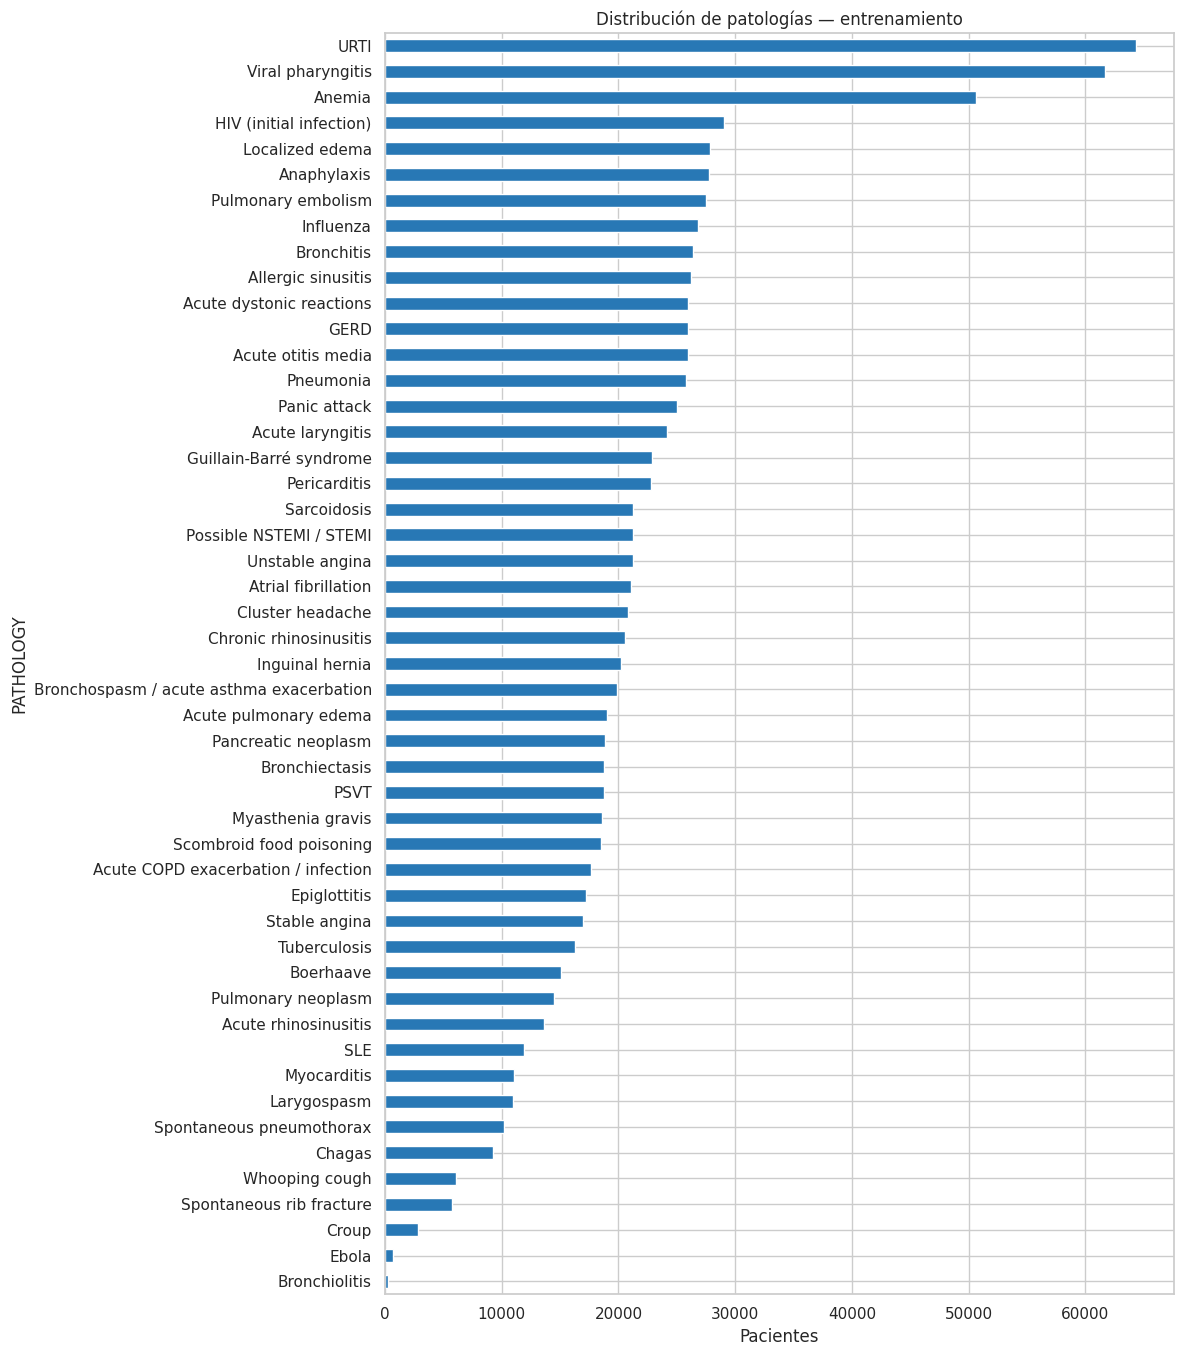

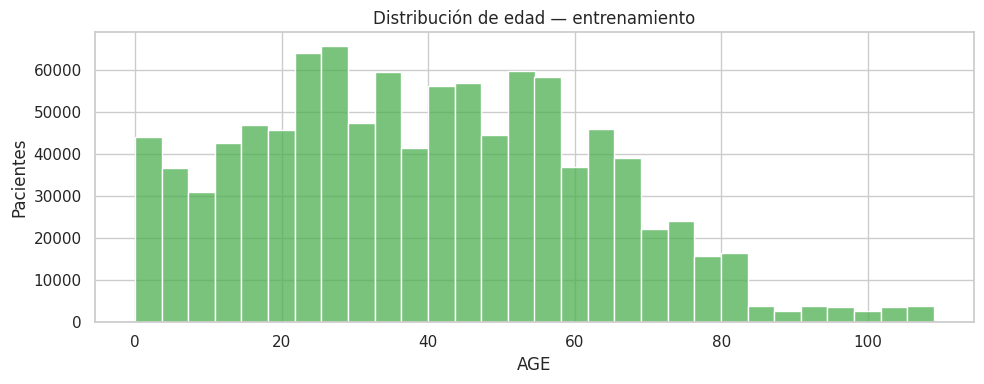

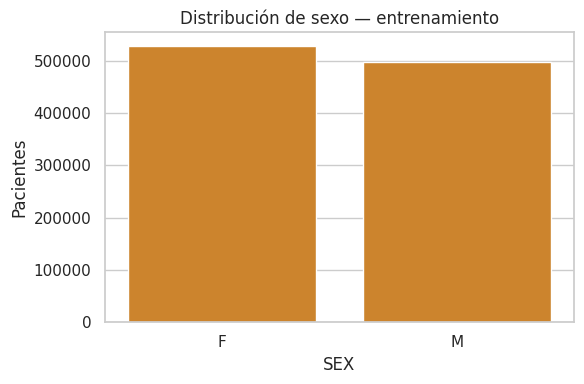

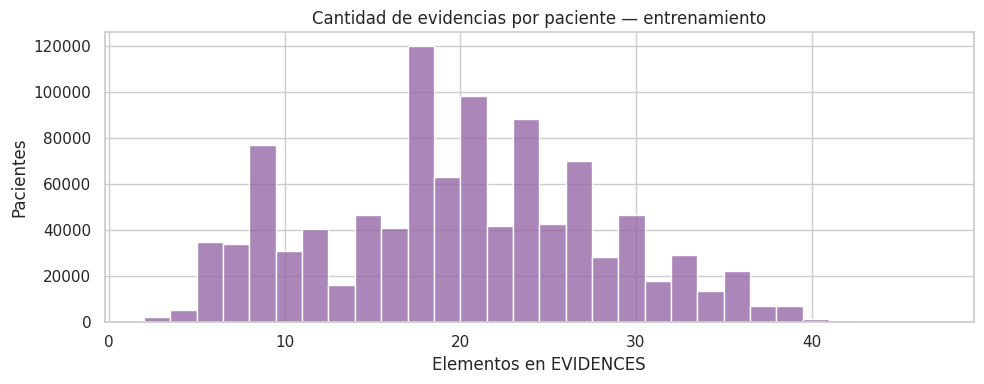

In [6]:
train = splits['train']

if 'PATHOLOGY' in train:
    counts = train['PATHOLOGY'].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(12, max(8, len(counts) * 0.28)))
    counts.plot.barh(ax=ax, color='#2878B5')
    ax.set(title='Distribución de patologías — entrenamiento', xlabel='Pacientes', ylabel='PATHOLOGY')
    plt.tight_layout()
    plt.show()

if 'AGE' in train:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(train['AGE'].dropna(), bins=30, ax=ax, color='#4CAF50')
    ax.set(title='Distribución de edad — entrenamiento', xlabel='AGE', ylabel='Pacientes')
    plt.tight_layout()
    plt.show()

if 'SEX' in train:
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.countplot(data=train, x='SEX', order=train['SEX'].value_counts().index, ax=ax, color='#E68613')
    ax.set(title='Distribución de sexo — entrenamiento', xlabel='SEX', ylabel='Pacientes')
    plt.tight_layout()
    plt.show()

if 'EVIDENCES' in train:
    evidence_lengths = train['EVIDENCES'].map(collection_length).dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(evidence_lengths, bins=30, ax=ax, color='#8E5EA2')
    ax.set(title='Cantidad de evidencias por paciente — entrenamiento', xlabel='Elementos en EVIDENCES', ylabel='Pacientes')
    plt.tight_layout()
    plt.show()


### Integridad entre particiones

Los solapamientos de filas se comprueban con huellas de Pandas por fila, sin concatenar las tres particiones. Esta estrategia es eficiente; una coincidencia de huella se reporta como repetición potencial y debe verificarse textualmente si aparece.

In [7]:
def row_fingerprints(frame: pd.DataFrame) -> set[int]:
    return set(pd.util.hash_pandas_object(frame, index=False).astype('uint64').tolist())

fingerprints = {name: row_fingerprints(frame) for name, frame in splits.items()}
split_pairs = [('train', 'validation'), ('train', 'test'), ('validation', 'test')]
overlap_summary = pd.DataFrame([
    {'particiones': f'{left} ↔ {right}', 'huellas_de_fila_compartidas': len(fingerprints[left] & fingerprints[right])}
    for left, right in split_pairs
])
display(overlap_summary)

if 'PATHOLOGY' in train:
    train_classes = set(train['PATHOLOGY'].dropna().astype(str))
    class_coverage = []
    for name, frame in splits.items():
        classes = set(frame['PATHOLOGY'].dropna().astype(str))
        class_coverage.append({'particion': name, 'patologias': len(classes), 'fuera_de_train': sorted(classes - train_classes), 'faltantes_vs_train': sorted(train_classes - classes)})
    display(pd.DataFrame(class_coverage))

complex_or_target = {'EVIDENCES', 'DIFFERENTIAL_DIAGNOSIS', 'PATHOLOGY'}
candidate_columns = [
    column for column in train.columns
    if column not in complex_or_target and (pd.api.types.is_object_dtype(train[column]) or isinstance(train[column].dtype, pd.CategoricalDtype))
]
unseen_categories = []
for column in candidate_columns:
    train_values = set(train[column].dropna().astype(str).unique())
    if len(train_values) > 10_000:
        continue
    for split_name in ('validation', 'test'):
        values = set(splits[split_name][column].dropna().astype(str).unique())
        outside = sorted(values - train_values)
        unseen_categories.append({'columna': column, 'particion': split_name, 'categorias_fuera_de_train': outside[:20], 'cantidad_fuera_de_train': len(outside)})
display(pd.DataFrame(unseen_categories))


,particiones,huellas_de_fila_compartidas
0,train ↔ validation,1625
1,train ↔ test,1802
2,validation ↔ test,172


,particion,patologias,fuera_de_train,faltantes_vs_train
0,train,49,[],[]
1,validation,49,[],[]
2,test,49,[],[]


,columna,particion,categorias_fuera_de_train,cantidad_fuera_de_train
0,SEX,validation,[],0
1,SEX,test,[],0
2,INITIAL_EVIDENCE,validation,[],0
3,INITIAL_EVIDENCE,test,[],0


## 7. Hallazgos y decisiones pendientes

La siguiente celda genera un resumen a partir de las mediciones anteriores. Las afirmaciones sobre ausencia, negación y evidencia no consultada se mantienen como pendientes hasta estudiar formalmente la codificación real en la siguiente etapa.

In [8]:
def markdown_findings() -> str:
    total_patients = sum(len(frame) for frame in splits.values())
    pathology_count = audits['train'].get('patologias', 'no disponible')
    evidence_types = ', '.join(evidence_type_table['tipo_identificado'].astype(str).tolist()) or 'sin clasificación declarada'
    complex_present = [column for column in ('EVIDENCES', 'DIFFERENTIAL_DIAGNOSIS', 'INITIAL_EVIDENCE') if column in train.columns]
    potential_leaks = [column for column in ('DIFFERENTIAL_DIAGNOSIS', 'INITIAL_EVIDENCE') if column in train.columns]
    overlap_total = int(overlap_summary['huellas_de_fila_compartidas'].sum())
    return f"""### Resumen de la primera etapa

- **Esquema observado:** las particiones contienen las columnas `{', '.join(train.columns)}`. Las columnas complejas disponibles son `{', '.join(complex_present) or 'ninguna'}`.
- **Pacientes:** {total_patients:,} en total; entrenamiento {len(splits['train']):,}, validación {len(splits['validation']):,} y prueba {len(splits['test']):,}.
- **Patologías:** entrenamiento contiene {pathology_count} clases. La tabla de cobertura indica si las clases coinciden entre particiones.
- **Metadata de evidencias:** tipos identificados de forma descriptiva: {evidence_types}. Los ejemplos impresos conservan la estructura real sin transformarla.
- **Integridad:** se encontraron {overlap_total:,} coincidencias de huellas entre pares de particiones. Si el valor es mayor que cero, debe verificarse cada coincidencia antes de cualquier decisión.
- **Posible fuga de información:** `{', '.join(potential_leaks) or 'ninguna columna candidata identificada por nombre'}` requiere revisión semántica antes de utilizarse como entrada; no se utiliza en esta etapa.
- **Ausencia, negación y no consulta:** aún no se pueden equiparar. La diferencia debe inferirse del formato de `EVIDENCES` y sus metadatos antes de construir el preprocesador.
- **Decisiones pendientes:** confirmar la semántica de los códigos, el tipo de cada evidencia, la representación de valores no observados y la política para columnas potencialmente filtrantes.

No se ha implementado parser, codificación, selección de características, entrenamiento, evaluación de modelos ni exportación de artefactos."""

display(Markdown(markdown_findings()))
release_memory()


### Resumen de la primera etapa

- **Esquema observado:** las particiones contienen las columnas `AGE, DIFFERENTIAL_DIAGNOSIS, SEX, PATHOLOGY, EVIDENCES, INITIAL_EVIDENCE`. Las columnas complejas disponibles son `EVIDENCES, DIFFERENTIAL_DIAGNOSIS, INITIAL_EVIDENCE`.
- **Pacientes:** 1,292,579 en total; entrenamiento 1,025,602, validación 132,448 y prueba 134,529.
- **Patologías:** entrenamiento contiene 49 clases. La tabla de cobertura indica si las clases coinciden entre particiones.
- **Metadata de evidencias:** tipos identificados de forma descriptiva: binaria (declarada), categórica (declarada), multiselección (declarada). Los ejemplos impresos conservan la estructura real sin transformarla.
- **Integridad:** se encontraron 3,599 coincidencias de huellas entre pares de particiones. Si el valor es mayor que cero, debe verificarse cada coincidencia antes de cualquier decisión.
- **Posible fuga de información:** `DIFFERENTIAL_DIAGNOSIS, INITIAL_EVIDENCE` requiere revisión semántica antes de utilizarse como entrada; no se utiliza en esta etapa.
- **Ausencia, negación y no consulta:** aún no se pueden equiparar. La diferencia debe inferirse del formato de `EVIDENCES` y sus metadatos antes de construir el preprocesador.
- **Decisiones pendientes:** confirmar la semántica de los códigos, el tipo de cada evidencia, la representación de valores no observados y la política para columnas potencialmente filtrantes.

No se ha implementado parser, codificación, selección de características, entrenamiento, evaluación de modelos ni exportación de artefactos.

## 8. Semántica y validación del formato de evidencias

Se formaliza la gramática de EVIDENCES y se contrasta cada token con la metadata, sin crear características de modelo.

In [9]:
from collections import Counter, defaultdict
from dataclasses import dataclass
from collections.abc import Mapping

TOKEN_DELIMITER, TOKEN_BATCH_SIZE = '_@_', 50_000
EVIDENCE_METADATA = {str(k): v for k, v in metadata_items(evidences_metadata) if isinstance(v, dict)}

@dataclass(frozen=True)
class ParsedEvidence:
    raw_token: str; evidence_code: str | None; raw_value: str | None
    has_explicit_value: bool; declared_data_type: str | None; is_antecedent: bool | None
    is_valid: bool; validation_error: str | None

class EvidenceListFormatError(ValueError): pass

def allowed_values(meta: Mapping[str, Any]) -> frozenset[str]:
    values = set()
    for key in ('possible-values', 'value_meaning'):
        raw = meta.get(key)
        if isinstance(raw, Mapping): values.update(map(str, raw))
        elif isinstance(raw, (list, tuple, set)): values.update(map(str, raw))
    return frozenset(values)

def parse_evidence_token(token: str, metadata: Mapping[str, Mapping[str, Any]] = EVIDENCE_METADATA) -> ParsedEvidence:
    if not isinstance(token, str) or not token:
        return ParsedEvidence(str(token), None, None, False, None, None, False, 'token_no_es_string_o_vacio')
    code, sep, value = token.partition(TOKEN_DELIMITER)
    explicit, raw_value = bool(sep), value if sep else None
    if not code or (explicit and not raw_value):
        return ParsedEvidence(token, code or None, raw_value, explicit, None, None, False, 'token_mal_formado')
    meta = metadata.get(code)
    if meta is None:
        return ParsedEvidence(token, code, raw_value, explicit, None, None, False, 'codigo_no_existe_en_metadata')
    kind, antecedent = str(meta.get('data_type')), meta.get('is_antecedent')
    if kind == 'B' and explicit:
        return ParsedEvidence(token, code, raw_value, True, kind, antecedent, False, 'binaria_con_valor_explicito')
    if kind in {'C', 'M'} and not explicit:
        return ParsedEvidence(token, code, None, False, kind, antecedent, False, 'valor_explicito_ausente')
    if explicit and allowed_values(meta) and raw_value not in allowed_values(meta):
        return ParsedEvidence(token, code, raw_value, True, kind, antecedent, False, 'valor_no_declarado_en_metadata')
    return ParsedEvidence(token, code, raw_value, explicit, kind, antecedent, True, None)

def parse_evidence_list(raw: str, metadata: Mapping[str, Mapping[str, Any]] = EVIDENCE_METADATA) -> list[ParsedEvidence]:
    if not isinstance(raw, str): raise EvidenceListFormatError('EVIDENCES debe ser texto.')
    try: items = ast.literal_eval(raw)
    except (ValueError, SyntaxError) as exc: raise EvidenceListFormatError('EVIDENCES no es una lista literal válida.') from exc
    if not isinstance(items, list): raise EvidenceListFormatError(f'EVIDENCES debe ser lista, no {type(items).__name__}.')
    if not all(isinstance(item, str) for item in items): raise EvidenceListFormatError('Todos los elementos de EVIDENCES deben ser strings.')
    return [parse_evidence_token(item, metadata) for item in items]

def inventory(frame: pd.DataFrame) -> dict[str, Any]:
    out = {'tokens': Counter(), 'codes': Counter(), 'values': defaultdict(set), 'errors': Counter(), 'examples': defaultdict(list), 'by_type': {}}
    for start in range(0, len(frame), TOKEN_BATCH_SIZE):
        for raw in frame['EVIDENCES'].iloc[start:start + TOKEN_BATCH_SIZE]:
            try: items = parse_evidence_list(raw)
            except EvidenceListFormatError as exc: out['errors'][str(exc)] += 1; continue
            for item in items:
                out['tokens'][item.raw_token] += 1
                if not item.is_valid:
                    out['errors'][item.validation_error] += 1
                    if len(out['examples'][item.validation_error]) < EXAMPLE_ROWS: out['examples'][item.validation_error].append(item.raw_token)
                    continue
                out['codes'][item.evidence_code] += 1
                if item.raw_value is not None: out['values'][item.evidence_code].add(item.raw_value)
                out['by_type'].setdefault(item.declared_data_type, item.raw_token)
    return out

inventories = {name: inventory(frame) for name, frame in splits.items()}
inventory_summary = pd.DataFrame([{'particion': name, 'tokens_totales': sum(x['tokens'].values()), 'tokens_unicos': len(x['tokens']),
 'sin__@_': sum(count for token,count in x['tokens'].items() if TOKEN_DELIMITER not in token), 'con__@_': sum(count for token,count in x['tokens'].items() if TOKEN_DELIMITER in token),
 'codigos_base_unicos': len(x['codes']), 'tokens_no_interpretables': sum(x['errors'].values())} for name,x in inventories.items()])
display(inventory_summary)
all_errors = Counter(); [all_errors.update(x['errors']) for x in inventories.values()]
display(pd.DataFrame([{'anomalia': key, 'cantidad': value, 'ejemplos': sum((x['examples'][key] for x in inventories.values()), [])[:EXAMPLE_ROWS]} for key,value in all_errors.items()]) if all_errors else pd.DataFrame({'resultado':['Sin anomalías.']}))
train_codes = set(inventories['train']['codes']); train_pairs = {(c,v) for c,vs in inventories['train']['values'].items() for v in vs}
coverage = []
for name in ('validation','test'):
    codes = set(inventories[name]['codes']); pairs = {(c,v) for c,vs in inventories[name]['values'].items() for v in vs}
    coverage.append({'particion':name,'codigos_fuera_de_train':len(codes-train_codes),'ejemplos_codigos':sorted(codes-train_codes)[:3],
                     'pares_codigo_valor_fuera_de_train':len(pairs-train_pairs),'ejemplos_pares':sorted(pairs-train_pairs)[:3]})
display(pd.DataFrame(coverage))
value_cardinality = pd.DataFrame([{'codigo': code, 'valores_asociados_unicos': len(values), 'ejemplos_valores': sorted(values)[:EXAMPLE_ROWS]} for result in inventories.values() for code, values in result['values'].items()]).drop_duplicates('codigo').sort_values('codigo')
display(value_cardinality)


,particion,tokens_totales,tokens_unicos,sin__@_,con__@_,codigos_base_unicos,tokens_no_interpretables
0,train,20195118,515,8406831,11788287,223,0
1,validation,2667166,505,1090839,1576327,223,0
2,test,2697504,504,1108305,1589199,223,0


,resultado
0,Sin anomalías.


,particion,codigos_fuera_de_train,ejemplos_codigos,pares_codigo_valor_fuera_de_train,ejemplos_pares
0,validation,0,[],1,"[(E_133, V_186)]"
1,test,0,[],0,[]


,codigo,valores_asociados_unicos,ejemplos_valores
7,E_130,5,"[V_107, V_11, V_138]"
8,E_131,2,"[V_10, V_12]"
9,E_132,8,"[0, 1, 2]"
10,E_133,54,"[V_108, V_109, V_110]"
11,E_134,9,"[0, 1, 2]"
12,E_135,2,"[V_10, V_12]"
13,E_136,11,"[0, 1, 10]"
14,E_152,24,"[V_108, V_109, V_119]"
6,E_204,11,"[V_0, V_1, V_10]"
0,E_54,16,"[V_11, V_112, V_154]"


In [10]:
def default_report() -> pd.DataFrame:
    counts = Counter(); values = defaultdict(set)
    for item in inventories.values():
        counts.update(item['codes'])
        for code, seen in item['values'].items(): values[code].update(seen)
    return pd.DataFrame([{'codigo':code,'data_type':meta.get('data_type'),'default_value':meta.get('default_value'),
      'posibles_valores':len(allowed_values(meta)),'apariciones_token':counts[code],'valores_observados':len(values[code]),
      'default_observado_explícitamente':int(meta.get('default_value') is not None and str(meta.get('default_value')) in values[code]),'ejemplos_valores_observados':sorted(values[code])[:EXAMPLE_ROWS]}
      for code,meta in EVIDENCE_METADATA.items()])
default_value_table = default_report()
display(default_value_table.groupby('data_type',dropna=False).agg(codigos=('codigo','size'),apariciones=('apariciones_token','sum'),
        defaults_explicitos=('default_observado_explícitamente','sum'),valores=('valores_observados','sum')).reset_index())
display(default_value_table.head(12))

def audit_initial(frame: pd.DataFrame) -> dict[str, Any]:
    found = explicit = 0; invalid = Counter(); kinds = Counter(); examples = []
    for initial, raw in zip(frame['INITIAL_EVIDENCE'], frame['EVIDENCES']):
        item = parse_evidence_token(str(initial)); explicit += item.has_explicit_value
        if item.is_valid: kinds[item.declared_data_type] += 1
        else: invalid[str(initial)] += 1
        codes = {p.evidence_code for p in parse_evidence_list(raw)}
        if item.evidence_code in codes: found += 1
        elif len(examples) < 3: examples.append({'INITIAL_EVIDENCE':initial,'EVIDENCES':str(raw)[:300]})
    return {'filas':len(frame),'initial_en_evidences':found,'porcentaje_en_evidences':100*found/len(frame),
            'casos_no_en_evidences':len(frame)-found,'initial_con__@_':explicit,'codigos_invalidos':sum(invalid.values()),'tipos':dict(kinds),'ejemplos':examples}
initial_audits = {name:audit_initial(frame) for name,frame in splits.items()}
initial_summary = pd.DataFrame([{'particion':name,**{k:v for k,v in data.items() if k!='ejemplos'}} for name,data in initial_audits.items()])
display(initial_summary); display(pd.DataFrame(initial_audits['train']['ejemplos']))


,data_type,codigos,apariciones,defaults_explicitos,valores
0,B,208,10605975,0,0
1,C,10,5843554,10,81
2,M,5,9110259,5,227


,codigo,data_type,default_value,posibles_valores,apariciones_token,valores_observados,default_observado_explícitamente,ejemplos_valores_observados
0,E_91,B,0,0,274187,0,0,[]
1,E_55,M,V_123,165,4066335,104,1,"[V_100, V_101, V_103]"
2,E_53,B,0,0,1000618,0,0,[]
3,E_57,M,V_123,165,1721209,28,1,"[V_101, V_118, V_121]"
4,E_54,M,V_11,16,2091344,16,1,"[V_11, V_112, V_154]"
5,E_59,C,0,11,1014145,11,1,"[0, 1, 10]"
6,E_56,C,0,11,1014145,11,1,"[0, 1, 10]"
7,E_58,C,0,11,1014145,11,1,"[0, 1, 10]"
8,E_159,B,0,0,44449,0,0,[]
9,E_133,M,V_123,165,784427,55,1,"[V_108, V_109, V_110]"


,particion,filas,initial_en_evidences,porcentaje_en_evidences,casos_no_en_evidences,initial_con__@_,codigos_invalidos,tipos
0,train,1025602,1025602,100.000,0,0,0,{'B': 1025602}
1,validation,132448,132448,100.000,0,0,0,{'B': 132448}
2,test,134529,134529,100.000,0,0,0,{'B': 134529}


""


## 9. Verificación detallada de solapamientos

### Limitación documentada

El análisis exhaustivo de firmas queda desactivado: exigía decenas de recorridos y parseos sobre más de un millón de registros, un coste no proporcional al alcance actual. Se conserva la evidencia previa de huellas de filas completas de la auditoría inicial. Estas coincidencias no se presentan como confirmación textual; la verificación textual, firmas predictivas y búsqueda de contradicciones quedan pendientes.

In [11]:
EXHAUSTIVE_OVERLAP_ANALYSIS = False
overlap_limitations = {
    'analisis_exhaustivo_ejecutado': EXHAUSTIVE_OVERLAP_ANALYSIS,
    'evidencia_conservada': 'Huellas de filas completas de la auditoría inicial.',
    'no_ejecutado': 'Confirmación textual, firmas predictivas/clinicas y contradicciones de PATHOLOGY.',
    'motivo': 'Coste de cómputo no proporcional al alcance ni al tiempo disponible.',
}
display(Markdown('La verificación exhaustiva está **desactivada**; las huellas previas no equivalen a confirmación textual.'))
display(overlap_summary.rename(columns={'huellas_de_fila_compartidas': 'coincidencias_de_huella_fila_completa'}))
display(pd.DataFrame([overlap_limitations]))
display(pd.DataFrame([{'particion': name, 'duplicados_exactos_fila_completa': audit['duplicados_exactos']} for name, audit in audits.items()]))


La verificación exhaustiva está **desactivada**; las huellas previas no equivalen a confirmación textual.

,particiones,coincidencias_de_huella_fila_completa
0,train ↔ validation,1625
1,train ↔ test,1802
2,validation ↔ test,172


,analisis_exhaustivo_ejecutado,evidencia_conservada,no_ejecutado,motivo
0,False,Huellas de filas completas de la auditoría inicial.,"Confirmación textual, firmas predictivas/clinicas y contradicciones de PATHOLOGY.",Coste de cómputo no proporcional al alcance ni al tiempo disponible.


,particion,duplicados_exactos_fila_completa
0,train,10162
1,validation,75
2,test,101


## 10. Parser de evidencias validado

Pruebas puras para los tres tipos, errores de formato y una lista real por partición.

In [12]:
def example_of(kind: str) -> str:
    for data in inventories.values():
        if kind in data['by_type']: return data['by_type'][kind]
    raise AssertionError(f'No existe ejemplo válido {kind}.')
binary,categorical,multi=(example_of(k) for k in ('B','C','M'))
assert parse_evidence_token(binary).is_valid and not parse_evidence_token(binary).has_explicit_value
assert parse_evidence_token(categorical).is_valid and parse_evidence_token(categorical).has_explicit_value
assert parse_evidence_token(multi).is_valid and parse_evidence_token(multi).has_explicit_value
assert not parse_evidence_token('E_DESCONOCIDA').is_valid
assert parse_evidence_token(f"{parse_evidence_token(categorical).evidence_code}{TOKEN_DELIMITER}NO_PERMITIDO").validation_error=='valor_no_declarado_en_metadata'
assert parse_evidence_token(f'{TOKEN_DELIMITER}V_89').validation_error=='token_mal_formado'
assert parse_evidence_list('[]')==[]
for value in ('no es una lista',"['E_91', 3]"):
    try: parse_evidence_list(value); assert False
    except EvidenceListFormatError: pass
for name,frame in splits.items():
    assert all(isinstance(x,ParsedEvidence) for x in parse_evidence_list(frame['EVIDENCES'].iloc[0]))
print('Todas las pruebas del parser pasaron.')


Todas las pruebas del parser pasaron.


### Hallazgos de semántica y validación

Resumen dinámico de la segunda etapa.

In [13]:
def stage_two_findings() -> str:
    total=int(inventory_summary.tokens_totales.sum()); invalid=int(inventory_summary.tokens_no_interpretables.sum())
    full=int(overlap_summary['huellas_de_fila_compartidas'].sum())
    rate=initial_summary.porcentaje_en_evidences.mean()
    return f"""### Resultados de la segunda etapa

- Gramática: lista serializada de strings con forma CODIGO o CODIGO_@_VALOR.
- Inventario: {total:,} tokens; {invalid:,} anomalías, si existen, están tabuladas.
- B aparece sin valor; C y M requieren valor declarado y M conserva repeticiones.
- En DDXPlus, la ausencia de una evidencia representa su default_value dentro del proceso sintético de generación. Esto no implica que, en un escenario clínico real, el paciente haya negado explícitamente el síntoma ni que la pregunta haya sido formulada.
- INITIAL_EVIDENCE aparece dentro de EVIDENCES en el 100 % de las filas y no se utiliza como característica independiente para evitar duplicar información.
- Limitación de solapamientos: se conservan {full:,} coincidencias de huella de fila completa de la auditoría inicial. No se ejecutó confirmación textual, firmas predictivas ni búsqueda de contradicciones por coste computacional.
- No se eliminaron observaciones ni se usó DIFFERENTIAL_DIAGNOSIS como entrada.

No se ha construido el preprocesador completo, matrices X/y, selección de características, modelos ni entrenamiento."""
display(Markdown(stage_two_findings()))


### Resultados de la segunda etapa

- Gramática: lista serializada de strings con forma CODIGO o CODIGO_@_VALOR.
- Inventario: 25,559,788 tokens; 0 anomalías, si existen, están tabuladas.
- B aparece sin valor; C y M requieren valor declarado y M conserva repeticiones.
- En DDXPlus, la ausencia de una evidencia representa su default_value dentro del proceso sintético de generación. Esto no implica que, en un escenario clínico real, el paciente haya negado explícitamente el síntoma ni que la pregunta haya sido formulada.
- INITIAL_EVIDENCE aparece dentro de EVIDENCES en el 100 % de las filas y no se utiliza como característica independiente para evitar duplicar información.
- Limitación de solapamientos: se conservan 3,599 coincidencias de huella de fila completa de la auditoría inicial. No se ejecutó confirmación textual, firmas predictivas ni búsqueda de contradicciones por coste computacional.
- No se eliminaron observaciones ni se usó DIFFERENTIAL_DIAGNOSIS como entrada.

No se ha construido el preprocesador completo, matrices X/y, selección de características, modelos ni entrenamiento.

## 11. Preprocesador completo

Entradas autorizadas: AGE, SEX y EVIDENCES. PATHOLOGY es el objetivo. DIFFERENTIAL_DIAGNOSIS e INITIAL_EVIDENCE no se incorporan como características.

In [14]:
import time
from scipy import sparse
FAST_TRAIN_MAX_ROWS = 100_000
FAST_VALIDATION_MAX_ROWS = 20_000
FAST_TEST_MAX_ROWS = 5_000
TRANSFORM_BATCH_SIZE = 20_000
PREPROCESS_SEED = 42


## Experimentos de desarrollo reproducibles

Esta fase siempre se ejecuta primero con muestras estratificadas FAST. Sus tablas y gráficos justifican las decisiones técnicas, pero no son resultados oficiales.


In [15]:
def stratified_subsample(frame: pd.DataFrame, max_rows: int, seed: int) -> pd.DataFrame:
    if len(frame) <= max_rows: return frame
    counts = frame['PATHOLOGY'].value_counts()
    allocation = pd.Series(np.floor(counts / counts.sum() * max_rows), index=counts.index).astype(int).clip(lower=1)
    remaining = max_rows - int(allocation.sum())
    for label in counts.index:
        if remaining <= 0: break
        if allocation[label] < counts[label]: allocation[label] += 1; remaining -= 1
    sampled = [group.sample(n=int(allocation[label]), random_state=seed) for label, group in frame.groupby('PATHOLOGY', observed=True)]
    return pd.concat(sampled, axis=0).sample(frac=1, random_state=seed)

train_before_duplicates = len(splits['train'])
train_unique = splits['train'].loc[~splits['train'].duplicated()].copy()
duplicates_removed_train = train_before_duplicates - len(train_unique)

train_frame = stratified_subsample(train_unique, FAST_TRAIN_MAX_ROWS, PREPROCESS_SEED)
val_frame = stratified_subsample(splits['validation'], FAST_VALIDATION_MAX_ROWS, PREPROCESS_SEED)
test_frame = stratified_subsample(splits['test'], FAST_TEST_MAX_ROWS, PREPROCESS_SEED)
print('Fase experimental obligatoria: train/validation/test son subconjuntos reproducibles; no son resultados oficiales.')

if train_frame['PATHOLOGY'].nunique() != 49:
    raise AssertionError('La muestra de entrenamiento debe conservar las 49 patologías.')
display(pd.DataFrame([
    {'particion':'train', 'filas_originales':train_before_duplicates, 'filas_usadas':len(train_frame), 'duplicados_eliminados':duplicates_removed_train},
    {'particion':'validation', 'filas_originales':len(splits['validation']), 'filas_usadas':len(val_frame), 'duplicados_eliminados':0},
    {'particion':'test', 'filas_originales':len(splits['test']), 'filas_usadas':len(test_frame), 'duplicados_eliminados':0},
]))


Fase experimental obligatoria: train/validation/test son subconjuntos reproducibles; no son resultados oficiales.


,particion,filas_originales,filas_usadas,duplicados_eliminados
0,train,1025602,100000,10162
1,validation,132448,20000,0
2,test,134529,5000,0


## 14. Validación del preprocesamiento

Las funciones de esta sección validan defaults, evidencias, demografía, lotes CSR, matrices y determinismo. Si las matrices de referencia siguen en memoria, se comparan sin volver a ejecutar el inventario.

In [16]:
from dataclasses import dataclass

FeatureValues = dict[int, np.float32]

@dataclass
class TransformReport:
    partition: str
    seconds: float
    rows: int
    columns: int
    nnz: int
    density: float
    memory_mb: float
    unknown_tokens: int
    unknown_details: dict[str, int]

    def as_dict(self) -> dict[str, Any]:
        return self.__dict__.copy()

def default_values(metadata_entry: Mapping[str, Any]) -> list[str]:
    """Normaliza default_value a una lista nominal."""
    raw_default = metadata_entry.get('default_value')
    if raw_default is None or raw_default == '':
        return []
    if isinstance(raw_default, (list, tuple, set)):
        return [str(value) for value in raw_default]
    return [str(raw_default)]

def binary_value(value: Any) -> np.float32:
    """Mantiene la codificación binaria previa."""
    return np.float32(str(value).strip().lower() in {'1','true','yes','present','positive'})

def build_feature_schema(metadata: Mapping[str, Mapping[str, Any]]) -> dict[str, Any]:
    """Crea el vocabulario estable desde metadata oficial."""
    names = ['AGE']; binary = {}; categorical = {}; multiselect = {}; defaults = {}; default_features = {}
    for code in sorted(metadata):
        entry = metadata[code]; kind = str(entry.get('data_type'))
        values = sorted(set(allowed_values(entry)) | set(default_values(entry)))
        if kind == 'B':
            binary[code] = len(names); names.append(f'B::{code}')
            defaults[code] = binary_value(entry.get('default_value'))
            if defaults[code] != 0: default_features[binary[code]] = defaults[code]
        elif kind in {'C','M'}:
            indices = {}
            for value in values:
                indices[value] = len(names); names.append(f'{kind}::{code}::{value}')
            (categorical if kind == 'C' else multiselect)[code] = indices
            defaults[code] = default_values(entry)
            for value in defaults[code]:
                if value in indices: default_features[indices[value]] = np.float32(1)
    return {'feature_names':names,'binary_indices':binary,'categorical_indices':categorical,
            'multiselect_indices':multiselect,'evidence_defaults':defaults,
            'default_feature_values':default_features,'metadata_codes':tuple(sorted(metadata))}

def fit_preprocessing_metadata(train: pd.DataFrame, schema: Mapping[str, Any], conditions: Mapping[str, Any]) -> dict[str, Any]:
    """Ajusta edad, sexo y clases solo con entrenamiento."""
    age = train['AGE'].astype('float32')
    age_mean = float(age.mean()); age_std = float(age.std(ddof=0))
    if not np.isfinite(age_std) or age_std <= 0: age_std = 1.0
    sex_values = sorted(train['SEX'].astype(str).unique())
    fitted_schema = dict(schema); fitted_schema['feature_names'] = list(schema['feature_names'])
    sex_start = len(fitted_schema['feature_names'])
    fitted_schema['sex_indices'] = {value:sex_start+i for i,value in enumerate(sex_values)}
    fitted_schema['feature_names'].extend(f'SEX::{value}' for value in sex_values)
    class_names = sorted(str(name) for name in conditions)
    if len(class_names) != 49: raise ValueError('Se esperaban 49 patologías.')
    return {'schema':fitted_schema,'age_mean':age_mean,'age_std':age_std,'age_min':float(age.min()),'age_max':float(age.max()),'sex_mapping':{v:i for i,v in enumerate(sex_values)},
            'class_names':class_names,'class_to_index':{v:i for i,v in enumerate(class_names)},'index_to_class':{i:v for i,v in enumerate(class_names)}}

def initialize_default_features(schema: Mapping[str, Any]) -> FeatureValues:
    """Copia los defaults precomputados de una fila."""
    return dict(schema['default_feature_values'])

def apply_binary_evidence(code: str, values: FeatureValues, schema: Mapping[str, Any]) -> None:
    values[schema['binary_indices'][code]] = np.float32(1)

def apply_categorical_evidence(code: str, value: str | None, values: FeatureValues, schema: Mapping[str, Any], errors: list[str]) -> None:
    indices = schema['categorical_indices'][code]
    for index in indices.values(): values.pop(index, None)
    if value not in indices: errors.append('valor_categorico_no_reconocido')
    else: values[indices[value]] = np.float32(1)

def remove_multiselect_defaults(code: str, values: FeatureValues, schema: Mapping[str, Any]) -> None:
    """Retira solo las columnas default declaradas para una evidencia M."""
    value_indices = schema['multiselect_indices'][code]
    for default_value in schema['evidence_defaults'][code]:
        default_index = value_indices.get(default_value)
        if default_index is not None:
            values.pop(default_index, None)

def apply_multiselect_evidence(code: str, value: str | None, values: FeatureValues, schema: Mapping[str, Any], errors: list[str], explicit_codes: set[str]) -> None:
    """Activa valores M y sustituye defaults solo ante el primer valor explícito."""
    if code not in explicit_codes:
        remove_multiselect_defaults(code, values, schema)
        explicit_codes.add(code)
    index = schema['multiselect_indices'][code].get(value)
    if index is None:
        errors.append('valor_multiseleccion_no_reconocido')
    else:
        values[index] = np.float32(1)

def apply_parsed_evidence(evidence: ParsedEvidence, values: FeatureValues, schema: Mapping[str, Any], errors: list[str], explicit_multiselect_codes: set[str]) -> None:
    if not evidence.is_valid: errors.append(evidence.validation_error or 'token_invalido')
    elif evidence.declared_data_type == 'B': apply_binary_evidence(evidence.evidence_code, values, schema)
    elif evidence.declared_data_type == 'C': apply_categorical_evidence(evidence.evidence_code, evidence.raw_value, values, schema, errors)
    elif evidence.declared_data_type == 'M': apply_multiselect_evidence(evidence.evidence_code, evidence.raw_value, values, schema, errors, explicit_multiselect_codes)

def transform_evidence_list(raw: str, schema: Mapping[str, Any]) -> tuple[FeatureValues,list[str]]:
    """Orquesta defaults y evidencias parseadas."""
    values = initialize_default_features(schema)
    errors: list[str] = []
    explicit_multiselect_codes: set[str] = set()
    for evidence in parse_evidence_list(raw):
        apply_parsed_evidence(evidence, values, schema, errors, explicit_multiselect_codes)
    return values, errors

def encode_targets(frame: pd.DataFrame, mapping: Mapping[str,int]) -> np.ndarray:
    encoded = frame['PATHOLOGY'].astype(str).map(mapping)
    if encoded.isna().any(): raise ValueError('PATHOLOGY contiene clases desconocidas.')
    return encoded.to_numpy(dtype=np.int16,copy=False)


In [17]:
def normalize_age(series: pd.Series, fitted: Mapping[str,Any]) -> np.ndarray:
    return ((series.astype('float32').to_numpy()-fitted['age_mean'])/fitted['age_std']).astype('float32')

def build_sparse_batch(batch: pd.DataFrame, fitted: Mapping[str,Any], unknown: Counter) -> sparse.csr_matrix:
    """Construye un lote COO y lo convierte inmediatamente a CSR."""
    schema=fitted['schema']; rows=[]; columns=[]; data=[]; ages=normalize_age(batch['AGE'],fitted)
    for row_index,(age,sex,raw) in enumerate(zip(ages,batch['SEX'].astype(str),batch['EVIDENCES'])):
        if age != 0: rows.append(row_index); columns.append(0); data.append(age)
        sex_index=schema['sex_indices'].get(sex)
        if sex_index is None: unknown['sex_no_reconocido'] += 1
        else: rows.append(row_index); columns.append(sex_index); data.append(np.float32(1))
        feature_values,errors=transform_evidence_list(raw,schema); unknown.update(errors)
        rows.extend([row_index]*len(feature_values)); columns.extend(feature_values); data.extend(feature_values.values())
    return sparse.coo_matrix((np.asarray(data,dtype=np.float32),(np.asarray(rows),np.asarray(columns))),
        shape=(len(batch),len(schema['feature_names'])),dtype=np.float32).tocsr()

def build_transform_report(name: str,matrix: sparse.csr_matrix,seconds: float,unknown: Counter) -> TransformReport:
    memory=matrix.data.nbytes+matrix.indices.nbytes+matrix.indptr.nbytes
    return TransformReport(name,seconds,matrix.shape[0],matrix.shape[1],matrix.nnz,matrix.nnz/(matrix.shape[0]*matrix.shape[1]),
        memory/2**20,sum(unknown.values()),dict(unknown))

def transform_split(name: str,frame: pd.DataFrame,fitted: Mapping[str,Any]) -> tuple[sparse.csr_matrix,np.ndarray,TransformReport]:
    """Coordina targets, lotes, CSR y reporte."""
    started=time.perf_counter(); targets=encode_targets(frame,fitted['class_to_index']); unknown=Counter(); chunks=[]
    for start in range(0,len(frame),TRANSFORM_BATCH_SIZE):
        batch=frame.iloc[start:start+TRANSFORM_BATCH_SIZE]; chunks.append(build_sparse_batch(batch,fitted,unknown))
        print(f'{name}: {min(start+len(batch),len(frame)):,}/{len(frame):,} filas transformadas')
    matrix=sparse.vstack(chunks,format='csr',dtype=np.float32)
    return matrix,targets,build_transform_report(name,matrix,time.perf_counter()-started,unknown)

reference=None
if all(key in globals() for key in ('X_train','y_train','X_val','y_val','X_test','y_test','preprocessing_metadata')):
    reference={'names':list(preprocessing_metadata['schema']['feature_names']),'classes':list(preprocessing_metadata['class_names']),
               'X_train':X_train,'y_train':y_train,'X_val':X_val,'y_val':y_val,'X_test':X_test,'y_test':y_test}

feature_schema=build_feature_schema(EVIDENCE_METADATA)
preprocessing_metadata=fit_preprocessing_metadata(train_frame,feature_schema,conditions_metadata)
X_train,y_train,train_report=transform_split('train_experimental',train_frame,preprocessing_metadata)
X_val,y_val,val_report=transform_split('validation_experimental',val_frame,preprocessing_metadata)
X_test,y_test,test_report=transform_split('test_experimental',test_frame,preprocessing_metadata)
preprocessing_reports=pd.DataFrame([r.as_dict() for r in (train_report,val_report,test_report)])
display(preprocessing_reports)
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1] == 975
assert all(not np.isnan(matrix.data).any() and not np.isinf(matrix.data).any() for matrix in (X_train,X_val,X_test))
if reference is not None:
    assert reference['names'] == preprocessing_metadata['schema']['feature_names']
    assert reference['classes'] == preprocessing_metadata['class_names']
    for split_name in ('train','val','test'):
        assert np.array_equal(reference[f'y_{split_name}'],globals()[f'y_{split_name}'])
        assert (reference[f'X_{split_name}'] != globals()[f'X_{split_name}']).nnz == 0
    print('Equivalencia con la ejecución de referencia actual confirmada.')
assert len(preprocessing_metadata['class_names']) == 49

sample=train_frame.iloc[:min(1000,len(train_frame))]
X_first,y_first,_=transform_split('determinismo_1',sample,preprocessing_metadata)
X_second,y_second,_=transform_split('determinismo_2',sample,preprocessing_metadata)
assert np.array_equal(y_first,y_second) and (X_first != X_second).nnz == 0
assert transform_evidence_list(sample['EVIDENCES'].iloc[0],preprocessing_metadata['schema']) == transform_evidence_list(sample['EVIDENCES'].iloc[0],preprocessing_metadata['schema'])
print('Determinismo y validaciones de regresión aprobados.')


train_experimental: 20,000/100,000 filas transformadas
train_experimental: 40,000/100,000 filas transformadas
train_experimental: 60,000/100,000 filas transformadas
train_experimental: 80,000/100,000 filas transformadas
train_experimental: 100,000/100,000 filas transformadas
validation_experimental: 20,000/20,000 filas transformadas
test_experimental: 5,000/5,000 filas transformadas


,partition,seconds,rows,columns,nnz,density,memory_mb,unknown_tokens,unknown_details
0,train_experimental,41.274,100000,975,2962932,0.030,22.987,0,{}
1,validation_experimental,8.435,20000,975,595495,0.031,4.620,0,{}
2,test_experimental,2.192,5000,975,148652,0.030,1.153,0,{}


determinismo_1: 1,000/1,000 filas transformadas
determinismo_2: 1,000/1,000 filas transformadas
Determinismo y validaciones de regresión aprobados.


In [18]:
schema = preprocessing_metadata['schema']

multiselect_code = next(
    code for code, defaults in schema['evidence_defaults'].items()
    if code in schema['multiselect_indices'] and defaults
)
default_values_for_code = schema['evidence_defaults'][multiselect_code]
value_indices = schema['multiselect_indices'][multiselect_code]
explicit_candidates = [
    value for value in value_indices if value not in default_values_for_code
]
if len(explicit_candidates) < 2:
    raise AssertionError('No hay suficientes valores explícitos para probar una evidencia multiselección.')

default_state = initialize_default_features(schema)
for default_value in default_values_for_code:
    assert value_indices[default_value] in default_state

first_explicit, second_explicit = explicit_candidates[:2]
single_state = initialize_default_features(schema)
single_errors: list[str] = []
single_codes: set[str] = set()
apply_multiselect_evidence(multiselect_code, first_explicit, single_state, schema, single_errors, single_codes)
assert not single_errors
assert all(value_indices[value] not in single_state for value in default_values_for_code)
assert value_indices[first_explicit] in single_state

multiple_state = initialize_default_features(schema)
multiple_errors: list[str] = []
multiple_codes: set[str] = set()
apply_multiselect_evidence(multiselect_code, first_explicit, multiple_state, schema, multiple_errors, multiple_codes)
apply_multiselect_evidence(multiselect_code, second_explicit, multiple_state, schema, multiple_errors, multiple_codes)
assert not multiple_errors
assert all(value_indices[value] not in multiple_state for value in default_values_for_code)
assert value_indices[first_explicit] in multiple_state
assert value_indices[second_explicit] in multiple_state

multiselect_default_indices = {value_indices[value] for value in default_values_for_code}
other_default_index = next(
    index for index in schema['default_feature_values']
    if index not in multiselect_default_indices
)
assert default_state.get(other_default_index) == multiple_state.get(other_default_index)

real_multiselect_case = None
for raw_evidences in train_frame['EVIDENCES']:
    parsed = parse_evidence_list(raw_evidences)
    candidate = next(
        (
            evidence for evidence in parsed
            if evidence.declared_data_type == 'M'
            and evidence.evidence_code in schema['multiselect_indices']
            and evidence.raw_value not in schema['evidence_defaults'][evidence.evidence_code]
        ),
        None,
    )
    if candidate is not None:
        real_multiselect_case = (raw_evidences, candidate)
        break

if real_multiselect_case is None:
    raise AssertionError('No se encontró una fila real con un valor M distinto de su default.')

real_values, real_errors = transform_evidence_list(real_multiselect_case[0], schema)
real_evidence = real_multiselect_case[1]
real_indices = schema['multiselect_indices'][real_evidence.evidence_code]
assert not real_errors
assert all(
    real_indices[default_value] not in real_values
    for default_value in schema['evidence_defaults'][real_evidence.evidence_code]
)
assert real_indices[real_evidence.raw_value] in real_values

assert len(preprocessing_metadata['class_names']) == 49
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1] == 975
assert all(not np.isnan(matrix.data).any() and not np.isinf(matrix.data).any() for matrix in (X_train, X_val, X_test))
print('Pruebas M aprobadas; ejemplo real encontrado:', real_evidence.raw_token)


Pruebas M aprobadas; ejemplo real encontrado: E_54_@_V_192


## 15. Selección básica de características

La selección usa únicamente X_train, y_train y los nombres de características. La variante filtered conserva AGE y SEX y solo elimina columnas constantes, nunca activadas o duplicadas exactamente.

In [19]:
import hashlib
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
import warnings

def feature_column_hashes(matrix: sparse.csc_matrix) -> dict[bytes, list[int]]:
    """Agrupa columnas candidatas a duplicadas sin densificar."""
    groups: dict[bytes, list[int]] = {}
    for column_index in range(matrix.shape[1]):
        start, end = matrix.indptr[column_index:column_index + 2]
        digest = hashlib.blake2b(digest_size=16)
        digest.update(matrix.indices[start:end].tobytes())
        digest.update(matrix.data[start:end].tobytes())
        groups.setdefault(digest.digest(), []).append(column_index)
    return groups

def build_feature_variants(
    matrix: sparse.csr_matrix,
    feature_names: list[str],
) -> tuple[dict[str, sparse.csr_matrix], dict[str, Any]]:
    """Crea variantes full y filtered con una máscara reproducible."""
    started = time.perf_counter()
    csc_matrix = matrix.tocsc()
    row_count, feature_count = matrix.shape
    nonzero_counts = np.diff(csc_matrix.indptr)
    protected = np.array([
        name == 'AGE' or name.startswith('SEX::') for name in feature_names
    ])

    reasons: dict[int, str] = {}
    for index, count in enumerate(nonzero_counts):
        if protected[index]:
            continue
        if count == 0:
            reasons[index] = 'nunca_activada'
        elif count == row_count and np.unique(csc_matrix.data[csc_matrix.indptr[index]:csc_matrix.indptr[index + 1]]).size == 1:
            reasons[index] = 'constante'

    for candidates in feature_column_hashes(csc_matrix).values():
        if len(candidates) < 2:
            continue
        canonical = candidates[0]
        for duplicate in candidates[1:]:
            if protected[duplicate]:
                canonical, duplicate = duplicate, canonical
            if duplicate in reasons:
                continue
            if (csc_matrix[:, canonical] != csc_matrix[:, duplicate]).nnz == 0:
                reasons[duplicate] = f'duplicada_de::{feature_names[canonical]}'

    filtered_mask = np.array([index not in reasons for index in range(feature_count)], dtype=bool)
    if not protected[filtered_mask == False].size == 0:
        filtered_mask[protected] = True

    retained_names = [name for name, keep in zip(feature_names, filtered_mask) if keep]
    removed_rows = [
        {'feature': feature_names[index], 'reason': reason}
        for index, reason in sorted(reasons.items())
    ]
    variants = {'full': matrix, 'filtered': matrix[:, filtered_mask].tocsr()}
    diagnostics = {
        'mask': filtered_mask,
        'retained_names': retained_names,
        'removed': pd.DataFrame(removed_rows),
        'feature_count_before': feature_count,
        'feature_count_after': int(filtered_mask.sum()),
        'seconds': time.perf_counter() - started,
        'global_frequency': nonzero_counts / row_count,
    }
    return variants, diagnostics

feature_names = list(preprocessing_metadata['schema']['feature_names'])
feature_variants, feature_selection = build_feature_variants(X_train, feature_names)
X_train_variants = feature_variants
X_val_variants = {
    'full': X_val,
    'filtered': X_val[:, feature_selection['mask']].tocsr(),
}
feature_selection['class_frequency'] = (
    X_train.T @ sparse.csr_matrix(
        (np.ones(len(y_train), dtype=np.float32), (np.arange(len(y_train)), y_train)),
        shape=(len(y_train), 49),
    )
).toarray()
display(pd.DataFrame([{
    'variant': name, 'n_features': matrix.shape[1], 'nnz': matrix.nnz,
    'density': matrix.nnz / (matrix.shape[0] * matrix.shape[1])
} for name, matrix in X_train_variants.items()]))
display(feature_selection['removed'].groupby('reason').size().rename('features').to_frame())
print(f"Selección completada en {feature_selection['seconds']:.2f} s.")


,variant,n_features,nnz,density
0,full,975,2962932,0.030
1,filtered,502,2834696,0.056


,features
reason,
duplicada_de::C::E_130::V_11,1
duplicada_de::M::E_54::V_11,2
nunca_activada,470


Selección completada en 0.11 s.


## 16. Utilidades comunes de evaluación

Todas las métricas se calculan exclusivamente sobre validation y mantienen el orden determinista de las 49 clases.

In [20]:
CLASS_INDICES = np.arange(49)

def compute_classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Calcula métricas globales con manejo explícito de clases sin predicción."""
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

def compute_top_k_metrics(y_true: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:
    """Calcula Top-3 y Top-5 desde probabilidades alineadas a las 49 clases."""
    if probabilities.shape[1] != 49:
        raise ValueError(f'predict_proba debe devolver 49 columnas; devolvió {probabilities.shape[1]}.')
    ranking = np.argsort(probabilities, axis=1)
    return {
        'top3_accuracy': np.mean([target in row[-3:] for target, row in zip(y_true, ranking)]),
        'top5_accuracy': np.mean([target in row[-5:] for target, row in zip(y_true, ranking)]),
    }

def measure_inference_time(model: Any, matrix: sparse.csr_matrix) -> tuple[np.ndarray, np.ndarray, float]:
    """Mide una única inferencia de etiquetas y probabilidades."""
    started = time.perf_counter()
    predictions = model.predict(matrix)
    probabilities = model.predict_proba(matrix)
    return predictions, probabilities, time.perf_counter() - started

def build_classification_report_table(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """Devuelve recall y F1 por clase en el orden oficial."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_INDICES, zero_division=0
    )
    return pd.DataFrame({
        'class_index': CLASS_INDICES,
        'PATHOLOGY': preprocessing_metadata['class_names'],
        'precision': precision, 'recall': recall, 'f1': f1, 'support': support,
    })

def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, title: str) -> None:
    """Muestra matriz de confusión completa para inspection visual."""
    figure, axis = plt.subplots(figsize=(16, 14))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=CLASS_INDICES), ax=axis, cmap='Blues')
    axis.set(title=title, xlabel='Predicción', ylabel='Clase real')
    plt.tight_layout()
    plt.show()

def evaluate_model(model: Any, model_name: str, variant_name: str, train_matrix: sparse.csr_matrix, validation_matrix: sparse.csr_matrix, notes: str = '') -> tuple[dict[str, Any], pd.DataFrame]:
    """Ajusta en train y evalúa solo en validation con las métricas compartidas."""
    convergence_messages = []
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always', ConvergenceWarning)
        model.fit(train_matrix, y_train)
    fit_seconds = time.perf_counter() - started
    convergence_messages = [str(item.message) for item in captured if issubclass(item.category, ConvergenceWarning)]
    predictions, probabilities, inference_seconds = measure_inference_time(model, validation_matrix)
    if not np.array_equal(np.asarray(model.classes_), CLASS_INDICES):
        raise ValueError('Las probabilidades no están alineadas con el codificador oficial.')
    metrics = compute_classification_metrics(y_val, predictions)
    metrics.update(compute_top_k_metrics(y_val, probabilities))
    metrics.update({
        'model': model_name, 'feature_variant': variant_name,
        'train_rows': train_matrix.shape[0], 'validation_rows': validation_matrix.shape[0],
        'n_features': train_matrix.shape[1], 'fit_seconds': fit_seconds,
        'inference_seconds': inference_seconds, 'converged': not convergence_messages,
        'notes': notes or ('; '.join(convergence_messages) if convergence_messages else ''),
    })
    return metrics, build_classification_report_table(y_val, predictions)


## 17. Modelos baseline

Los modelos se ajustan con la misma muestra de train y se comparan únicamente en validation. Test queda reservado y no participa en esta etapa.

In [21]:
RUN_BALANCED_LOGISTIC = True
baseline_results: list[dict[str, Any]] = []
baseline_reports: dict[tuple[str, str], pd.DataFrame] = {}

def run_baseline(model_factory: Any, model_name: str, notes: str = '') -> None:
    """Evalúa el mismo modelo sobre las variantes full y filtered."""
    for variant_name in ('full', 'filtered'):
        metrics, report = evaluate_model(
            model_factory(), model_name, variant_name,
            X_train_variants[variant_name], X_val_variants[variant_name], notes,
        )
        baseline_results.append(metrics)
        baseline_reports[(model_name, variant_name)] = report
        print(f"{model_name} / {variant_name}: F1 macro={metrics['f1_macro']:.4f}")

run_baseline(lambda: DummyClassifier(strategy='prior', random_state=PREPROCESS_SEED), 'DummyClassifier(prior)')
run_baseline(lambda: LogisticRegression(solver='lbfgs', max_iter=300, random_state=PREPROCESS_SEED), 'LogisticRegression', 'class_weight=None')
run_baseline(lambda: LogisticRegression(solver='lbfgs', max_iter=300, class_weight='balanced', random_state=PREPROCESS_SEED), 'LogisticRegression(balanced)', 'class_weight=balanced')

tree_probe = ExtraTreesClassifier(n_estimators=10, max_depth=12, n_jobs=-1, random_state=PREPROCESS_SEED)
tree_probe.fit(X_train_variants['filtered'][:2_000], y_train[:2_000])
tree_memory_estimate_mb = X_train_variants['full'].data.nbytes / 2**20
print(f'ExtraTrees acepta CSR en prueba pequeña. Datos CSR base: {tree_memory_estimate_mb:.2f} MB.')
run_baseline(lambda: ExtraTreesClassifier(n_estimators=100, max_depth=24, n_jobs=-1, random_state=PREPROCESS_SEED), 'ExtraTreesClassifier', 'CSR validado con prueba pequeña; profundidad limitada')

baseline_table = pd.DataFrame(baseline_results).sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(baseline_table)
best_baseline = baseline_table.iloc[0].to_dict()
best_report = baseline_reports[(best_baseline['model'], best_baseline['feature_variant'])]
display(best_report.sort_values('recall').head(10))


DummyClassifier(prior) / full: F1 macro=0.0025
DummyClassifier(prior) / filtered: F1 macro=0.0025
LogisticRegression / full: F1 macro=0.9957
LogisticRegression / filtered: F1 macro=0.9956
LogisticRegression(balanced) / full: F1 macro=0.9934
LogisticRegression(balanced) / filtered: F1 macro=0.9933
ExtraTrees acepta CSR en prueba pequeña. Datos CSR base: 11.30 MB.
ExtraTreesClassifier / full: F1 macro=0.9930
ExtraTreesClassifier / filtered: F1 macro=0.9941


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy,model,feature_variant,train_rows,validation_rows,n_features,fit_seconds,inference_seconds,converged,notes
0,0.996,0.996,0.995,0.996,0.996,1.000,1.000,LogisticRegression,full,100000,20000,975,18.400,0.058,True,class_weight=None
1,0.996,0.996,0.995,0.996,0.996,1.000,1.000,LogisticRegression,filtered,100000,20000,502,14.189,0.073,True,class_weight=None
2,0.995,0.996,0.993,0.994,0.995,1.000,1.000,ExtraTreesClassifier,filtered,100000,20000,502,8.477,0.350,True,CSR validado con prueba pequeña; profundidad limitada
3,0.996,0.992,0.995,0.993,0.996,1.000,1.000,LogisticRegression(balanced),full,100000,20000,975,13.771,0.064,True,class_weight=balanced
4,0.996,0.992,0.995,0.993,0.996,1.000,1.000,LogisticRegression(balanced),filtered,100000,20000,502,14.854,0.056,True,class_weight=balanced
5,0.994,0.995,0.992,0.993,0.994,1.000,1.000,ExtraTreesClassifier,full,100000,20000,975,11.998,0.339,True,CSR validado con prueba pequeña; profundidad limitada
6,0.065,0.001,0.020,0.003,0.008,0.180,0.237,DummyClassifier(prior),full,100000,20000,975,0.006,0.003,True,
7,0.065,0.001,0.020,0.003,0.008,0.180,0.237,DummyClassifier(prior),filtered,100000,20000,502,0.005,0.002,True,


,class_index,PATHOLOGY,precision,recall,f1,support
5,5,Acute rhinosinusitis,0.983,0.822,0.895,281
46,46,Unstable angina,0.998,0.978,0.988,415
16,16,Chronic rhinosinusitis,0.891,0.990,0.938,411
29,29,Myocarditis,1.000,0.991,0.996,233
47,47,Viral pharyngitis,0.999,0.997,0.998,1246
35,35,Possible NSTEMI / STEMI,1.000,0.998,0.999,445
2,2,Acute laryngitis,0.992,0.998,0.995,515
3,3,Acute otitis media,1.000,1.000,1.000,525
8,8,Anemia,1.000,1.000,1.000,1043
9,9,Atrial fibrillation,1.000,1.000,1.000,394


## 18. Hallazgos de selección y baselines

La siguiente celda resume resultados de validation. No utiliza test y no entrena redes neuronales.

In [22]:
def baseline_findings() -> str:
    removed = feature_selection['feature_count_before'] - feature_selection['feature_count_after']
    full_best = baseline_table.query("feature_variant == 'full'")['f1_macro'].max()
    filtered_best = baseline_table.query("feature_variant == 'filtered'")['f1_macro'].max()
    weakest = ', '.join(best_report.nsmallest(3, 'recall')['PATHOLOGY'])
    return f"""### Resumen de selección y baselines

- Se eliminaron {removed} características de {feature_selection['feature_count_before']} por ser constantes, nunca activadas o duplicadas exactas; AGE y SEX se conservaron.
- Mejor F1 macro con full: {full_best:.4f}; con filtered: {filtered_best:.4f}.
- Mejor baseline provisional: {best_baseline['model']} con {best_baseline['feature_variant']}.
- class_weight=balanced: 'evaluado sobre la muestra experimental'.
- Clases con menor recall del mejor baseline: {weakest}.
- Para el bloque 10, usar inicialmente la variante {best_baseline['feature_variant']} y revisar la tabla de costos antes de escalar.
- No hay evidencia en esta etapa para modificar el preprocesamiento más allá del filtrado estructural documentado.

No se utilizó test para selección o comparación, y no se implementó ninguna MLP."""
display(Markdown(baseline_findings()))


### Resumen de selección y baselines

- Se eliminaron 473 características de 975 por ser constantes, nunca activadas o duplicadas exactas; AGE y SEX se conservaron.
- Mejor F1 macro con full: 0.9957; con filtered: 0.9956.
- Mejor baseline provisional: LogisticRegression con full.
- class_weight=balanced: 'evaluado sobre la muestra experimental'.
- Clases con menor recall del mejor baseline: Acute rhinosinusitis, Unstable angina, Chronic rhinosinusitis.
- Para el bloque 10, usar inicialmente la variante full y revisar la tabla de costos antes de escalar.
- No hay evidencia en esta etapa para modificar el preprocesamiento más allá del filtrado estructural documentado.

No se utilizó test para selección o comparación, y no se implementó ninguna MLP.

## 19. Revisión de cordura de baselines antes de la MLP

Esta revisión usa train completo solo para actividad de columnas y validation para evaluación. Test no participa.

In [23]:
def feature_type(feature_name: str) -> str:
    if feature_name == 'AGE': return 'AGE'
    if feature_name.startswith('SEX::'): return 'SEX'
    return feature_name.split('::', 1)[0]

def scan_full_train_feature_activity(
    frame: pd.DataFrame,
    fitted: Mapping[str, Any],
    batch_size: int = TRANSFORM_BATCH_SIZE,
) -> tuple[np.ndarray, float]:
    """Acumula actividad por columna sin conservar una matriz completa."""
    started = time.perf_counter()
    activity = np.zeros(len(fitted['schema']['feature_names']), dtype=np.int64)
    ignored_unknown = Counter()
    for start in range(0, len(frame), batch_size):
        batch = frame.iloc[start:start + batch_size]
        matrix = build_sparse_batch(batch, fitted, ignored_unknown)
        activity += np.asarray(matrix.getnnz(axis=0)).ravel()
        del matrix
        gc.collect()
        print(f'Actividad full train: {min(start + len(batch), len(frame)):,}/{len(frame):,}')
    if ignored_unknown:
        raise ValueError(f'Tokens no reconocidos durante escaneo: {dict(ignored_unknown)}')
    return activity, time.perf_counter() - started

fast_activity = np.asarray(X_train.getnnz(axis=0)).ravel()
full_train_activity, full_activity_seconds = scan_full_train_feature_activity(
    train_unique, preprocessing_metadata
)
activity_status = np.where(
    (fast_activity == 0) & (full_train_activity == 0), 'still_inactive',
    np.where((fast_activity == 0) & (full_train_activity > 0), 'activated_only_in_full_train', 'active_in_fast_dev')
)
feature_activity_table = pd.DataFrame({
    'feature': feature_names,
    'feature_type': [feature_type(name) for name in feature_names],
    'fast_dev_nnz': fast_activity,
    'full_train_nnz': full_train_activity,
    'status': activity_status,
})
display(feature_activity_table.groupby(['status', 'feature_type']).size().rename('features').reset_index())
display(feature_activity_table.query("status != 'active_in_fast_dev'").head(20))
print(f'Escaneo completo terminado en {full_activity_seconds:.2f} s.')


Actividad full train: 20,000/1,015,440
Actividad full train: 40,000/1,015,440
Actividad full train: 60,000/1,015,440
Actividad full train: 80,000/1,015,440
Actividad full train: 100,000/1,015,440
Actividad full train: 120,000/1,015,440
Actividad full train: 140,000/1,015,440
Actividad full train: 160,000/1,015,440
Actividad full train: 180,000/1,015,440
Actividad full train: 200,000/1,015,440
Actividad full train: 220,000/1,015,440
Actividad full train: 240,000/1,015,440
Actividad full train: 260,000/1,015,440
Actividad full train: 280,000/1,015,440
Actividad full train: 300,000/1,015,440
Actividad full train: 320,000/1,015,440
Actividad full train: 340,000/1,015,440
Actividad full train: 360,000/1,015,440
Actividad full train: 380,000/1,015,440
Actividad full train: 400,000/1,015,440
Actividad full train: 420,000/1,015,440
Actividad full train: 440,000/1,015,440
Actividad full train: 460,000/1,015,440
Actividad full train: 480,000/1,015,440
Actividad full train: 500,000/1,015,440
Acti

,status,feature_type,features
0,activated_only_in_full_train,M,13
1,active_in_fast_dev,AGE,1
2,active_in_fast_dev,B,208
3,active_in_fast_dev,C,81
4,active_in_fast_dev,M,213
5,active_in_fast_dev,SEX,2
6,still_inactive,C,7
7,still_inactive,M,450


,feature,feature_type,fast_dev_nnz,full_train_nnz,status
40,C::E_130::V_86,C,0,0,still_inactive
45,C::E_132::10,C,0,0,still_inactive
52,C::E_132::8,C,0,0,still_inactive
53,C::E_132::9,C,0,0,still_inactive
54,M::E_133::V_100,M,0,0,still_inactive
55,M::E_133::V_101,M,0,0,still_inactive
56,M::E_133::V_102,M,0,0,still_inactive
57,M::E_133::V_103,M,0,0,still_inactive
58,M::E_133::V_104,M,0,0,still_inactive
59,M::E_133::V_105,M,0,0,still_inactive


Escaneo completo terminado en 434.31 s.


In [24]:
def get_or_train_best_logistic() -> Any:
    """Recupera la logística full si existe; de otro modo la ajusta en train."""
    existing = globals().get('best_logistic_model')
    if existing is not None:
        return existing
    model = LogisticRegression(
        solver='lbfgs', max_iter=300, random_state=PREPROCESS_SEED
    )
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always', ConvergenceWarning)
        model.fit(X_train_variants['full'], y_train)
    model.convergence_messages_ = [
        str(item.message) for item in captured if issubclass(item.category, ConvergenceWarning)
    ]
    return model

best_logistic_model = get_or_train_best_logistic()
best_logistic_predictions = best_logistic_model.predict(X_val_variants['full'])
best_logistic_probabilities = best_logistic_model.predict_proba(X_val_variants['full'])
best_logistic_report = build_classification_report_table(y_val, best_logistic_predictions)

assert np.array_equal(best_logistic_model.classes_, CLASS_INDICES)
assert best_logistic_probabilities.shape == (len(y_val), 49)
assert np.isfinite(best_logistic_probabilities).all()
assert np.allclose(best_logistic_probabilities.sum(axis=1), 1.0, atol=1e-6)

ranking_descending = np.argsort(-best_logistic_probabilities, axis=1)
true_class_rank = np.argmax(ranking_descending == y_val[:, None], axis=1) + 1
is_top1 = true_class_rank == 1
is_top3 = true_class_rank <= 3
is_top5 = true_class_rank <= 5
topk_rank_table = pd.DataFrame({'true_class_rank': true_class_rank}).value_counts().rename('count').reset_index()
topk_rank_table['percentage'] = topk_rank_table['count'] / len(y_val) * 100

top1_errors = int((~is_top1).sum())
top3_errors = int((~is_top3).sum())
top5_errors = int((~is_top5).sum())
assert np.isclose(is_top3.mean(), compute_top_k_metrics(y_val, best_logistic_probabilities)['top3_accuracy'])
assert np.isclose(is_top5.mean(), compute_top_k_metrics(y_val, best_logistic_probabilities)['top5_accuracy'])
if top3_errors == 0: assert is_top3.mean() == 1.0
if top5_errors == 0: assert is_top5.mean() == 1.0
display(topk_rank_table.sort_values('true_class_rank'))
print(f'Errores Top-1={top1_errors:,}; Top-3={top3_errors:,}; Top-5={top5_errors:,}; peor rango={true_class_rank.max()}')


,true_class_rank,count,percentage
0,1,19929,99.645
1,2,70,0.350
2,3,1,0.005


Errores Top-1=71; Top-3=0; Top-5=0; peor rango=3


,validation_index,true_pathology,predicted_pathology,predicted_confidence,true_class_probability,true_class_rank,top_5_predictions,age,sex,raw_evidences
0,624,Myocarditis,Larygospasm,0.218,0.099,3,"[{'pathology': 'Larygospasm', 'probability': 0.21759135004898475}, {'pathology': 'Guillain-Barré syndrome', 'probability': 0.1183764673460702}, {'pathology'...",46,F,"['E_54_@_V_11', 'E_55_@_V_123', 'E_56_@_0', 'E_57_@_V_123', 'E_58_@_0', 'E_59_@_0', 'E_204_@_V_10', 'E_217', 'E_218']"
1,792,Myocarditis,Guillain-Barré syndrome,0.498,0.144,2,"[{'pathology': 'Guillain-Barré syndrome', 'probability': 0.49830916012459814}, {'pathology': 'Myocarditis', 'probability': 0.14420005174093603}, {'pathology...",18,M,"['E_0', 'E_54_@_V_11', 'E_55_@_V_123', 'E_56_@_0', 'E_57_@_V_123', 'E_58_@_0', 'E_59_@_0', 'E_66', 'E_204_@_V_10', 'E_218']"
2,19890,Chronic rhinosinusitis,Acute rhinosinusitis,0.509,0.489,2,"[{'pathology': 'Acute rhinosinusitis', 'probability': 0.5087420708653901}, {'pathology': 'Chronic rhinosinusitis', 'probability': 0.489045565363856}, {'path...",30,F,"['E_53', 'E_54_@_V_181', 'E_55_@_V_32', 'E_55_@_V_108', 'E_55_@_V_109', 'E_55_@_V_122', 'E_55_@_V_126', 'E_56_@_4', 'E_57_@_V_25', 'E_57_@_V_89', 'E_57_@_V_..."
3,14517,Acute rhinosinusitis,Chronic rhinosinusitis,0.512,0.488,2,"[{'pathology': 'Chronic rhinosinusitis', 'probability': 0.5119413860747675}, {'pathology': 'Acute rhinosinusitis', 'probability': 0.4878681158394838}, {'pat...",25,M,"['E_53', 'E_54_@_V_181', 'E_55_@_V_32', 'E_55_@_V_89', 'E_55_@_V_108', 'E_55_@_V_109', 'E_55_@_V_122', 'E_56_@_4', 'E_57_@_V_25', 'E_57_@_V_89', 'E_57_@_V_1..."
4,13273,Unstable angina,Stable angina,0.973,0.027,2,"[{'pathology': 'Stable angina', 'probability': 0.9732116605193886}, {'pathology': 'Unstable angina', 'probability': 0.026540943570554795}, {'pathology': 'Po...",38,F,"['E_53', 'E_54_@_V_154', 'E_54_@_V_198', 'E_55_@_V_55', 'E_55_@_V_101', 'E_55_@_V_159', 'E_55_@_V_160', 'E_55_@_V_197', 'E_56_@_9', 'E_57_@_V_30', 'E_57_@_V..."
5,5535,Unstable angina,Stable angina,0.984,0.016,2,"[{'pathology': 'Stable angina', 'probability': 0.983689660840126}, {'pathology': 'Unstable angina', 'probability': 0.015865412890151868}, {'pathology': 'Pul...",64,F,"['E_53', 'E_54_@_V_183', 'E_54_@_V_198', 'E_55_@_V_29', 'E_55_@_V_55', 'E_55_@_V_159', 'E_55_@_V_170', 'E_55_@_V_197', 'E_56_@_7', 'E_57_@_V_39', 'E_57_@_V_..."
6,3308,Unstable angina,Stable angina,0.984,0.016,2,"[{'pathology': 'Stable angina', 'probability': 0.9838209628705391}, {'pathology': 'Unstable angina', 'probability': 0.015752553801426115}, {'pathology': 'Po...",62,M,"['E_53', 'E_54_@_V_183', 'E_54_@_V_198', 'E_55_@_V_55', 'E_55_@_V_56', 'E_55_@_V_101', 'E_55_@_V_160', 'E_55_@_V_197', 'E_56_@_8', 'E_57_@_V_30', 'E_57_@_V_..."
7,15886,Unstable angina,Stable angina,0.985,0.015,2,"[{'pathology': 'Stable angina', 'probability': 0.9850683960957967}, {'pathology': 'Unstable angina', 'probability': 0.014688611284343985}, {'pathology': 'Po...",39,F,"['E_53', 'E_54_@_V_154', 'E_54_@_V_183', 'E_54_@_V_198', 'E_55_@_V_55', 'E_55_@_V_56', 'E_55_@_V_101', 'E_55_@_V_159', 'E_55_@_V_197', 'E_56_@_6', 'E_57_@_V..."
8,254,Unstable angina,Stable angina,0.968,0.030,2,"[{'pathology': 'Stable angina', 'probability': 0.9678968675955635}, {'pathology': 'Unstable angina', 'probability': 0.029822118531954427}, {'pathology': 'Po...",36,F,"['E_53', 'E_54_@_V_154', 'E_54_@_V_183', 'E_54_@_V_198', 'E_55_@_V_30', 'E_55_@_V_55', 'E_55_@_V_101', 'E_55_@_V_160', 'E_55_@_V_197', 'E_56_@_6', 'E_57_@_V..."
9,4177,Unstable angina,Stable angina,0.949,0.051,2,"[{'pathology': 'Stable angina', 'probability': 0.9488965968632859}, {'pathology': 'Unstable angina', 'probability': 0.05094088082061611}, {'pathology': 'Pos...",42,F,"['E_53', 'E_54_@_V_154', 'E_54_@_V_183', 'E_54_@_V_198', 'E_55_@_V_30', 'E_55_@_V_31', 'E_55_@_V_159', 'E_55_@_V_160', 'E_55_@_V_197', 'E_56_@_7', 'E_57_@_V..."


,true_pathology,predicted_pathology,count,percentage_within_true_class
1,Acute rhinosinusitis,Chronic rhinosinusitis,50,17.794
6,Unstable angina,Stable angina,9,2.169
7,Viral pharyngitis,Acute laryngitis,4,0.321
2,Chronic rhinosinusitis,Acute rhinosinusitis,4,0.973
3,Myocarditis,Guillain-Barré syndrome,1,0.429
0,Acute laryngitis,Viral pharyngitis,1,0.194
5,Possible NSTEMI / STEMI,Unstable angina,1,0.225
4,Myocarditis,Larygospasm,1,0.429


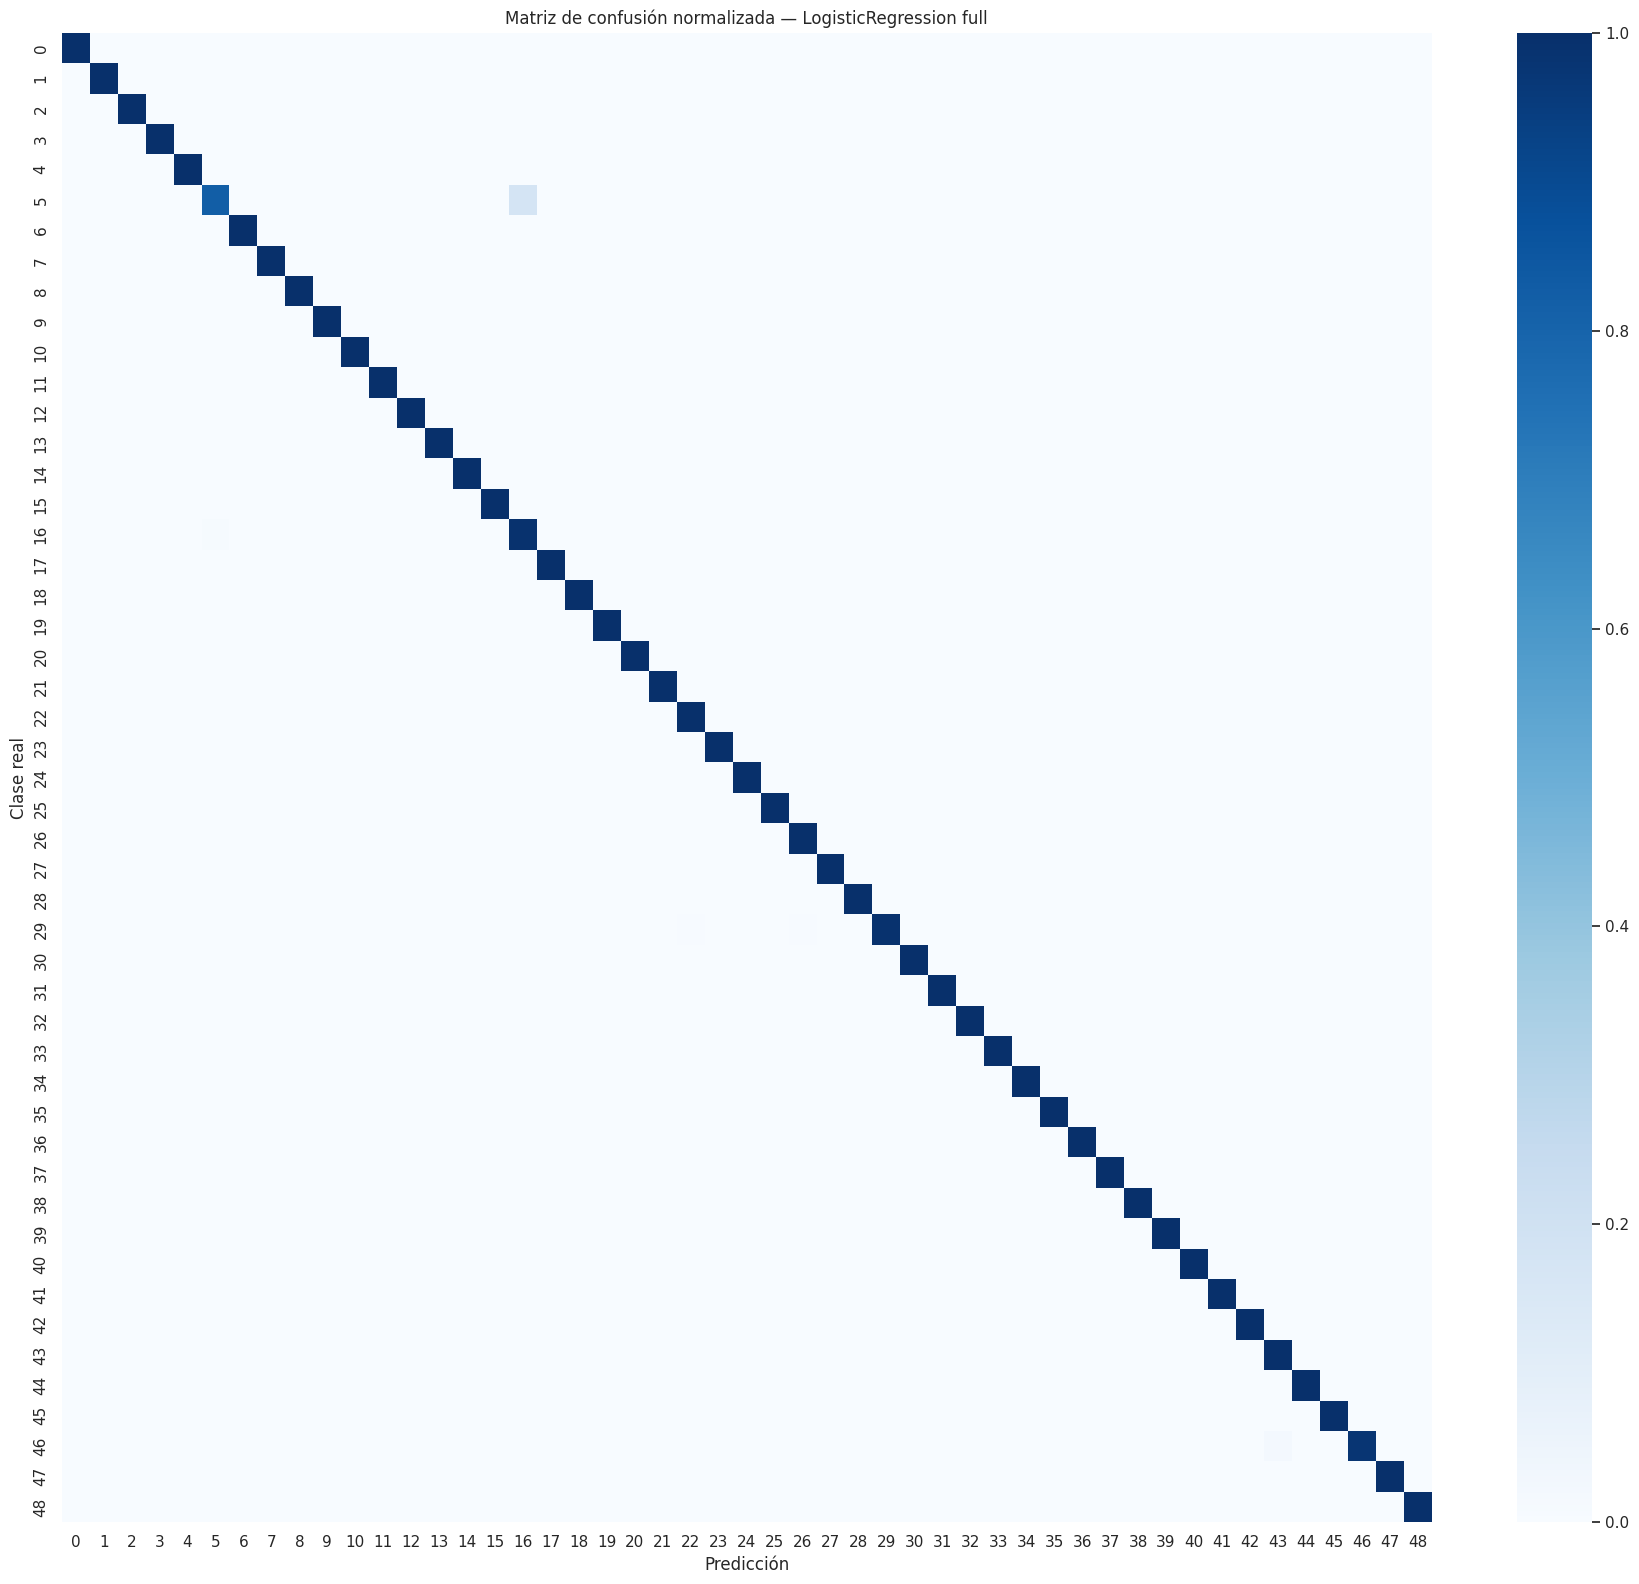

In [25]:
def top_predictions(probabilities: np.ndarray, row_index: int, k: int = 5) -> list[dict[str, Any]]:
    indices = np.argsort(probabilities[row_index])[-k:][::-1]
    return [{'pathology': preprocessing_metadata['class_names'][index], 'probability': float(probabilities[row_index, index])} for index in indices]

error_indices = np.flatnonzero(~is_top1)
error_confidence = best_logistic_probabilities[error_indices].max(axis=1)
selected_errors = list(error_indices[np.argsort(error_confidence)[:4]])
selected_errors += list(error_indices[np.argsort(error_confidence)[-4:]])
focus_classes = {'Acute rhinosinusitis', 'Unstable angina', 'Chronic rhinosinusitis'}
for class_name in focus_classes:
    class_index = preprocessing_metadata['class_to_index'].get(class_name)
    candidates = error_indices[y_val[error_indices] == class_index] if class_index is not None else []
    selected_errors.extend(list(candidates[:3]))
selected_errors = list(dict.fromkeys(selected_errors))[:20]

error_rows = []
for validation_index in selected_errors:
    true_index = int(y_val[validation_index])
    predicted_index = int(best_logistic_predictions[validation_index])
    error_rows.append({
        'validation_index': int(validation_index),
        'true_pathology': preprocessing_metadata['class_names'][true_index],
        'predicted_pathology': preprocessing_metadata['class_names'][predicted_index],
        'predicted_confidence': float(best_logistic_probabilities[validation_index, predicted_index]),
        'true_class_probability': float(best_logistic_probabilities[validation_index, true_index]),
        'true_class_rank': int(true_class_rank[validation_index]),
        'top_5_predictions': top_predictions(best_logistic_probabilities, validation_index),
        'age': int(val_frame['AGE'].iloc[validation_index]),
        'sex': str(val_frame['SEX'].iloc[validation_index]),
        'raw_evidences': val_frame['EVIDENCES'].iloc[validation_index],
    })
manual_error_review = pd.DataFrame(error_rows)
display(manual_error_review)

normalized_confusion = confusion_matrix(
    y_val, best_logistic_predictions, labels=CLASS_INDICES, normalize='true'
)
confusion_figure, confusion_axis = plt.subplots(figsize=(18, 16))
sns.heatmap(normalized_confusion, cmap='Blues', ax=confusion_axis, vmin=0, vmax=1)
confusion_axis.set(title='Matriz de confusión normalizada — LogisticRegression full', xlabel='Predicción', ylabel='Clase real')
confusion_figure.tight_layout()

off_diagonal = confusion_matrix(y_val, best_logistic_predictions, labels=CLASS_INDICES)
confusion_pairs = []
for true_index in CLASS_INDICES:
    row_total = off_diagonal[true_index].sum()
    for predicted_index in CLASS_INDICES:
        count = int(off_diagonal[true_index, predicted_index])
        if true_index != predicted_index and count:
            confusion_pairs.append({
                'true_pathology': preprocessing_metadata['class_names'][true_index],
                'predicted_pathology': preprocessing_metadata['class_names'][predicted_index],
                'count': count,
                'percentage_within_true_class': count / row_total * 100,
            })
confusion_pairs_table = pd.DataFrame(confusion_pairs).sort_values('count', ascending=False).head(15)
display(confusion_pairs_table)


In [26]:
balanced_fit_started = time.perf_counter()
balanced_convergence_messages = []
try:
    balanced_logistic_model = LogisticRegression(
        solver='lbfgs', max_iter=300, class_weight='balanced',
        random_state=PREPROCESS_SEED,
    )
    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter('always', ConvergenceWarning)
        balanced_logistic_model.fit(X_train_variants['full'], y_train)
    balanced_convergence_messages = [
        str(item.message) for item in captured if issubclass(item.category, ConvergenceWarning)
    ]
    balanced_predictions, balanced_probabilities, balanced_inference_seconds = measure_inference_time(
        balanced_logistic_model, X_val_variants['full']
    )
    balanced_metrics = compute_classification_metrics(y_val, balanced_predictions)
    balanced_metrics.update(compute_top_k_metrics(y_val, balanced_probabilities))
    balanced_metrics['fit_seconds'] = time.perf_counter() - balanced_fit_started
    balanced_metrics['inference_seconds'] = balanced_inference_seconds
    balanced_metrics['converged'] = not balanced_convergence_messages
    balanced_metrics['notes'] = '; '.join(balanced_convergence_messages)
except Exception as exc:
    balanced_logistic_model = None
    balanced_metrics = {'notes': f'No viable: {type(exc).__name__}: {exc}'}

comparison_metrics = pd.DataFrame([
    {'configuration': 'LogisticRegression', **compute_classification_metrics(y_val, best_logistic_predictions),
     **compute_top_k_metrics(y_val, best_logistic_probabilities)},
    {'configuration': 'LogisticRegression(balanced)', **balanced_metrics},
])
display(comparison_metrics)

recall_comparison_names = ['Bronchiolitis', 'Ebola', 'Croup', 'Acute rhinosinusitis']
recall_comparison_names += best_logistic_report.nsmallest(3, 'recall')['PATHOLOGY'].tolist()
recall_comparison_names = list(dict.fromkeys(recall_comparison_names))
if balanced_logistic_model is not None:
    balanced_report = build_classification_report_table(y_val, balanced_predictions)
    recall_comparison = best_logistic_report.query('PATHOLOGY in @recall_comparison_names')[['PATHOLOGY','recall']]
    recall_comparison = recall_comparison.merge(
        balanced_report[['PATHOLOGY','recall']], on='PATHOLOGY', suffixes=('_unweighted','_balanced')
    )
    display(recall_comparison)


,configuration,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy,fit_seconds,inference_seconds,converged,notes
0,LogisticRegression,0.996,0.996,0.995,0.996,0.996,1.000,1.000,NaN,NaN,NaN,NaN
1,LogisticRegression(balanced),0.996,0.992,0.995,0.993,0.996,1.000,1.000,14.004,0.060,True,


,PATHOLOGY,recall_unweighted,recall_balanced
0,Acute rhinosinusitis,0.822,0.836
1,Bronchiolitis,1.000,1.000
2,Chronic rhinosinusitis,0.990,0.983
3,Croup,1.000,1.000
4,Ebola,1.000,1.000
5,Unstable angina,0.978,0.978


### 19.1 Hallazgos de cordura


In [27]:
def sanity_findings() -> str:
    activated = int((feature_activity_table['status'] == 'activated_only_in_full_train').sum())
    still_inactive = int((feature_activity_table['status'] == 'still_inactive').sum())
    pairs = '; '.join(
        f"{row.true_pathology} → {row.predicted_pathology}"
        for row in confusion_pairs_table.head(3).itertuples()
    )
    normal_f1 = float(baseline_table.query("model == 'LogisticRegression' and feature_variant == 'full'").iloc[0]['f1_macro'])
    if 'f1_macro' in balanced_metrics:
        difference = float(balanced_metrics['f1_macro']) - normal_f1
        balanced_note = f"convergió={balanced_metrics.get('converged', False)}; F1 normal={normal_f1:.4f}; F1 balanceado={balanced_metrics['f1_macro']:.4f}; diferencia={difference:+.4f}"
    else:
        balanced_note = f"no evaluado o no viable; F1 normal={normal_f1:.4f}; detalle={balanced_metrics.get('notes', 'sin detalle')}"
    return f"""### Conclusiones antes de la MLP

- De las columnas inactivas en la muestra experimental, {activated} se activaron al revisar train completo y {still_inactive} siguieron inactivas. Por ello la máscara filtered actual no debe considerarse final.
- La logística produjo {top1_errors} errores Top-1, {top3_errors} errores Top-3 y {top5_errors} errores Top-5. La clase verdadera estuvo en Top-3 en {is_top3.mean():.4f} y en Top-5 en {is_top5.mean():.4f}.
- Pares de confusión principales: {pairs}.
- La revisión manual usa únicamente AGE, SEX y EVIDENCES; no se empleó DIFFERENTIAL_DIAGNOSIS.
- Resultado balanced: {balanced_note}.
- La MLP inicial debe partir de la variante full y comparar con filtered solo después de revisar la actividad completa y los costos. No hay en esta etapa una señal directa de fuga en la evaluación.
- Puede avanzarse al bloque 10 solo tras revisar visualmente los errores y la comparación balanced mostrada arriba.

Durante esta etapa todavía no se entrenó ninguna red neuronal ni se exportaron artefactos finales."""
display(Markdown(sanity_findings()))


### Conclusiones antes de la MLP

- De las columnas inactivas en la muestra experimental, 13 se activaron al revisar train completo y 457 siguieron inactivas. Por ello la máscara filtered actual no debe considerarse final.
- La logística produjo 71 errores Top-1, 0 errores Top-3 y 0 errores Top-5. La clase verdadera estuvo en Top-3 en 1.0000 y en Top-5 en 1.0000.
- Pares de confusión principales: Acute rhinosinusitis → Chronic rhinosinusitis; Unstable angina → Stable angina; Viral pharyngitis → Acute laryngitis.
- La revisión manual usa únicamente AGE, SEX y EVIDENCES; no se empleó DIFFERENTIAL_DIAGNOSIS.
- Resultado balanced: convergió=True; F1 normal=0.9957; F1 balanceado=0.9934; diferencia=-0.0023.
- La MLP inicial debe partir de la variante full y comparar con filtered solo después de revisar la actividad completa y los costos. No hay en esta etapa una señal directa de fuga en la evaluación.
- Puede avanzarse al bloque 10 solo tras revisar visualmente los errores y la comparación balanced mostrada arriba.

Durante esta etapa todavía no se entrenó ninguna red neuronal ni se exportaron artefactos finales.

## 20. Red neuronal inicial — fase experimental

La MLP inicial usa la variante full de las muestras FAST. Test no participa; los resultados se etiquetan como experimentales.


### 20.1 Configuración de TensorFlow y GPU

TensorFlow es la única fuente de verdad para GPU. El pipeline conserva CSR en memoria y densifica solo cada lote.


In [28]:
import math
import tensorflow as tf

TF_SEED = PREPROCESS_SEED
tf.keras.utils.set_random_seed(TF_SEED)
try:
    tf.config.experimental.enable_op_determinism()
    determinism_note = 'operaciones deterministas solicitadas'
except Exception as exc:
    determinism_note = f'determinismo no activado: {type(exc).__name__}'

gpus = tf.config.list_physical_devices('GPU')
gpu_details = [tf.config.experimental.get_device_details(gpu).get('device_name', gpu.name) for gpu in gpus]
print('TensorFlow:', tf.__version__)
print('GPU visibles:', gpu_details or 'ninguna')
print('Política de precisión:', tf.keras.mixed_precision.global_policy().name)
print(determinism_note)

MLP_BATCH_SIZE = 512
MLP_MAX_EPOCHS = 30
CHECKPOINT_PATH = '/kaggle/working/vitalyx_mlp_initial.keras'

def build_initial_mlp(input_features: int, classes: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(input_features,), name='clinical_features')
    x = tf.keras.layers.Dense(512, use_bias=False, kernel_initializer='he_normal')(inputs)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x); x = tf.keras.layers.Dropout(0.30)(x)
    x = tf.keras.layers.Dense(256, use_bias=False, kernel_initializer='he_normal')(x)
    x = tf.keras.layers.BatchNormalization()(x); x = tf.keras.layers.ReLU()(x); x = tf.keras.layers.Dropout(0.25)(x)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal')(x)
    x = tf.keras.layers.Dropout(0.20)(x)
    outputs = tf.keras.layers.Dense(classes, activation='softmax', name='pathology')(x)
    return tf.keras.Model(inputs, outputs, name='vitalyx_mlp_initial')

class LearningRateHistory(tf.keras.callbacks.Callback):
    def __init__(self): super().__init__(); self.values = []
    def on_epoch_end(self, epoch, logs=None): self.values.append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))

class CSRSequence(tf.keras.utils.Sequence):
    """Sequence reproducible que convierte CSR a denso únicamente por lote."""
    def __init__(self, matrix, targets, batch_size, shuffle, seed):
        super().__init__()
        self.matrix, self.targets = matrix, targets
        self.batch_size, self.shuffle, self.seed = batch_size, shuffle, seed
        self.epoch = 0
        self.indices = np.arange(len(targets))
        self.on_epoch_end()
    def __len__(self):
        return math.ceil(len(self.targets) / self.batch_size)
    def __getitem__(self, batch_index):
        selected = self.indices[batch_index * self.batch_size:(batch_index + 1) * self.batch_size]
        return self.matrix[selected].toarray().astype(np.float32, copy=False), self.targets[selected]
    def on_epoch_end(self):
        if self.shuffle:
            self.indices = np.random.default_rng(self.seed + self.epoch).permutation(len(self.targets))
        self.epoch += 1

train_sequence = CSRSequence(X_train_variants['full'], y_train, MLP_BATCH_SIZE, True, TF_SEED)
validation_sequence = CSRSequence(X_val_variants['full'], y_val, MLP_BATCH_SIZE, False, TF_SEED)
assert len(train_sequence) == math.ceil(len(y_train) / MLP_BATCH_SIZE)
assert len(validation_sequence) == math.ceil(len(y_val) / MLP_BATCH_SIZE)
first_order = train_sequence.indices.copy()
train_sequence.on_epoch_end()
assert not np.array_equal(first_order, train_sequence.indices)
print(f'Steps experimentales: train={len(train_sequence)}, validation={len(validation_sequence)}; shuffle reproducible y distinto por época.')


TensorFlow: 2.20.0
GPU visibles: ['Tesla P100-PCIE-16GB']
Política de precisión: float32
operaciones deterministas solicitadas
Steps experimentales: train=196, validation=40; shuffle reproducible y distinto por época.


### 20.2 Arquitectura, compilación y entrenamiento


In [29]:
lr_history = LearningRateHistory()
mlp_model = build_initial_mlp(975, 49)
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3,name='top3'),
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5,name='top5')])
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(CHECKPOINT_PATH,monitor='val_loss',save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=2,factor=0.5),
    tf.keras.callbacks.TerminateOnNaN(), lr_history,
]
mlp_started=time.perf_counter()
mlp_history=mlp_model.fit(train_sequence,validation_data=validation_sequence,
    steps_per_epoch=len(train_sequence),validation_steps=len(validation_sequence),
    epochs=MLP_MAX_EPOCHS,callbacks=callbacks,verbose=2)
mlp_fit_seconds=time.perf_counter()-mlp_started
best_epoch=int(np.argmin(mlp_history.history['val_loss']))+1
mlp_model=tf.keras.models.load_model(CHECKPOINT_PATH)
mlp_inference_started=time.perf_counter()
mlp_probabilities=mlp_model.predict(validation_sequence,steps=len(validation_sequence),verbose=0)
mlp_inference_seconds=time.perf_counter()-mlp_inference_started
mlp_predictions=mlp_probabilities.argmax(axis=1)
assert mlp_probabilities.shape==(len(y_val),49) and np.allclose(mlp_probabilities.sum(axis=1),1,atol=1e-6)
mlp_metrics=compute_classification_metrics(y_val,mlp_predictions)
mlp_metrics.update(compute_top_k_metrics(y_val,mlp_probabilities))
mlp_metrics.update({'model':'MLP initial corrected','feature_variant':'full','fit_seconds':mlp_fit_seconds,'inference_seconds':mlp_inference_seconds,'n_parameters':mlp_model.count_params(),'notes':'CSRSequence; pasos explícitos; checkpoint temporal'})


I0000 00:00:1783918192.899317      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/30
196/196 - 7s - 37ms/step - accuracy: 0.9376 - loss: 0.2846 - top3: 0.9657 - top5: 0.9716 - val_accuracy: 0.9953 - val_loss: 0.0333 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 2/30
196/196 - 2s - 9ms/step - accuracy: 0.9939 - loss: 0.0209 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9950 - val_loss: 0.0155 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 3/30
196/196 - 2s - 9ms/step - accuracy: 0.9947 - loss: 0.0164 - top3: 0.9999 - top5: 1.0000 - val_accuracy: 0.9962 - val_loss: 0.0118 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 4/30
196/196 - 2s - 9ms/step - accuracy: 0.9959 - loss: 0.0130 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9963 - val_loss: 0.0116 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 5/30
196/196 - 2s - 9ms/step - accuracy: 0.9962 - loss: 0.0117 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9962 - val_loss: 0.0106 - val_top3: 1.0000 - val_top5: 1.0000 - learni

### 20.3 Curvas, matriz de confusión, evaluación en validation y comparación con baselines


,true_class_rank,count,percentage
0,1,19924,99.620
1,2,76,0.380


,validation_index,true_pathology,predicted_pathology,predicted_probability,true_probability,true_rank,age,sex,top_5_predictions
0,15680,Chronic rhinosinusitis,Acute rhinosinusitis,0.515,0.484,2,3,F,"[{'pathology': 'Acute rhinosinusitis', 'probability': 0.5153561234474182}, {'pathology': 'Chronic rhinosinusitis', 'probability': 0.48423343896865845}, {'pa..."
1,15101,Viral pharyngitis,Acute laryngitis,0.518,0.480,2,81,M,"[{'pathology': 'Acute laryngitis', 'probability': 0.5178921818733215}, {'pathology': 'Viral pharyngitis', 'probability': 0.4799193739891052}, {'pathology': ..."
2,7877,Chronic rhinosinusitis,Acute rhinosinusitis,0.528,0.472,2,21,F,"[{'pathology': 'Acute rhinosinusitis', 'probability': 0.5281794667243958}, {'pathology': 'Chronic rhinosinusitis', 'probability': 0.47150102257728577}, {'pa..."
3,13273,Unstable angina,Stable angina,0.985,0.015,2,38,F,"[{'pathology': 'Stable angina', 'probability': 0.9851323962211609}, {'pathology': 'Unstable angina', 'probability': 0.014759775251150131}, {'pathology': 'Bo..."
4,3308,Unstable angina,Stable angina,0.993,0.007,2,62,M,"[{'pathology': 'Stable angina', 'probability': 0.993191659450531}, {'pathology': 'Unstable angina', 'probability': 0.006761606782674789}, {'pathology': 'Myo..."
5,5199,Unstable angina,Stable angina,0.995,0.005,2,48,F,"[{'pathology': 'Stable angina', 'probability': 0.9953859448432922}, {'pathology': 'Unstable angina', 'probability': 0.0045148651115596294}, {'pathology': 'M..."
6,587,Acute rhinosinusitis,Chronic rhinosinusitis,0.625,0.375,2,58,F,"[{'pathology': 'Chronic rhinosinusitis', 'probability': 0.6246137619018555}, {'pathology': 'Acute rhinosinusitis', 'probability': 0.3750920295715332}, {'pat..."
7,610,Acute rhinosinusitis,Chronic rhinosinusitis,0.785,0.214,2,8,F,"[{'pathology': 'Chronic rhinosinusitis', 'probability': 0.785075306892395}, {'pathology': 'Acute rhinosinusitis', 'probability': 0.21379698812961578}, {'pat..."
8,487,Chronic rhinosinusitis,Acute rhinosinusitis,0.795,0.204,2,35,F,"[{'pathology': 'Acute rhinosinusitis', 'probability': 0.795202910900116}, {'pathology': 'Chronic rhinosinusitis', 'probability': 0.20389434695243835}, {'pat..."
9,1143,Chronic rhinosinusitis,Acute rhinosinusitis,0.762,0.238,2,17,F,"[{'pathology': 'Acute rhinosinusitis', 'probability': 0.7615206837654114}, {'pathology': 'Chronic rhinosinusitis', 'probability': 0.2378157377243042}, {'pat..."


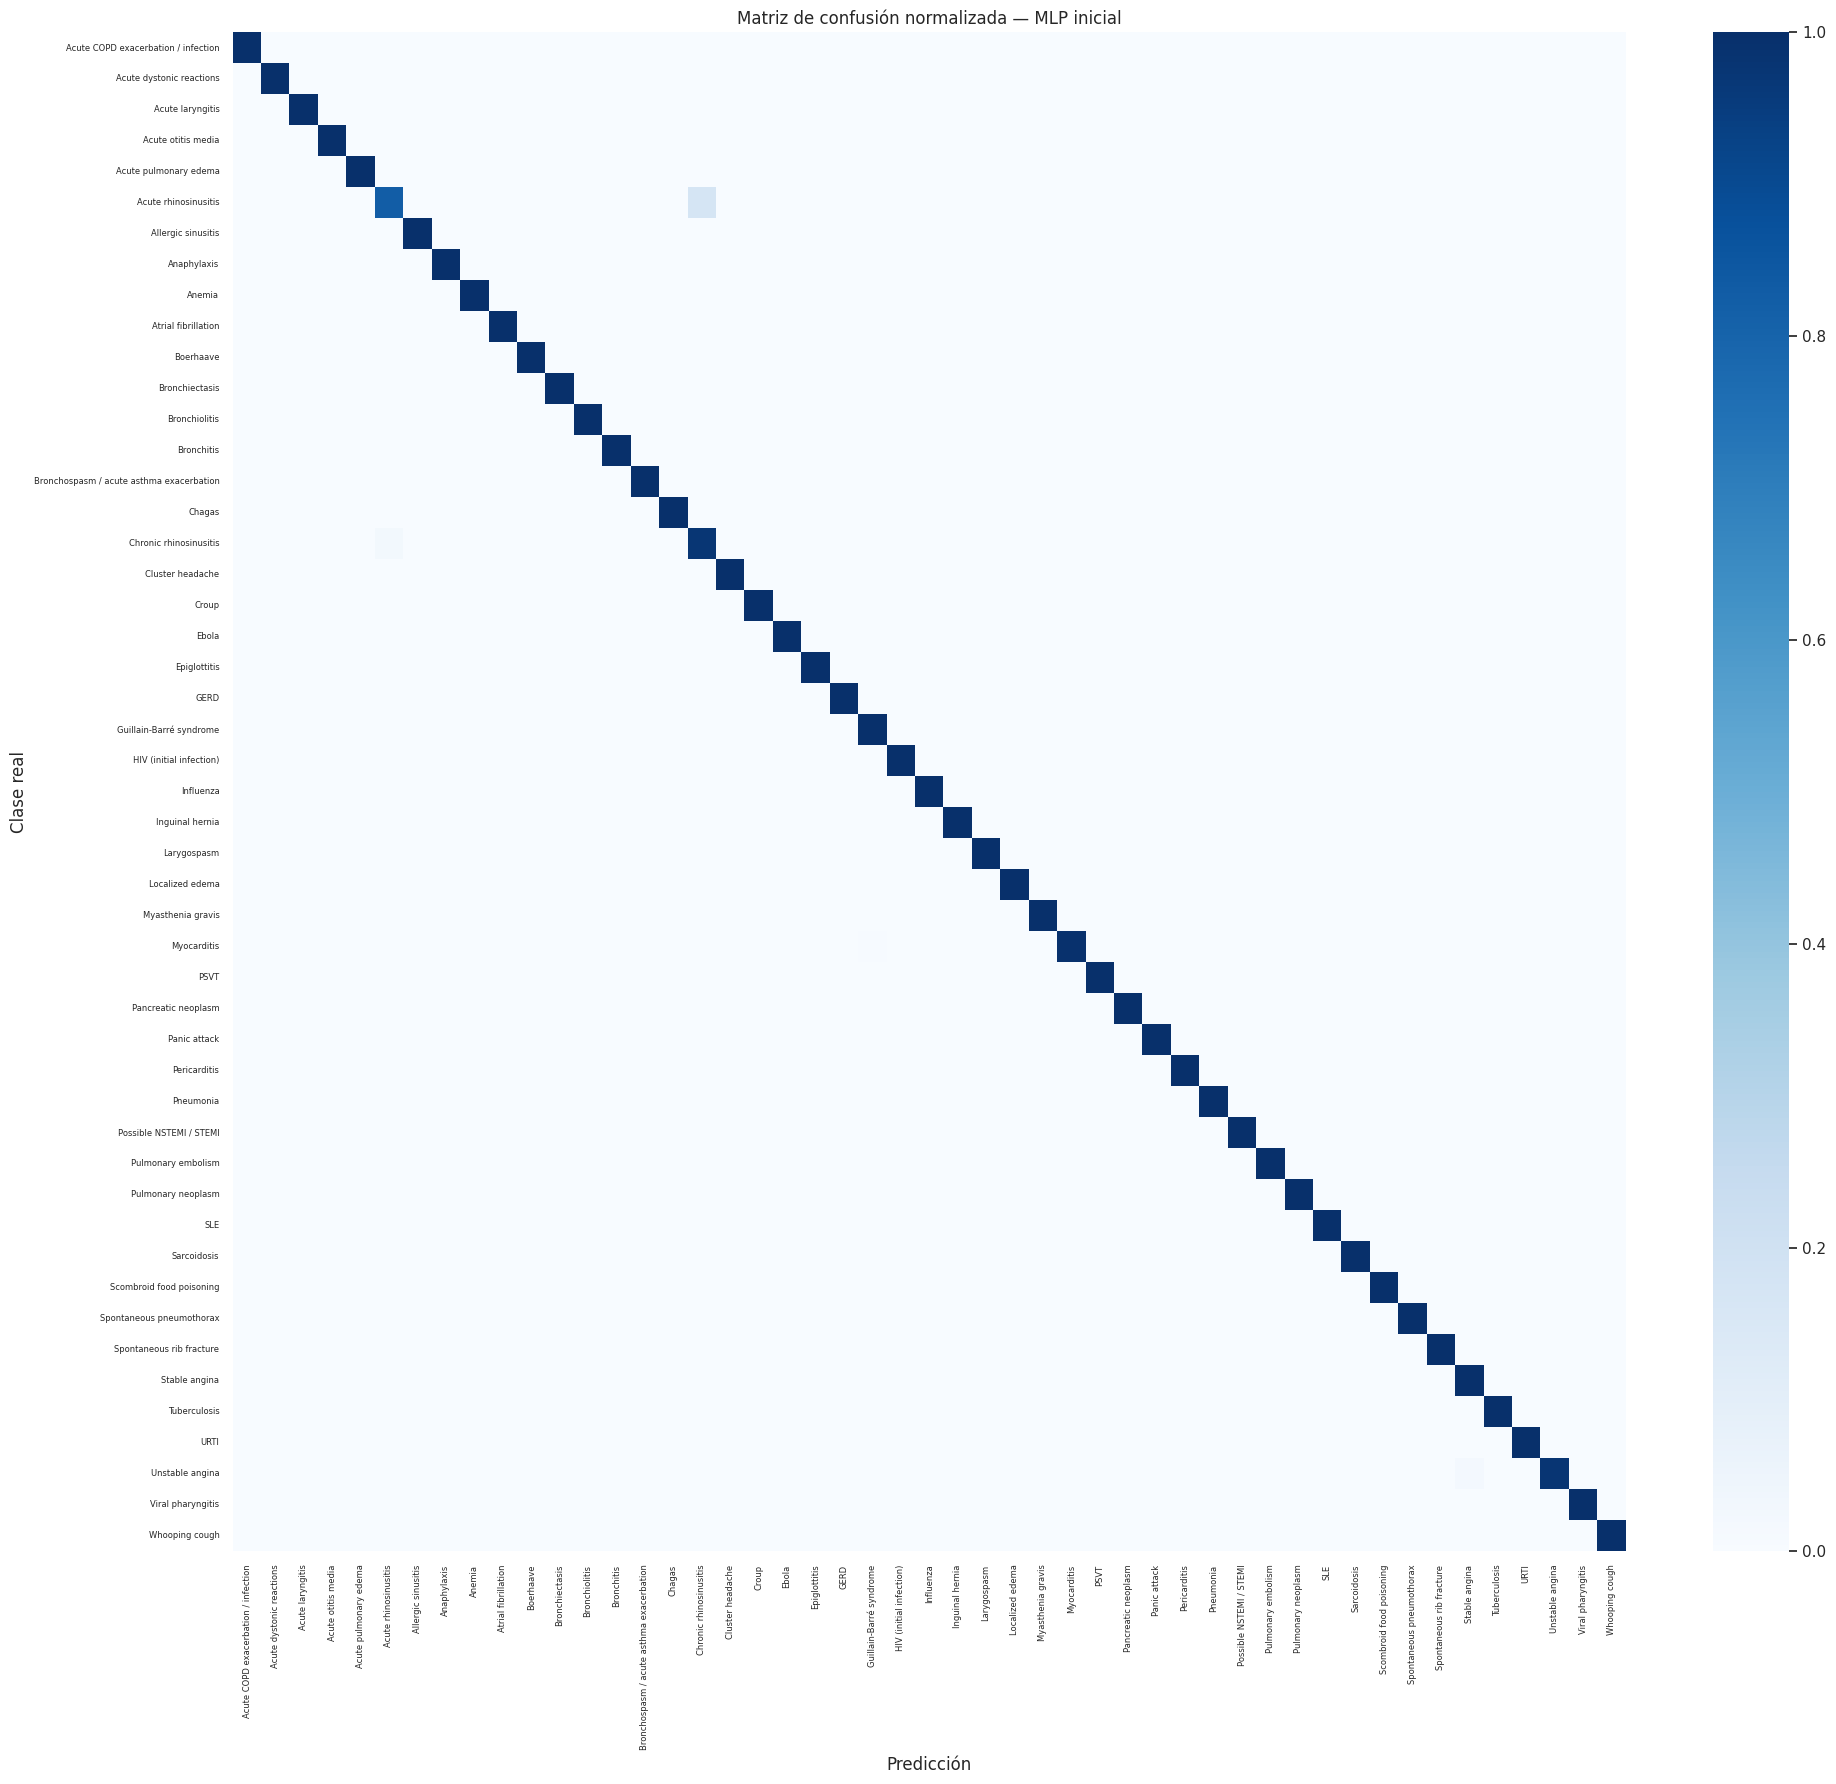

In [30]:
def plot_normalized_confusion_matrix(y_true, y_pred, class_names, title):
    matrix = confusion_matrix(y_true, y_pred, labels=CLASS_INDICES, normalize='true')
    figure, axis = plt.subplots(figsize=(20, 18))
    sns.heatmap(matrix, xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axis)
    axis.set(title=title, xlabel='Predicción', ylabel='Clase real')
    axis.tick_params(axis='x', rotation=90, labelsize=6)
    axis.tick_params(axis='y', rotation=0, labelsize=6)
    figure.tight_layout()
    return figure, axis

logistic_candidates = baseline_table.query("model == 'LogisticRegression' and feature_variant == 'full'")
if len(logistic_candidates) != 1:
    raise ValueError(f'Se esperaba exactamente una fila LogisticRegression/full; se encontraron {len(logistic_candidates)}.')
logistic_row = logistic_candidates.iloc[0]
F1_EQUIVALENCE_TOLERANCE=1e-4
logistic_f1=float(logistic_row['f1_macro']); delta_f1=mlp_metrics['f1_macro']-logistic_f1
relation='obtuvo un rendimiento equivalente a' if abs(delta_f1)<=F1_EQUIVALENCE_TOLERANCE else 'superó' if delta_f1>0 else 'quedó por debajo de'

mlp_ranking=np.argsort(-mlp_probabilities,axis=1)
mlp_true_rank=np.argmax(mlp_ranking==y_val[:,None],axis=1)+1
mlp_is_top1=mlp_true_rank==1; mlp_is_top3=mlp_true_rank<=3; mlp_is_top5=mlp_true_rank<=5
mlp_topk_table=pd.DataFrame({'true_class_rank':mlp_true_rank}).value_counts().rename('count').reset_index()
mlp_topk_table['percentage']=mlp_topk_table['count']/len(y_val)*100
mlp_top1_errors=int((~mlp_is_top1).sum()); mlp_top3_errors=int((~mlp_is_top3).sum()); mlp_top5_errors=int((~mlp_is_top5).sum())
if mlp_top3_errors==0: assert mlp_is_top3.mean()==1.0
if mlp_top5_errors==0: assert mlp_is_top5.mean()==1.0
display(mlp_topk_table.sort_values('true_class_rank'))

mlp_report=build_classification_report_table(y_val,mlp_predictions)
error_indices=np.flatnonzero(~mlp_is_top1)
confidence=mlp_probabilities[error_indices].max(axis=1)
chosen=list(error_indices[np.argsort(confidence)[:3]])+list(error_indices[np.argsort(confidence)[-3:]])
for name in ('Acute rhinosinusitis','Chronic rhinosinusitis','Unstable angina'):
    index=preprocessing_metadata['class_to_index'].get(name)
    if index is not None: chosen.extend(error_indices[y_val[error_indices]==index][:2])
chosen=list(dict.fromkeys(chosen))[:10]
mlp_error_table=pd.DataFrame([{'validation_index':int(i),'true_pathology':preprocessing_metadata['class_names'][y_val[i]],
 'predicted_pathology':preprocessing_metadata['class_names'][mlp_predictions[i]],
 'predicted_probability':float(mlp_probabilities[i,mlp_predictions[i]]),'true_probability':float(mlp_probabilities[i,y_val[i]]),
 'true_rank':int(mlp_true_rank[i]),'age':int(val_frame['AGE'].iloc[i]),'sex':str(val_frame['SEX'].iloc[i]),
 'top_5_predictions':top_predictions(mlp_probabilities,i)} for i in chosen])
display(mlp_error_table)

mlp_confusion_figure, mlp_confusion_axis = plot_normalized_confusion_matrix(y_val, mlp_predictions, preprocessing_metadata['class_names'], 'Matriz de confusión normalizada — MLP inicial')
plt.show()


### 20.4 Conclusiones


In [31]:
post_best_train=min(mlp_history.history['loss'][best_epoch-1:]); post_best_val=mlp_history.history['val_loss'][best_epoch-1:]
overfit='sin evidencia clara de sobreajuste'
if len(post_best_val)>1 and post_best_val[-1]>min(post_best_val) and mlp_history.history['loss'][-1]<post_best_train:
    overfit='sobreajuste leve controlado mediante EarlyStopping'

def corrected_mlp_summary() -> str:
    return f"""### 20.4 Conclusiones

- Advertencia de cardinalidad eliminada mediante CSRSequence y pasos explícitos.
- Shuffle: reproducible entre ejecuciones y distinto por época; validation no se mezcla.
- Épocas ejecutadas: {len(mlp_history.history['loss'])}; mejor época: {best_epoch}.
- F1 MLP={mlp_metrics['f1_macro']:.6f}; F1 LogisticRegression={logistic_f1:.6f}; delta={delta_f1:+.6f}; tolerancia={F1_EQUIVALENCE_TOLERANCE:.6f}.
- La MLP {relation} LogisticRegression.
- Diagnóstico: {overfit}.
- Errores Top-1={mlp_top1_errors}; Top-3={mlp_top3_errors}; Top-5={mlp_top5_errors}; peor rango={mlp_true_rank.max()}.
- La inferencia MLP incluye conversión CSR a denso por lote y sobrecarga de Sequence; no es equivalente directamente a la inferencia CSR de la logística.
- La arquitectura puede conservarse como baseline neuronal. El bloque 11 puede explorar regularización y learning rate, sin usar test.

No se usó test ni se realizó optimización."""
display(Markdown(corrected_mlp_summary()))


### 20.4 Conclusiones

- Advertencia de cardinalidad eliminada mediante CSRSequence y pasos explícitos.
- Shuffle: reproducible entre ejecuciones y distinto por época; validation no se mezcla.
- Épocas ejecutadas: 10; mejor época: 5.
- F1 MLP=0.995499; F1 LogisticRegression=0.995711; delta=-0.000211; tolerancia=0.000100.
- La MLP quedó por debajo de LogisticRegression.
- Diagnóstico: sin evidencia clara de sobreajuste.
- Errores Top-1=76; Top-3=0; Top-5=0; peor rango=2.
- La inferencia MLP incluye conversión CSR a denso por lote y sobrecarga de Sequence; no es equivalente directamente a la inferencia CSR de la logística.
- La arquitectura puede conservarse como baseline neuronal. El bloque 11 puede explorar regularización y learning rate, sin usar test.

No se usó test ni se realizó optimización.

## 21. Optimización controlada de la MLP — fase experimental

Los ocho experimentos E01–E08 se ejecutan sobre las mismas muestras FAST y validation experimental. E01 debe ser técnicamente equivalente al mejor resultado para continuar a la fase oficial.


In [32]:
MLP_EXPERIMENTS = [
 {'experiment_id':'E01','hidden_layers':[512,256,128],'use_bias':[False,False,True],'dropout':[0.30,0.25,0.20],'learning_rate':1e-3,'batch_size':512},
 {'experiment_id':'E02','hidden_layers':[256,128],'dropout':0.15,'learning_rate':1e-3,'batch_size':512},
 {'experiment_id':'E03','hidden_layers':[256,128],'dropout':0.25,'learning_rate':1e-3,'batch_size':256},
 {'experiment_id':'E04','hidden_layers':[256,128],'dropout':0.35,'learning_rate':5e-4,'batch_size':512},
 {'experiment_id':'E05','hidden_layers':[512,256,128],'dropout':0.25,'learning_rate':5e-4,'batch_size':512},
 {'experiment_id':'E06','hidden_layers':[256,128,64],'dropout':0.15,'learning_rate':1e-3,'batch_size':256},
 {'experiment_id':'E07','hidden_layers':[256,128,64],'dropout':0.25,'learning_rate':5e-4,'batch_size':512},
 {'experiment_id':'E08','hidden_layers':[512,256,128],'dropout':0.35,'learning_rate':5e-4,'batch_size':256},
]
assert 8 <= len(MLP_EXPERIMENTS) <= 12

def build_mlp_from_config(config, input_features=975, classes=49):
    inputs=tf.keras.Input(shape=(input_features,))
    layer_count = len(config['hidden_layers'])
    dropouts = config['dropout'] if isinstance(config['dropout'], list) else [config['dropout']] * layer_count
    biases = config.get('use_bias', True) if isinstance(config.get('use_bias', True), list) else [config.get('use_bias', True)] * layer_count
    x=inputs
    for position, units in enumerate(config['hidden_layers']):
        use_bias=biases[position]
        x=tf.keras.layers.Dense(units,use_bias=use_bias,kernel_initializer='he_normal')(x)
        if position < 2: x=tf.keras.layers.BatchNormalization()(x)
        x=tf.keras.layers.ReLU()(x)
        x=tf.keras.layers.Dropout(dropouts[position])(x)
    outputs=tf.keras.layers.Dense(classes,activation='softmax')(x)
    return tf.keras.Model(inputs,outputs,name=f"mlp_{config['experiment_id']}")


In [33]:
def run_mlp_experiment(config):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(TF_SEED)
    train_seq=CSRSequence(X_train_variants['full'],y_train,config['batch_size'],True,TF_SEED)
    val_seq=CSRSequence(X_val_variants['full'],y_val,config['batch_size'],False,TF_SEED)
    path=f"/kaggle/working/vitalyx_{config['experiment_id']}.keras"
    model=build_mlp_from_config(config)
    model.compile(optimizer=tf.keras.optimizers.Adam(config['learning_rate']),
      loss=tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
               tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3,name='top3'),
               tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5,name='top5')])
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True),
      tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',patience=2,factor=.5),
      tf.keras.callbacks.ModelCheckpoint(path,monitor='val_loss',save_best_only=True),
      tf.keras.callbacks.TerminateOnNaN()]
    started=time.perf_counter()
    history=model.fit(train_seq,validation_data=val_seq,steps_per_epoch=len(train_seq),
      validation_steps=len(val_seq),epochs=25,callbacks=callbacks,verbose=0)
    fit_seconds=time.perf_counter()-started
    model=tf.keras.models.load_model(path)
    started=time.perf_counter(); probabilities=model.predict(val_seq,steps=len(val_seq),verbose=0); inference_seconds=time.perf_counter()-started
    if probabilities.shape != (len(y_val), 49):
        raise ValueError(f'Forma de probabilidades inválida: {probabilities.shape}')
    if not np.isfinite(probabilities).all() or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError('Probabilidades no finitas o no normalizadas.')
    predictions=probabilities.argmax(axis=1)
    metrics=compute_classification_metrics(y_val,predictions); metrics.update(compute_top_k_metrics(y_val,probabilities))
    result={**config,'epochs_run':len(history.history['loss']),'best_epoch':int(np.argmin(history.history['val_loss']))+1,
      'val_loss':min(history.history['val_loss']),'fit_seconds':fit_seconds,'inference_seconds':inference_seconds,
      'n_parameters':model.count_params(),**metrics}
    return result,history

experiment_results=[]; experiment_histories={}
for config in MLP_EXPERIMENTS:
    result,history=run_mlp_experiment(config)
    experiment_results.append(result); experiment_histories[config['experiment_id']]=history
    print(config['experiment_id'],result['f1_macro'])
mlp_experiment_table=pd.DataFrame(experiment_results).sort_values(['f1_macro','val_loss','fit_seconds'],ascending=[False,True,True]).reset_index(drop=True)
display(mlp_experiment_table)


E01 0.9958997860017713
E02 0.9957216988893977
E03 0.9958677076788356
E04 0.9953857390002616
E05 0.9958670502552707
E06 0.9957728637031656
E07 0.9957117757989242
E08 0.9959487195455196


,experiment_id,hidden_layers,use_bias,dropout,learning_rate,batch_size,epochs_run,best_epoch,val_loss,fit_seconds,inference_seconds,n_parameters,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy
0,E08,"[512, 256, 128]",NaN,0.350,0.001,256,15,11,0.010,49.352,0.403,673329,0.997,0.997,0.995,0.996,0.997,1.000,1.000
1,E01,"[512, 256, 128]","[False, False, True]","[0.3, 0.25, 0.2]",0.001,512,11,7,0.011,20.142,0.293,672561,0.997,0.997,0.995,0.996,0.996,1.000,1.000
2,E03,"[256, 128]",NaN,0.250,0.001,256,9,5,0.011,28.474,0.389,290609,0.997,0.997,0.995,0.996,0.997,1.000,1.000
3,E05,"[512, 256, 128]",NaN,0.250,0.001,512,14,10,0.011,25.872,0.299,673329,0.997,0.997,0.995,0.996,0.997,1.000,1.000
4,E06,"[256, 128, 64]",NaN,0.150,0.001,256,15,11,0.011,49.586,0.394,295729,0.996,0.997,0.995,0.996,0.996,1.000,1.000
5,E02,"[256, 128]",NaN,0.150,0.001,512,9,5,0.011,16.573,0.293,290609,0.996,0.997,0.995,0.996,0.996,1.000,1.000
6,E07,"[256, 128, 64]",NaN,0.250,0.001,512,14,10,0.011,25.770,0.301,295729,0.996,0.997,0.995,0.996,0.996,1.000,1.000
7,E04,"[256, 128]",NaN,0.350,0.001,512,21,17,0.011,35.664,0.303,290609,0.996,0.996,0.995,0.995,0.996,1.000,1.000


,comparison,delta_f1
0,vs MLP inicial,0.000
1,vs LogisticRegression,0.000


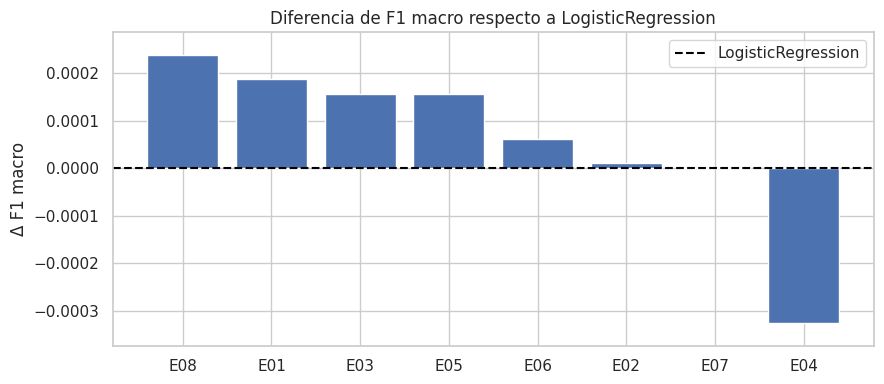

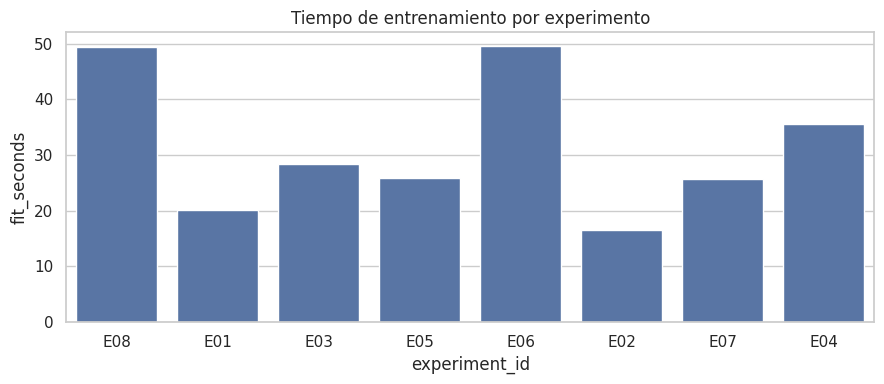

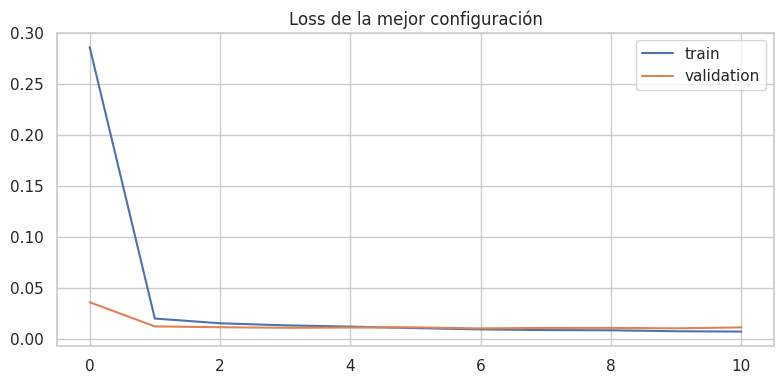

In [34]:
top_f1=mlp_experiment_table.iloc[0]['f1_macro']
technical_ties=mlp_experiment_table[abs(mlp_experiment_table['f1_macro']-top_f1)<=F1_EQUIVALENCE_TOLERANCE]
e01_candidates = mlp_experiment_table.query("experiment_id == 'E01'")
if len(e01_candidates) != 1:
    raise RuntimeError('La tabla experimental debe contener exactamente E01.')
e01_result = e01_candidates.iloc[0].to_dict()
if abs(e01_result['f1_macro'] - top_f1) > F1_EQUIVALENCE_TOLERANCE:
    raise RuntimeError('E01 dejó de ser técnicamente equivalente al mejor experimento; revisar resultados antes de entrenar oficialmente.')
best_mlp_result = e01_result
best_mlp_config = next(config for config in MLP_EXPERIMENTS if config['experiment_id'] == 'E01')
best_mlp_history=experiment_histories[best_mlp_config['experiment_id']]
initial_f1=float(mlp_metrics['f1_macro']); logistic_f1=float(logistic_row['f1_macro'])
display(pd.DataFrame([{'comparison':'vs MLP inicial','delta_f1':best_mlp_result['f1_macro']-initial_f1},
 {'comparison':'vs LogisticRegression','delta_f1':best_mlp_result['f1_macro']-logistic_f1}]))
f1_deltas = mlp_experiment_table['f1_macro'] - logistic_f1
delta_margin = max(float(f1_deltas.abs().max()) * 0.15, 1e-5)
plt.figure(figsize=(9,4)); plt.bar(mlp_experiment_table['experiment_id'], f1_deltas); plt.axhline(0, color='black', linestyle='--', label='LogisticRegression'); plt.ylim(float(f1_deltas.min()) - delta_margin, float(f1_deltas.max()) + delta_margin); plt.title('Diferencia de F1 macro respecto a LogisticRegression'); plt.ylabel('Δ F1 macro'); plt.legend(); plt.tight_layout(); plt.show()
plt.figure(figsize=(9,4)); sns.barplot(data=mlp_experiment_table,x='experiment_id',y='fit_seconds'); plt.title('Tiempo de entrenamiento por experimento'); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.plot(best_mlp_history.history['loss'],label='train'); plt.plot(best_mlp_history.history['val_loss'],label='validation'); plt.title('Loss de la mejor configuración'); plt.legend(); plt.tight_layout(); plt.show()


### Conclusiones de optimización controlada

In [35]:
def mlp_optimization_summary():
    delta_initial=best_mlp_result['f1_macro']-initial_f1
    delta_logistic=best_mlp_result['f1_macro']-logistic_f1
    initial_conclusion='empate técnico' if abs(delta_initial)<=F1_EQUIVALENCE_TOLERANCE else 'mejora real' if delta_initial>0 else 'empeoramiento'
    logistic_conclusion='empate técnico' if abs(delta_logistic)<=F1_EQUIVALENCE_TOLERANCE else 'mejora real' if delta_logistic>0 else 'empeoramiento'
    return f"""- Configuraciones probadas: {len(MLP_EXPERIMENTS)}.
- Mejor: {best_mlp_config}.
- F1 macro: {best_mlp_result['f1_macro']:.6f}; frente a MLP inicial: {delta_initial:+.6f}; frente a logística: {delta_logistic:+.6f}.
- Frente a MLP inicial: {initial_conclusion} con tolerancia {F1_EQUIVALENCE_TOLERANCE}.
- Frente a LogisticRegression: {logistic_conclusion} con tolerancia {F1_EQUIVALENCE_TOLERANCE}.
- Recomendación: usar {best_mlp_config} como configuración candidata para el entrenamiento completo."""
display(Markdown(mlp_optimization_summary()))


- Configuraciones probadas: 8.
- Mejor: {'experiment_id': 'E01', 'hidden_layers': [512, 256, 128], 'use_bias': [False, False, True], 'dropout': [0.3, 0.25, 0.2], 'learning_rate': 0.001, 'batch_size': 512}.
- F1 macro: 0.995900; frente a MLP inicial: +0.000400; frente a logística: +0.000189.
- Frente a MLP inicial: mejora real con tolerancia 0.0001.
- Frente a LogisticRegression: mejora real con tolerancia 0.0001.
- Recomendación: usar {'experiment_id': 'E01', 'hidden_layers': [512, 256, 128], 'use_bias': [False, False, True], 'dropout': [0.3, 0.25, 0.2], 'learning_rate': 0.001, 'batch_size': 512} como configuración candidata para el entrenamiento completo.

## Transición de recursos — de experimentos a fase oficial

Las tablas, historiales y decisiones experimentales se conservan en estructuras ligeras. Las matrices FAST, modelos temporales y secuencias se liberan antes de construir las matrices oficiales completas.


In [36]:
experimental_evidence = {
    'preprocessing_reports': preprocessing_reports.copy(),
    'feature_selection_summary': {
        'before': int(feature_selection['feature_count_before']),
        'after': int(feature_selection['feature_count_after']),
        'removed_by_reason': feature_selection['removed'].groupby('reason').size().to_dict(),
    },
    'baseline_table': baseline_table.copy(),
    'balanced_comparison': comparison_metrics.copy(),
    'feature_activity_summary': feature_activity_table.groupby(['status', 'feature_type']).size().rename('features').reset_index(),
    'mlp_initial_metrics': dict(mlp_metrics),
    'mlp_experiment_table': mlp_experiment_table.copy(),
    'selected_experimental_config': dict(best_mlp_config),
}

for temporary_name in (
    'X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test',
    'X_train_variants', 'X_val_variants', 'feature_variants',
    'train_sequence', 'validation_sequence', 'mlp_model', 'best_logistic_model',
    'balanced_logistic_model', 'mlp_probabilities', 'best_logistic_probabilities',
    'balanced_probabilities', 'train_frame', 'val_frame', 'test_frame',
    'X_first', 'X_second', 'y_first', 'y_second', 'experiment_histories',
    'mlp_history', 'best_mlp_history', 'history', 'lr_history', 'callbacks', 'tree_probe',
):
    globals().pop(temporary_name, None)
tf.keras.backend.clear_session()
release_memory()
print('Recursos experimentales liberados; se conservan tablas e historial ligero en experimental_evidence.')


Recursos experimentales liberados; se conservan tablas e historial ligero en experimental_evidence.


## 22. Entrenamiento y evaluación final oficial

Tras liberar los recursos experimentales, E01 se reconstruye sobre train completo sin duplicados y validation oficial. Test se evalúa automáticamente una sola vez después de congelar el checkpoint mediante validation.


In [37]:
required_names = [
    'train_unique', 'splits', 'EVIDENCE_METADATA', 'conditions_metadata',
    'build_feature_schema', 'fit_preprocessing_metadata', 'transform_split',
    'build_mlp_from_config', 'CSRSequence', 'compute_classification_metrics',
    'compute_top_k_metrics', 'build_classification_report_table',
]
missing_dependencies = [name for name in required_names if name not in globals()]
if missing_dependencies:
    raise RuntimeError('Faltan dependencias para el entrenamiento final: ' + ', '.join(missing_dependencies))
print('Dependencias de entrenamiento final verificadas.')

Dependencias de entrenamiento final verificadas.


### 22.1 Preparación completa y entrenamiento E01

In [38]:
def plot_normalized_confusion_matrix(y_true, y_pred, class_names, title):
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)), normalize='true')
    figure, axis = plt.subplots(figsize=(20, 18))
    sns.heatmap(matrix, xticklabels=class_names, yticklabels=class_names, cmap='Blues', ax=axis)
    axis.set(title=title, xlabel='Predicción', ylabel='Clase real')
    axis.tick_params(axis='x', rotation=90, labelsize=6)
    axis.tick_params(axis='y', rotation=0, labelsize=6)
    figure.tight_layout()
    return figure, axis

FINAL_CONFIG = {
    'experiment_id': 'E01_final',
    'hidden_layers': [512, 256, 128],
    'use_bias': [False, False, True],
    'dropout': [0.30, 0.25, 0.20],
    'learning_rate': 1e-3,
    'batch_size': 512,
}
FINAL_CHECKPOINT_PATH = Path('/kaggle/working/vitalyx_final_best.keras')
FINAL_MANIFEST_PATH = Path('/kaggle/working/vitalyx_final_manifest_pre_test.json')
FINAL_TEST_RESULT_PATH = Path('/kaggle/working/vitalyx_final_test_result.json')
FINAL_TEST_EVALUATION_DONE = False
if best_mlp_config['experiment_id'] != 'E01':
    raise RuntimeError('La fase experimental no confirmó E01; no se puede iniciar entrenamiento final.')
print('E01 confirmado por la fase experimental; se inicia la fase oficial completa.')

final_schema = build_feature_schema(EVIDENCE_METADATA)
final_preprocessing_metadata = fit_preprocessing_metadata(train_unique, final_schema, conditions_metadata)
X_train_final, y_train_final, train_final_report = transform_split('train_final', train_unique, final_preprocessing_metadata)
X_val_final, y_val_final, val_final_report = transform_split('validation_final', splits['validation'], final_preprocessing_metadata)
assert X_train_final.shape[1] == X_val_final.shape[1] == 975
assert len(final_preprocessing_metadata['class_names']) == 49
assert len(train_unique) == len(splits['train']) - 10_162
assert len(splits['validation']) == 132_448
assert all(not np.isnan(matrix.data).any() and not np.isinf(matrix.data).any() for matrix in (X_train_final, X_val_final))
final_transform_table = pd.DataFrame([train_final_report.as_dict(), val_final_report.as_dict()])
display(final_transform_table)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(TF_SEED)
final_train_sequence = CSRSequence(X_train_final, y_train_final, FINAL_CONFIG['batch_size'], True, TF_SEED)
final_validation_sequence = CSRSequence(X_val_final, y_val_final, FINAL_CONFIG['batch_size'], False, TF_SEED)
final_model = build_mlp_from_config(FINAL_CONFIG)
final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINAL_CONFIG['learning_rate']),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name='top3'),
             tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5')],
)
final_parameter_count = final_model.count_params()
assert final_parameter_count == 672_561
final_lr_history = LearningRateHistory()
final_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5),
    tf.keras.callbacks.ModelCheckpoint(FINAL_CHECKPOINT_PATH, monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.TerminateOnNaN(),
    final_lr_history,
]
print('Entrenamiento final: train completo, validation oficial; test no participa.')


E01 confirmado por la fase experimental; se inicia la fase oficial completa.
train_final: 20,000/1,015,440 filas transformadas
train_final: 40,000/1,015,440 filas transformadas
train_final: 60,000/1,015,440 filas transformadas
train_final: 80,000/1,015,440 filas transformadas
train_final: 100,000/1,015,440 filas transformadas
train_final: 120,000/1,015,440 filas transformadas
train_final: 140,000/1,015,440 filas transformadas
train_final: 160,000/1,015,440 filas transformadas
train_final: 180,000/1,015,440 filas transformadas
train_final: 200,000/1,015,440 filas transformadas
train_final: 220,000/1,015,440 filas transformadas
train_final: 240,000/1,015,440 filas transformadas
train_final: 260,000/1,015,440 filas transformadas
train_final: 280,000/1,015,440 filas transformadas
train_final: 300,000/1,015,440 filas transformadas
train_final: 320,000/1,015,440 filas transformadas
train_final: 340,000/1,015,440 filas transformadas
train_final: 360,000/1,015,440 filas transformadas
train_fin

,partition,seconds,rows,columns,nnz,density,memory_mb,unknown_tokens,unknown_details
0,train_final,426.809,1015440,975,30077198,0.030,233.344,0,{}
1,validation_final,56.211,132448,975,3942377,0.031,30.583,0,{}


Entrenamiento final: train completo, validation oficial; test no participa.


In [39]:
final_fit_started = time.perf_counter()
final_history = final_model.fit(
    final_train_sequence,
    validation_data=final_validation_sequence,
    steps_per_epoch=len(final_train_sequence),
    validation_steps=len(final_validation_sequence),
    epochs=30,
    callbacks=final_callbacks,
    verbose=2,
)
final_fit_seconds = time.perf_counter() - final_fit_started
final_best_epoch = int(np.argmin(final_history.history['val_loss'])) + 1
final_model = tf.keras.models.load_model(FINAL_CHECKPOINT_PATH)
final_inference_started = time.perf_counter()
final_val_probabilities = final_model.predict(final_validation_sequence, steps=len(final_validation_sequence), verbose=0)
final_inference_seconds = time.perf_counter() - final_inference_started
final_val_predictions = final_val_probabilities.argmax(axis=1)
assert final_val_probabilities.shape == (len(y_val_final), 49)
assert np.isfinite(final_val_probabilities).all()
assert np.allclose(final_val_probabilities.sum(axis=1), 1.0, atol=1e-6)
final_validation_metrics = compute_classification_metrics(y_val_final, final_val_predictions)
final_validation_metrics.update(compute_top_k_metrics(y_val_final, final_val_probabilities))
final_validation_metrics.update({'fit_seconds': final_fit_seconds, 'inference_seconds': final_inference_seconds})
final_val_ranking = np.argsort(-final_val_probabilities, axis=1)
final_val_rank = np.argmax(final_val_ranking == y_val_final[:, None], axis=1) + 1
final_top1_errors = int((final_val_rank > 1).sum())
final_top3_errors = int((final_val_rank > 3).sum())
final_top5_errors = int((final_val_rank > 5).sum())



Epoch 1/30
1984/1984 - 17s - 9ms/step - accuracy: 0.9902 - loss: 0.0402 - top3: 0.9966 - top5: 0.9973 - val_accuracy: 0.9966 - val_loss: 0.0101 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 2/30
1984/1984 - 15s - 8ms/step - accuracy: 0.9969 - loss: 0.0098 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9968 - val_loss: 0.0091 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 3/30
1984/1984 - 15s - 7ms/step - accuracy: 0.9970 - loss: 0.0093 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9968 - val_loss: 0.0090 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 4/30
1984/1984 - 15s - 7ms/step - accuracy: 0.9970 - loss: 0.0089 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9969 - val_loss: 0.0091 - val_top3: 1.0000 - val_top5: 1.0000 - learning_rate: 0.0010
Epoch 5/30
1984/1984 - 15s - 7ms/step - accuracy: 0.9973 - loss: 0.0081 - top3: 1.0000 - top5: 1.0000 - val_accuracy: 0.9971 - val_loss: 0.0083 - val_top3: 1.0000 - val_top5: 1

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy,fit_seconds,inference_seconds
0,0.997,0.997,0.996,0.997,0.997,1.000,1.000,238.539,1.011


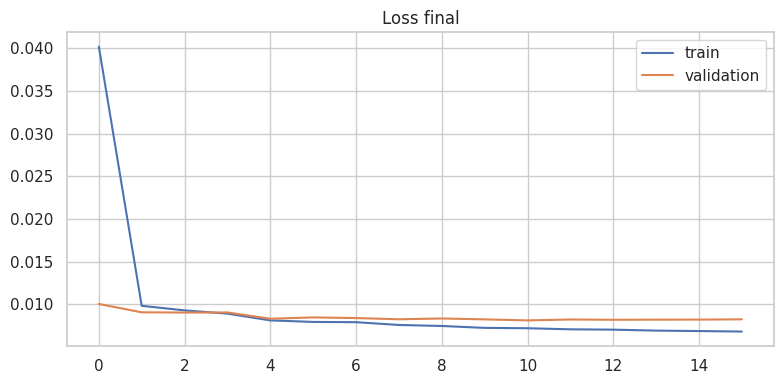

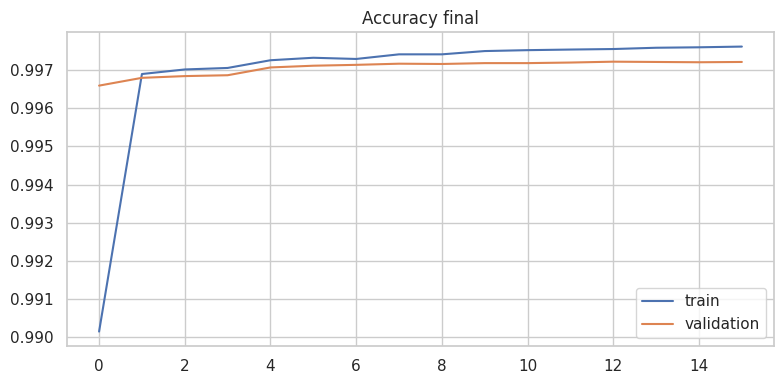

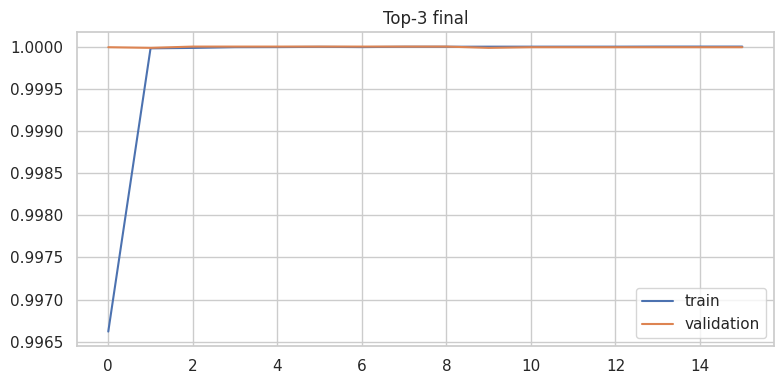

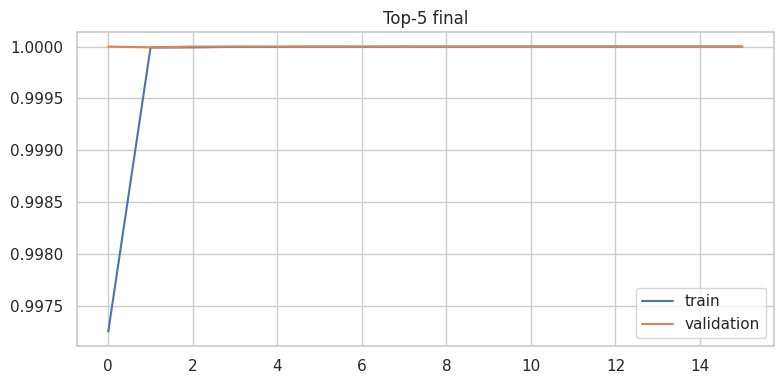

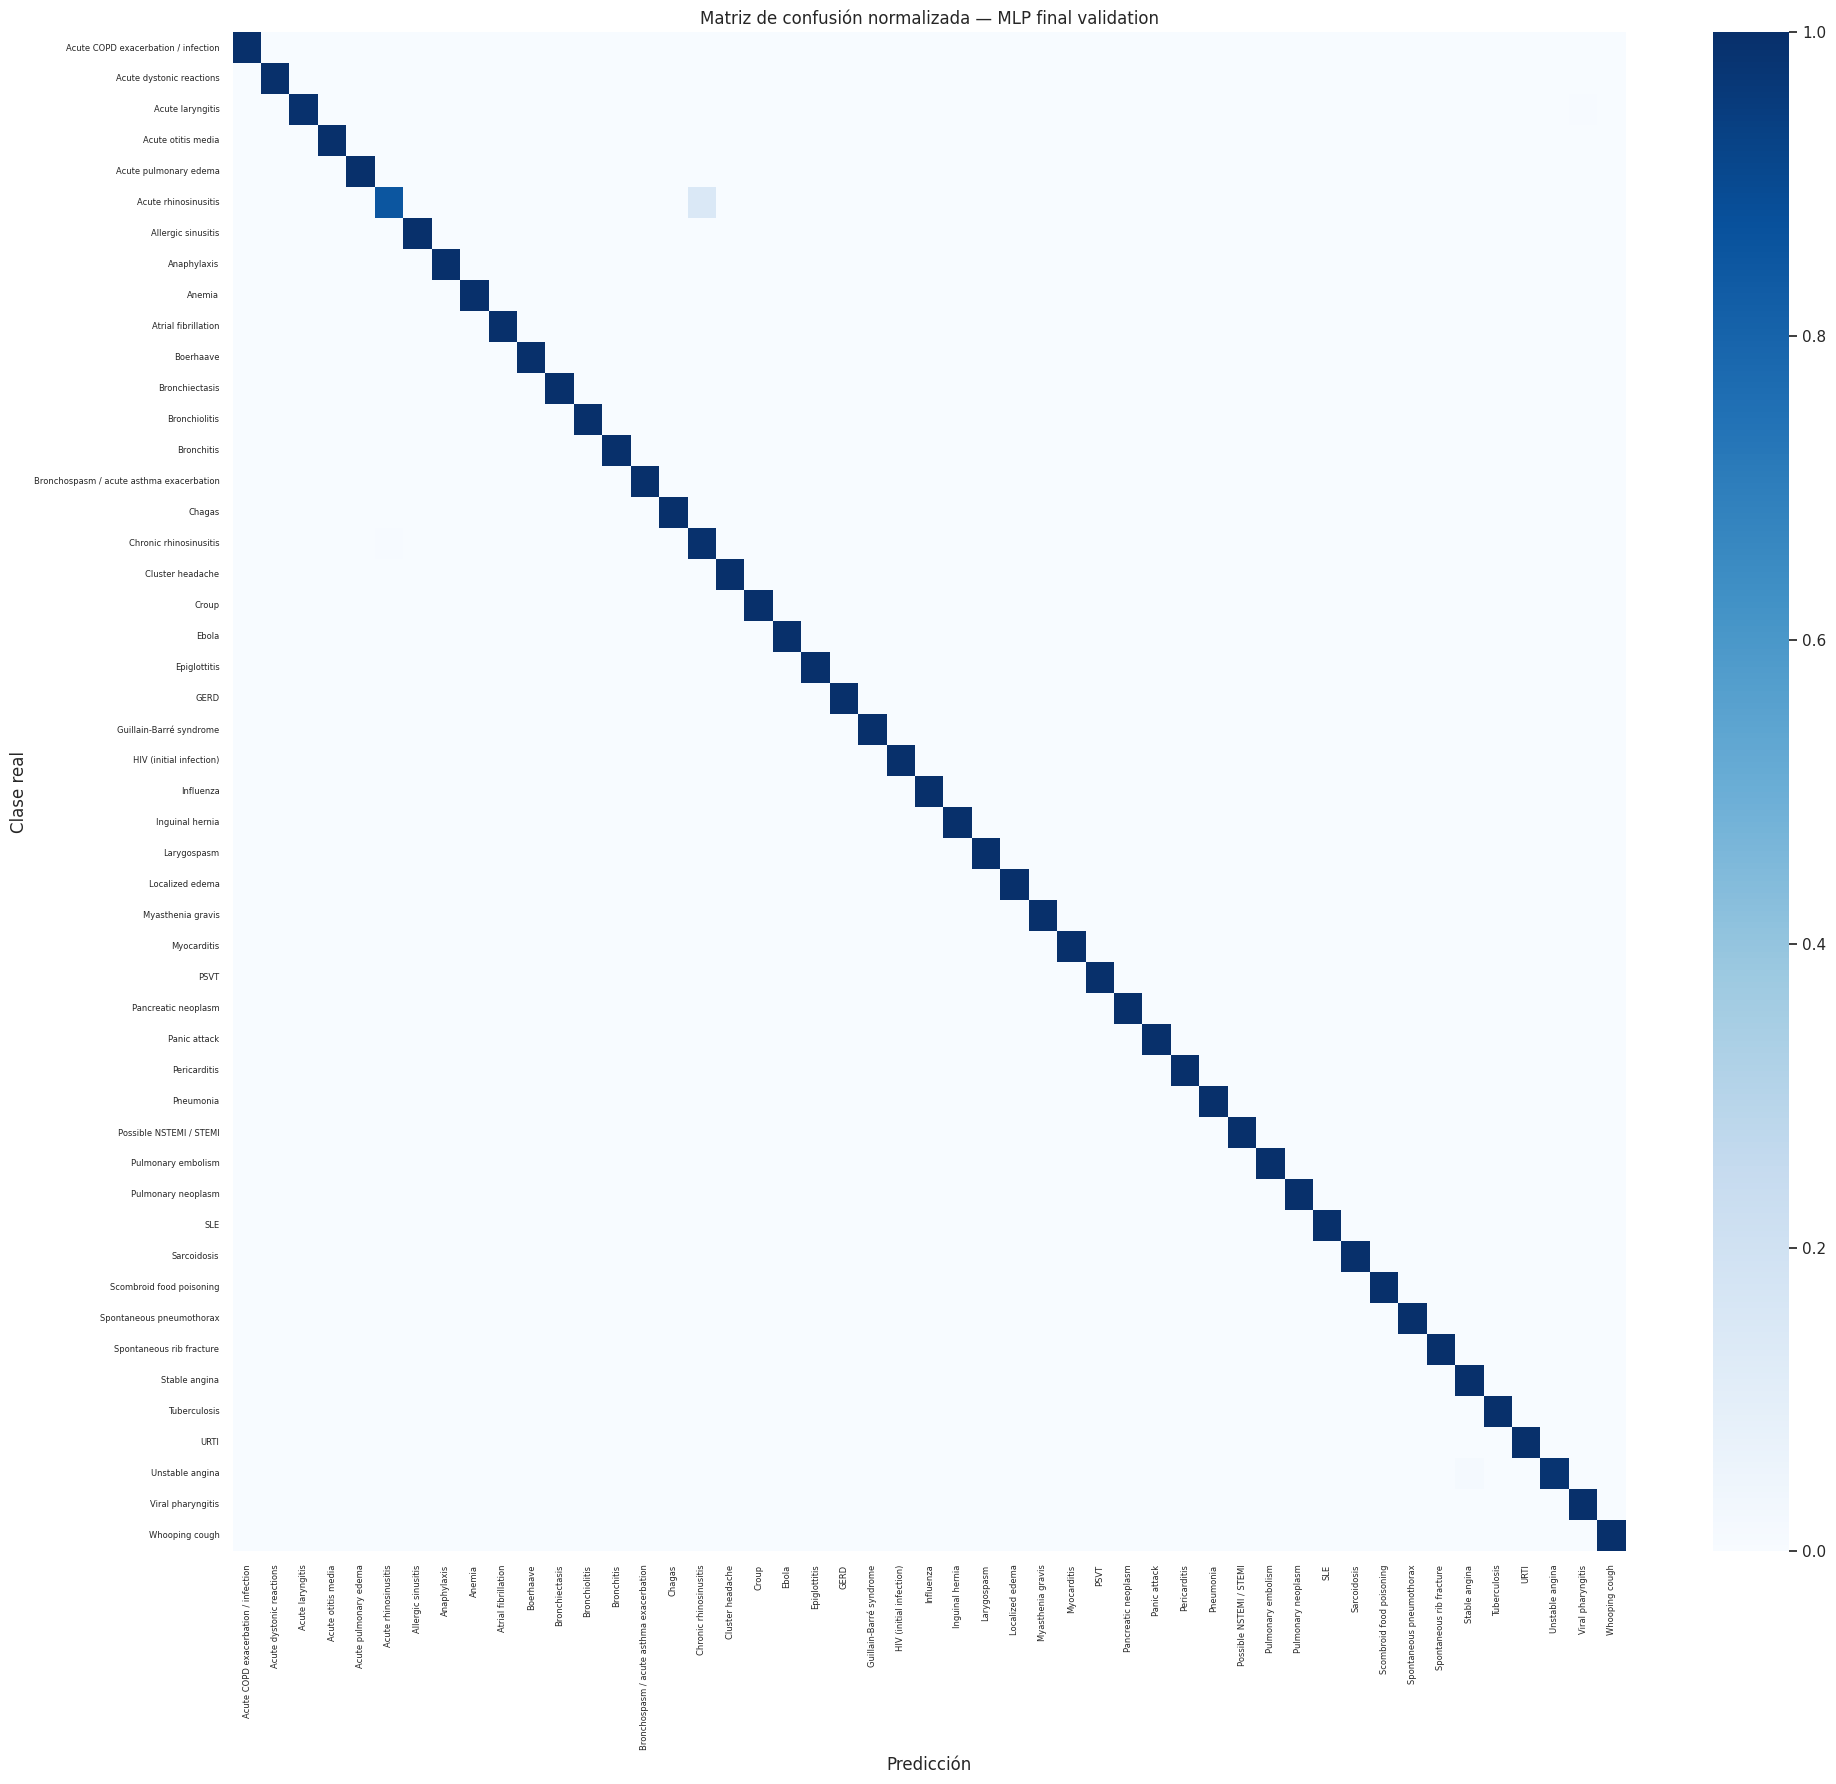

In [40]:
display(pd.DataFrame([final_validation_metrics]))
for train_key, val_key, title in [('loss','val_loss','Loss final'),('accuracy','val_accuracy','Accuracy final'),('top3','val_top3','Top-3 final'),('top5','val_top5','Top-5 final')]:
    plt.figure(figsize=(8,4)); plt.plot(final_history.history[train_key], label='train'); plt.plot(final_history.history[val_key], label='validation'); plt.title(title); plt.legend(); plt.tight_layout(); plt.show()
final_confusion_figure, final_confusion_axis = plot_normalized_confusion_matrix(y_val_final, final_val_predictions, final_preprocessing_metadata['class_names'], 'Matriz de confusión normalizada — MLP final validation')
plt.show()

In [41]:
def json_ready(value):
    if isinstance(value, (np.integer, np.floating)): return value.item()
    if isinstance(value, Path): return str(value)
    raise TypeError(f'No serializable: {type(value).__name__}')

final_manifest = {
    'config': FINAL_CONFIG,
    'n_features': 975,
    'n_classes': 49,
    'seed': TF_SEED,
    'train_rows': len(y_train_final),
    'validation_rows': len(y_val_final),
    'best_epoch': final_best_epoch,
    'validation_metrics': final_validation_metrics,
    'checkpoint_path': str(FINAL_CHECKPOINT_PATH),
    'status': 'frozen_before_test',
}
with FINAL_MANIFEST_PATH.open('w', encoding='utf-8') as handle:
    json.dump(final_manifest, handle, ensure_ascii=False, indent=2, default=json_ready)
print('Manifiesto pre-test guardado:', FINAL_MANIFEST_PATH)


Manifiesto pre-test guardado: /kaggle/working/vitalyx_final_manifest_pre_test.json


### 22.2 Evaluación final automática sobre test


test_final: 20,000/134,529 filas transformadas
test_final: 40,000/134,529 filas transformadas
test_final: 60,000/134,529 filas transformadas
test_final: 80,000/134,529 filas transformadas
test_final: 100,000/134,529 filas transformadas
test_final: 120,000/134,529 filas transformadas
test_final: 134,529/134,529 filas transformadas


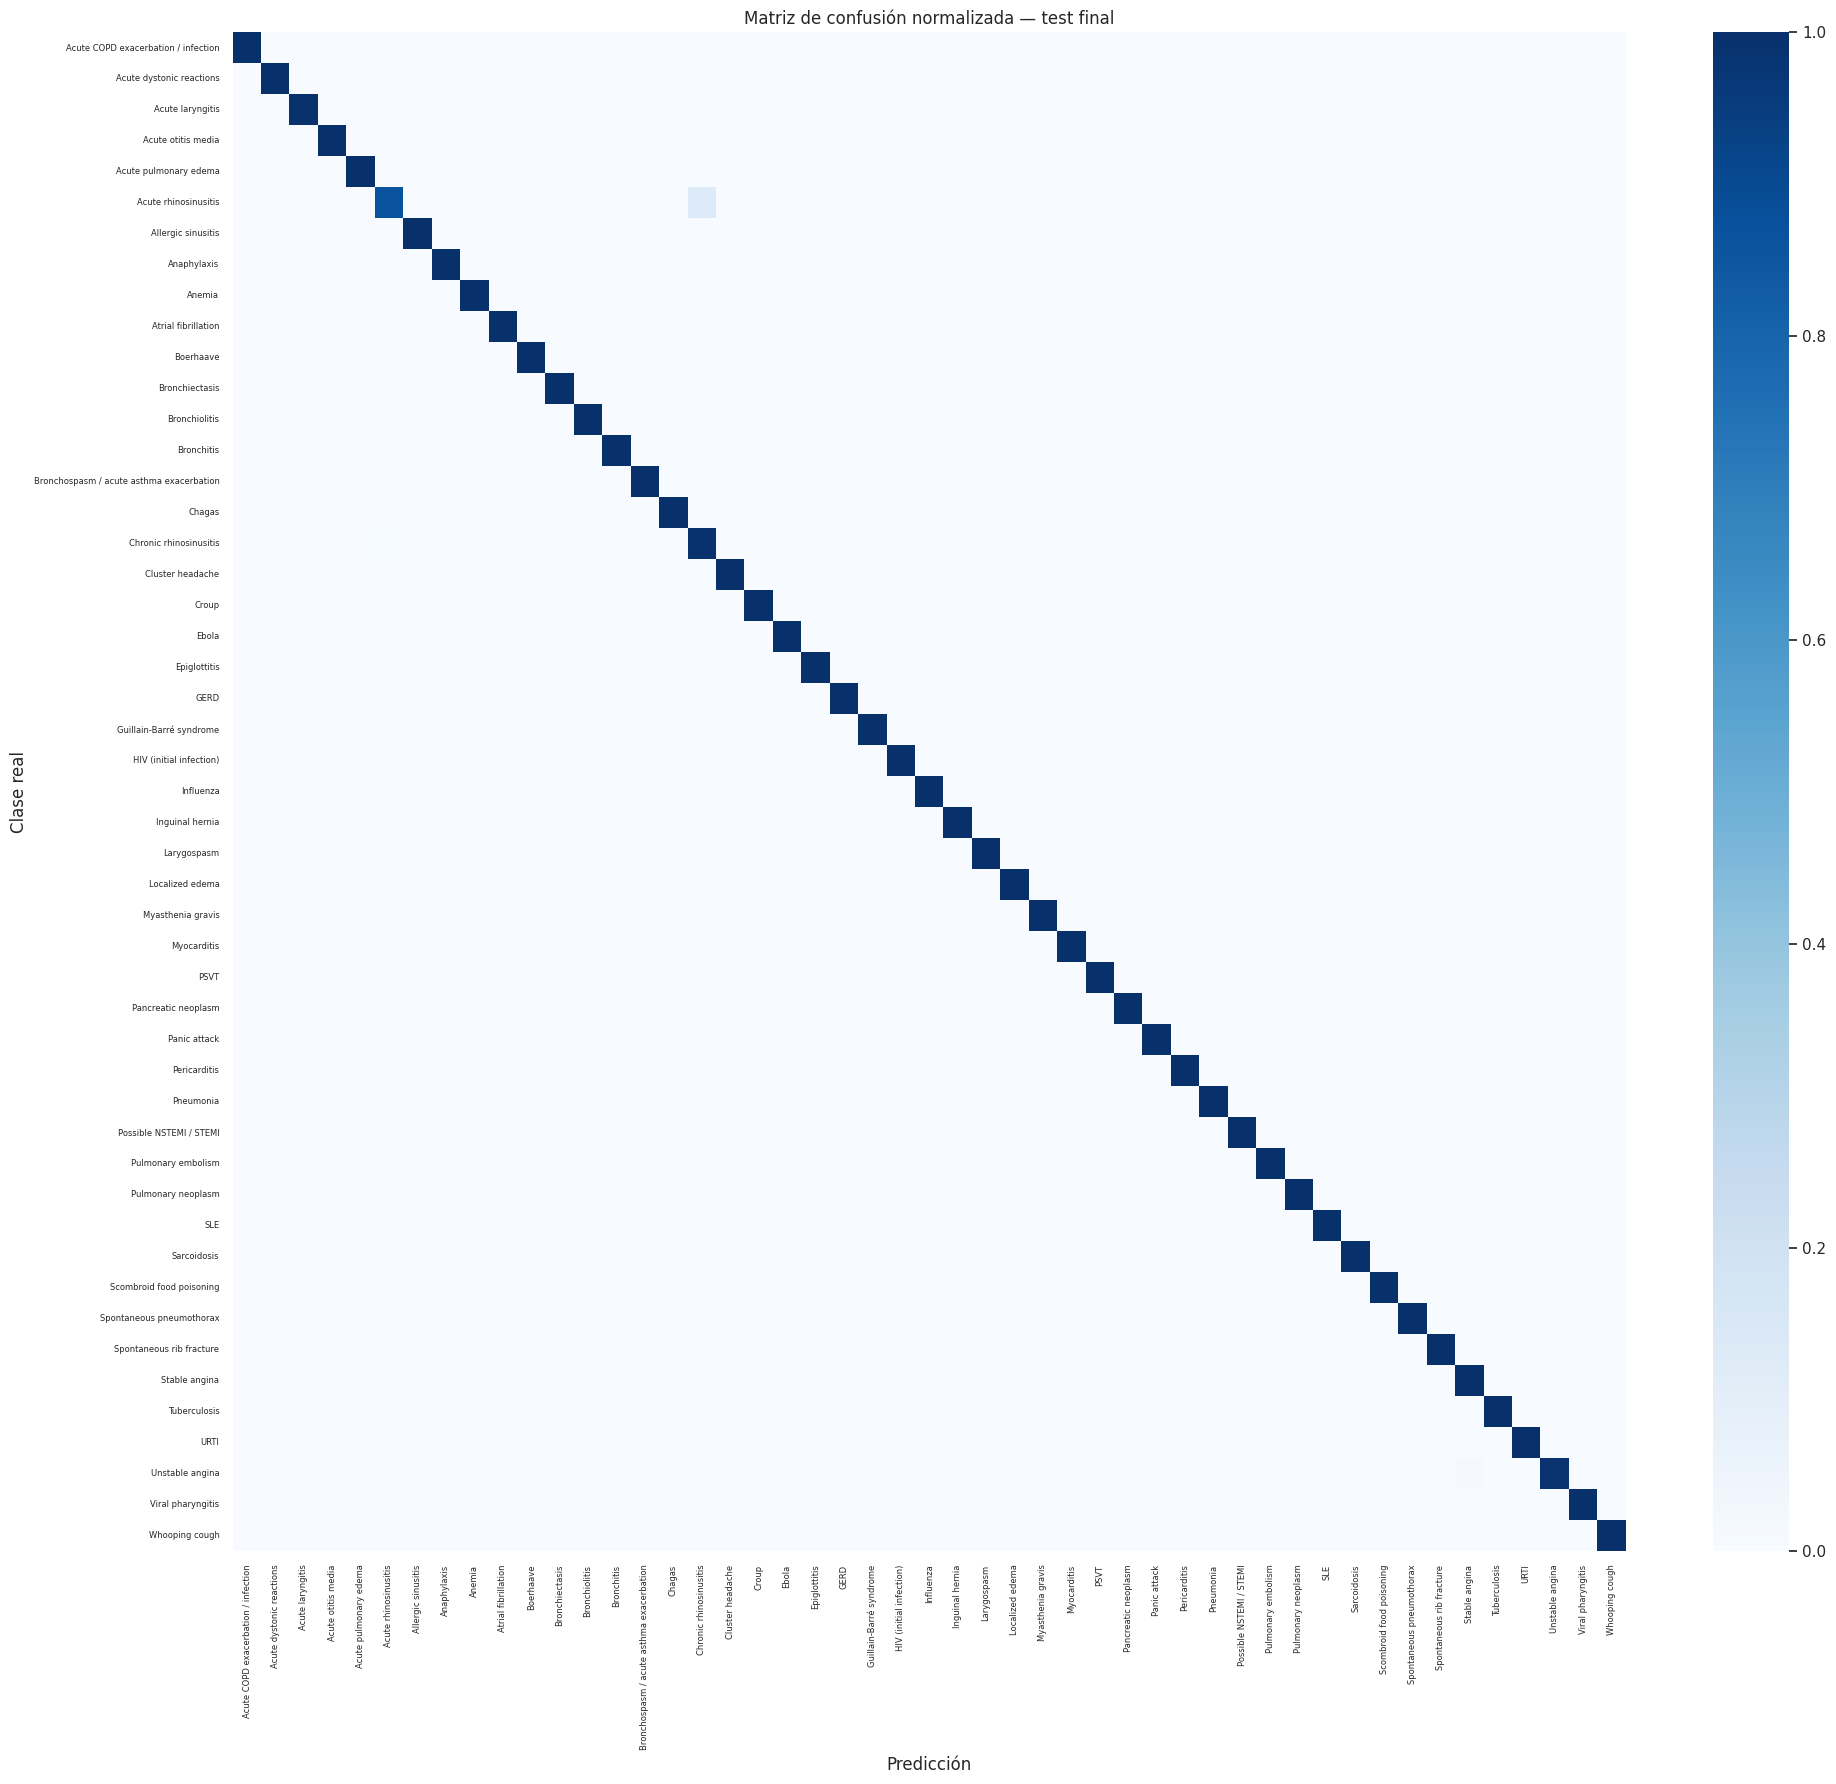

Test final evaluado una sola vez y resultado guardado: /kaggle/working/vitalyx_final_test_result.json


In [42]:
# Test final automático: se evalúa una sola vez por ejecución después de congelar E01.
if FINAL_TEST_EVALUATION_DONE:
    raise RuntimeError('La evaluación oficial de test ya fue ejecutada en este kernel.')
X_test_final, y_test_final, test_final_report = transform_split('test_final', splits['test'], final_preprocessing_metadata)
loaded_final_model = tf.keras.models.load_model(FINAL_CHECKPOINT_PATH)
test_sequence = CSRSequence(X_test_final, y_test_final, FINAL_CONFIG['batch_size'], False, TF_SEED)
test_probabilities = loaded_final_model.predict(test_sequence, steps=len(test_sequence), verbose=0)
test_predictions = test_probabilities.argmax(axis=1)
final_test_probabilities = test_probabilities
final_test_predictions = test_predictions
test_metrics = compute_classification_metrics(y_test_final, test_predictions)
test_metrics.update(compute_top_k_metrics(y_test_final, test_probabilities))
test_result = {
    'metrics': test_metrics, 'rows': len(y_test_final),
    'timestamp_utc': pd.Timestamp.utcnow().isoformat(),
    'status': 'test_evaluated', 'evaluated_once': True,
}
with FINAL_TEST_RESULT_PATH.open('w', encoding='utf-8') as handle:
    json.dump(test_result, handle, ensure_ascii=False, indent=2, default=json_ready)
plot_normalized_confusion_matrix(y_test_final, test_predictions, final_preprocessing_metadata['class_names'], 'Matriz de confusión normalizada — test final')
plt.show()
FINAL_TEST_EVALUATION_DONE = True
print(f'Test final evaluado una sola vez y resultado guardado: {FINAL_TEST_RESULT_PATH}')

In [43]:
with FINAL_TEST_RESULT_PATH.open(encoding="utf-8") as handle:
    saved_test_result = json.load(handle)

display(pd.DataFrame([saved_test_result["metrics"]]))
saved_test_result

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy
0,0.997,0.998,0.997,0.997,0.997,1.000,1.000


{'metrics': {'accuracy': 0.997494963911127,
  'precision_macro': 0.9975701403851963,
  'recall_macro': 0.9966846206645912,
  'f1_macro': 0.9970202058234288,
  'f1_weighted': 0.9974703635532955,
  'top3_accuracy': 1.0,
  'top5_accuracy': 1.0},
 'rows': 134529,
 'timestamp_utc': '2026-07-13T05:07:46.224805+00:00',
 'status': 'test_evaluated',
 'evaluated_once': True}

### 22.3 Resumen de entrenamiento final


In [44]:
display(Markdown(f'''### Resumen final controlado

- Configuración: E01, 975 características y 49 clases.
- Mejor época: {final_best_epoch}; F1 macro validation: {final_validation_metrics['f1_macro']:.6f}.
- Errores validation: Top-1={final_top1_errors}, Top-3={final_top3_errors}, Top-5={final_top5_errors}.
- Checkpoint: {FINAL_CHECKPOINT_PATH}.
- Manifiesto pre-test: {FINAL_MANIFEST_PATH}.
- Test se evalúa automáticamente después de congelar el modelo y no participó en entrenamiento, EarlyStopping ni selección.

No se combinó train con validation, no se usó test para selección y no se avanzó al Bloque 13.'''))

### Resumen final controlado

- Configuración: E01, 975 características y 49 clases.
- Mejor época: 11; F1 macro validation: 0.996631.
- Errores validation: Top-1=374, Top-3=1, Top-5=0.
- Checkpoint: /kaggle/working/vitalyx_final_best.keras.
- Manifiesto pre-test: /kaggle/working/vitalyx_final_manifest_pre_test.json.
- Test se evalúa automáticamente después de congelar el modelo y no participó en entrenamiento, EarlyStopping ni selección.

No se combinó train con validation, no se usó test para selección y no se avanzó al Bloque 13.

## 23. Comparación final de modelos

Comparación reproducible sobre train completo y validation oficial. Test no participa en la comparación.

In [45]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

FINAL_CLASS_INDICES = np.arange(49)

def train_and_evaluate_classical(model, model_name: str) -> dict[str, Any]:
    """Ajusta un baseline clásico en train full y lo evalúa únicamente en validation."""
    fit_started = time.perf_counter()
    model.fit(X_train_final, y_train_final)
    fit_seconds = time.perf_counter() - fit_started

    inference_started = time.perf_counter()
    predictions = model.predict(X_val_final)
    probabilities = model.predict_proba(X_val_final)
    inference_seconds = time.perf_counter() - inference_started

    if not np.array_equal(model.classes_, FINAL_CLASS_INDICES):
        raise ValueError(f'{model_name}: predict_proba no está alineado con las 49 clases oficiales.')
    if probabilities.shape != (len(y_val_final), 49):
        raise ValueError(f'{model_name}: forma de probabilidades inválida {probabilities.shape}.')

    metrics = compute_classification_metrics(y_val_final, predictions)
    metrics.update(compute_top_k_metrics(y_val_final, probabilities))
    metrics.update({
        'model': model_name,
        'train_rows': len(y_train_final),
        'validation_rows': len(y_val_final),
        'n_features': X_train_final.shape[1],
        'fit_seconds': fit_seconds,
        'inference_seconds': inference_seconds,
        'n_parameters': np.nan,
    })
    return metrics

final_classical_models = [
    ('DummyClassifier(prior)', DummyClassifier(strategy='prior', random_state=PREPROCESS_SEED)),
    ('LogisticRegression', LogisticRegression(solver='lbfgs', max_iter=300, random_state=PREPROCESS_SEED)),
    ('ExtraTreesClassifier', ExtraTreesClassifier(n_estimators=100, max_depth=24, n_jobs=-1, random_state=PREPROCESS_SEED)),
]
final_classical_results = [
    train_and_evaluate_classical(model, name) for name, model in final_classical_models
]


In [46]:
final_mlp_result = {
    'model': 'MLP final E01',
    'train_rows': len(y_train_final),
    'validation_rows': len(y_val_final),
    'n_features': X_train_final.shape[1],
    'n_parameters': final_parameter_count,
    **final_validation_metrics,
}
final_model_comparison = pd.DataFrame(final_classical_results + [final_mlp_result])
final_model_comparison = final_model_comparison.sort_values('f1_macro', ascending=False).reset_index(drop=True)
display(final_model_comparison)

mlp_reference = final_model_comparison.query("model == 'MLP final E01'").iloc[0]
comparison_vs_mlp = final_model_comparison.assign(
    delta_f1_macro=lambda frame: frame['f1_macro'] - mlp_reference['f1_macro'],
    delta_accuracy=lambda frame: frame['accuracy'] - mlp_reference['accuracy'],
    delta_fit_seconds=lambda frame: frame['fit_seconds'] - mlp_reference['fit_seconds'],
    delta_inference_seconds=lambda frame: frame['inference_seconds'] - mlp_reference['inference_seconds'],
)
display(comparison_vs_mlp[['model', 'delta_f1_macro', 'delta_accuracy', 'delta_fit_seconds', 'delta_inference_seconds']])


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy,model,train_rows,validation_rows,n_features,fit_seconds,inference_seconds,n_parameters
0,0.997,0.997,0.996,0.997,0.997,1.000,1.000,MLP final E01,1015440,132448,975,238.539,1.011,"672,561.000"
1,0.997,0.997,0.996,0.996,0.997,1.000,1.000,LogisticRegression,1015440,132448,975,89.039,0.505,NaN
2,0.995,0.996,0.993,0.994,0.995,1.000,1.000,ExtraTreesClassifier,1015440,132448,975,187.514,2.987,NaN
3,0.065,0.001,0.020,0.003,0.008,0.180,0.237,DummyClassifier(prior),1015440,132448,975,0.062,0.021,NaN


,model,delta_f1_macro,delta_accuracy,delta_fit_seconds,delta_inference_seconds
0,MLP final E01,0.000,0.000,0.000,0.000
1,LogisticRegression,-0.000,-0.000,-149.500,-0.506
2,ExtraTreesClassifier,-0.003,-0.002,-51.024,1.976
3,DummyClassifier(prior),-0.994,-0.932,-238.476,-0.990


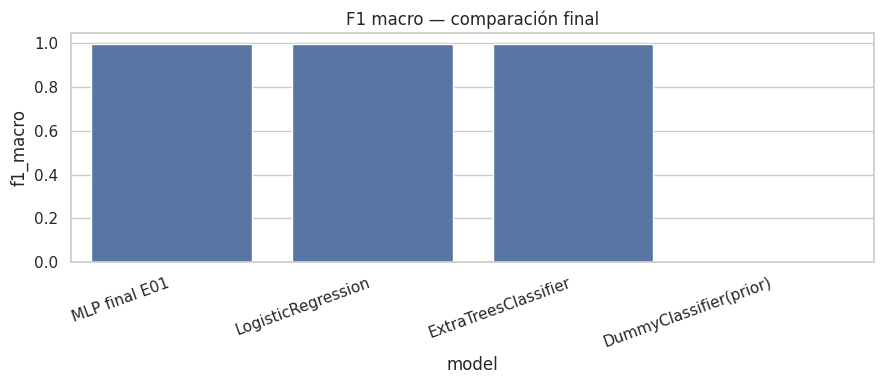

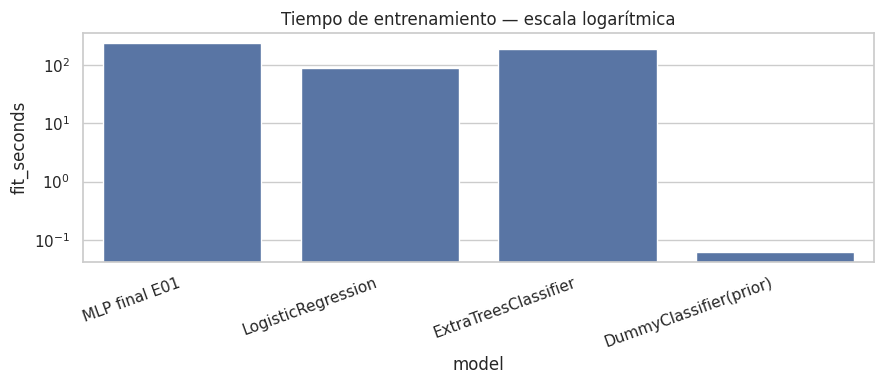

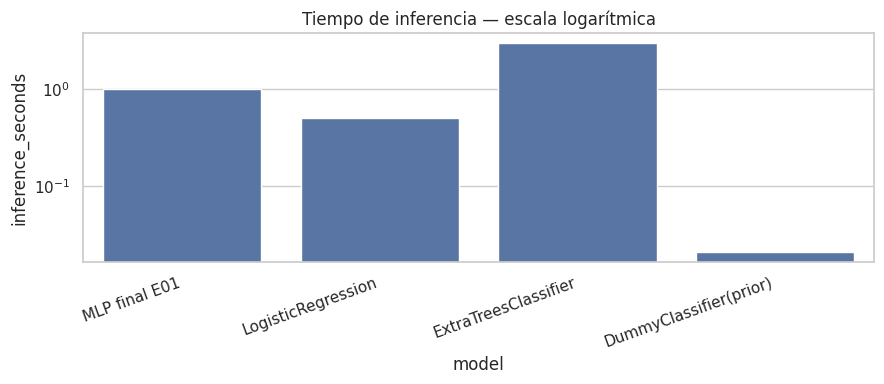

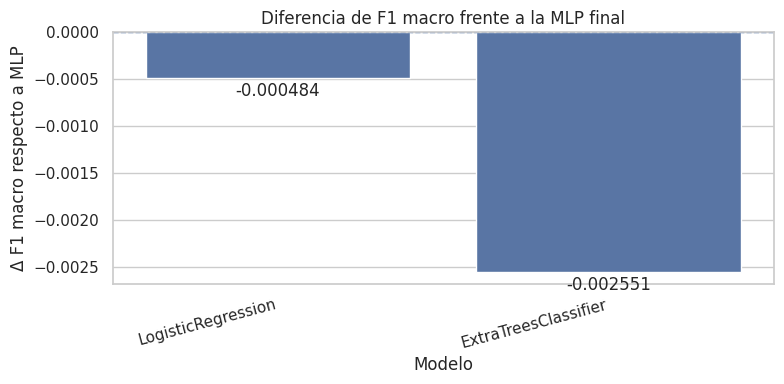

In [47]:
plt.figure(figsize=(9, 4))
sns.barplot(data=final_model_comparison, x='model', y='f1_macro')
plt.xticks(rotation=20, ha='right')
plt.title('F1 macro — comparación final')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=final_model_comparison, x='model', y='fit_seconds')
plt.yscale('log')
plt.xticks(rotation=20, ha='right')
plt.title('Tiempo de entrenamiento — escala logarítmica')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
sns.barplot(data=final_model_comparison, x='model', y='inference_seconds')
plt.yscale('log')
plt.xticks(rotation=20, ha='right')
plt.title('Tiempo de inferencia — escala logarítmica')
plt.tight_layout()
plt.show()


competitive_comparison = comparison_vs_mlp.query(
    "model != 'DummyClassifier(prior)' and model != 'MLP final E01'"
).copy()

plt.figure(figsize=(8, 4))

axis = sns.barplot(
    data=competitive_comparison,
    x='model',
    y='delta_f1_macro',
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.xticks(rotation=15, ha='right')
plt.ylabel('Δ F1 macro respecto a MLP')
plt.xlabel('Modelo')
plt.title('Diferencia de F1 macro frente a la MLP final')

for container in axis.containers:
    axis.bar_label(
        container,
        fmt='%.6f',
        padding=3,
    )

plt.tight_layout()
plt.show()


### 23.1 Conclusión automática

In [48]:
F1_FINAL_TOLERANCE = 1e-4
best_final_model = final_model_comparison.iloc[0]
fastest_final_model = final_model_comparison.loc[final_model_comparison['fit_seconds'].idxmin()]
final_logistic = final_model_comparison.query("model == 'LogisticRegression'").iloc[0]
final_delta_f1 = float(mlp_reference['f1_macro'] - final_logistic['f1_macro'])
mlp_relation = (
    'empata técnicamente con'
    if abs(final_delta_f1) <= F1_FINAL_TOLERANCE
    else 'supera    a' if final_delta_f1 > 0 else 'queda por debajo de'
)

display(Markdown(f'''### Comparación final

- Mejor F1 macro: **{best_final_model['model']}** ({best_final_model['f1_macro']:.6f}).
- Modelo más rápido de entrenar: **{fastest_final_model['model']}** ({fastest_final_model['fit_seconds']:.2f} s).
- La MLP final {mlp_relation} LogisticRegression; Δ F1 macro = {final_delta_f1:+.6f}, tolerancia = {F1_FINAL_TOLERANCE:.6f}.
- Los tiempos de la MLP incluyen conversión CSR a denso por lote; la comparación de inferencia no es estrictamente equivalente a los modelos CSR directos.
- Test solo fue utilizado para la evaluación final de la MLP seleccionada y no participa en esta comparación.
'''))

### Comparación final

- Mejor F1 macro: **MLP final E01** (0.996631).
- Modelo más rápido de entrenar: **DummyClassifier(prior)** (0.06 s).
- La MLP final supera    a LogisticRegression; Δ F1 macro = +0.000484, tolerancia = 0.000100.
- Los tiempos de la MLP incluyen conversión CSR a denso por lote; la comparación de inferencia no es estrictamente equivalente a los modelos CSR directos.
- Test solo fue utilizado para la evaluación final de la MLP seleccionada y no participa en esta comparación.


## 24. Inferencia Top-K individual

Interfaz individual reutilizable para el futuro endpoint de predicción. No usa variables objetivo ni información clínica adicional.

In [49]:
MODEL_DISCLAIMER = (
    'Modelo entrenado con pacientes sintéticos; resultado académico y orientativo. '
    'No constituye un diagnóstico médico.'
)

FINAL_INFERENCE_METADATA_KEYS = frozenset({
    'schema', 'age_mean', 'age_std', 'age_min', 'age_max', 'class_names',
})

def require_final_inference_metadata(fitted: Mapping[str, Any]) -> None:
    """Verifica que la metadata proceda del ajuste final de la sección 22.1."""
    missing = sorted(FINAL_INFERENCE_METADATA_KEYS.difference(fitted))
    if missing:
        raise RuntimeError(
            'final_preprocessing_metadata está incompleta (' + ', '.join(missing) +
            '). Ejecuta la celda 22.1 de preparación final antes del bloque 24.'
        )


def validate_inference_input(age: Any, sex: Any, evidences: Any, k: int, fitted: Mapping[str, Any]) -> tuple[float, str, list[str]]:
    """Valida y normaliza los campos de una entrada individual."""
    require_final_inference_metadata(fitted)
    if isinstance(age, (bool, np.bool_)):
        raise ValueError('age no puede ser booleana.')
    try:
        normalized_age = float(age)
    except (TypeError, ValueError) as exc:
        raise ValueError('age debe ser numérica.') from exc
    if not np.isfinite(normalized_age):
        raise ValueError('age debe ser finita.')
    age_min, age_max = fitted['age_min'], fitted['age_max']
    if not age_min <= normalized_age <= age_max:
        raise ValueError(f'age debe estar entre {age_min:g} y {age_max:g}.')
    normalized_sex = str(sex)
    if normalized_sex not in fitted['schema']['sex_indices']:
        raise ValueError(f'sex desconocido: {normalized_sex!r}.')
    if not isinstance(evidences, (list, tuple)) or not evidences:
        raise ValueError('evidences debe ser una lista o tupla no vacía de strings.')
    if not all(isinstance(token, str) for token in evidences):
        raise ValueError('Todos los elementos de evidences deben ser strings.')
    if isinstance(k, (bool, np.bool_)) or not isinstance(k, int) or not 1 <= k <= 49:
        raise ValueError('k debe ser un entero entre 1 y 49.')
    parsed = [parse_evidence_token(token) for token in evidences]
    invalid = [item.validation_error for item in parsed if not item.is_valid]
    if invalid:
        raise ValueError(f'Evidencias inválidas: {sorted(set(invalid))}.')
    return normalized_age, normalized_sex, list(evidences)

def transform_individual_input(age: Any, sex: Any, evidences: Any, fitted: Mapping[str, Any]) -> sparse.csr_matrix:
    """Convierte AGE, SEX y tokens DDXPlus a una matriz CSR 1 × 975."""
    normalized_age, normalized_sex, tokens = validate_inference_input(age, sex, evidences, 1, fitted)
    schema = fitted['schema']
    raw_evidences = repr(tokens)
    feature_values, errors = transform_evidence_list(raw_evidences, schema)
    if errors:
        raise ValueError(f'Evidencias inválidas: {sorted(set(errors))}.')
    rows = [0] * len(feature_values)
    columns = list(feature_values)
    data = list(feature_values.values())
    standardized_age = np.float32((normalized_age - fitted['age_mean']) / fitted['age_std'])
    if standardized_age != 0:
        rows.append(0); columns.append(0); data.append(standardized_age)
    rows.append(0); columns.append(schema['sex_indices'][normalized_sex]); data.append(np.float32(1))
    matrix = sparse.coo_matrix(
        (np.asarray(data, dtype=np.float32), (np.asarray(rows), np.asarray(columns))),
        shape=(1, len(schema['feature_names'])),
        dtype=np.float32,
    ).tocsr()
    if matrix.shape != (1, 975):
        raise RuntimeError(f'Forma individual inesperada: {matrix.shape}.')
    return matrix

def load_final_inference_model() -> tf.keras.Model:
    """Restaura explícitamente el checkpoint final congelado."""
    if not FINAL_CHECKPOINT_PATH.exists():
        raise RuntimeError('No existe el checkpoint final para inferencia.')
    return tf.keras.models.load_model(FINAL_CHECKPOINT_PATH)

def run_individual_model(matrix: sparse.csr_matrix, model: tf.keras.Model) -> np.ndarray:
    """Ejecuta inferencia directa sobre una matriz individual 1 × 975."""
    probabilities = model(matrix.toarray().astype(np.float32, copy=False), training=False).numpy()[0]
    if probabilities.shape != (49,) or not np.isfinite(probabilities).all() or not np.isclose(probabilities.sum(), 1.0, atol=1e-6):
        raise RuntimeError('El modelo devolvió probabilidades inválidas.')
    return probabilities

def build_top_k_response(age: float, sex: str, probabilities: np.ndarray, k: int, fitted: Mapping[str, Any]) -> dict[str, Any]:
    """Construye una respuesta JSON serializable ordenada por probabilidad."""
    indices = np.argsort(-probabilities)[:k]
    predictions = [
        {'rank': rank, 'pathology': str(fitted['class_names'][index]), 'probability': float(probabilities[index])}
        for rank, index in enumerate(indices, start=1)
    ]
    return {
        'top_k': int(k),
        'predictions': predictions,
        'model': 'Vitalyx final E01',
        'input_summary': {'age': float(age), 'sex': str(sex), 'evidence_count': int(0)},
        'disclaimer': MODEL_DISCLAIMER,
    }

def predict_top_k(age: Any, sex: Any, evidences: Any, k: int = 5, model: tf.keras.Model | None = None) -> dict[str, Any]:
    """Interfaz pública de inferencia individual Top-K."""
    normalized_age, normalized_sex, tokens = validate_inference_input(age, sex, evidences, k, final_preprocessing_metadata)
    matrix = transform_individual_input(normalized_age, normalized_sex, tokens, final_preprocessing_metadata)
    inference_model = model if model is not None else load_final_inference_model()
    probabilities = run_individual_model(matrix, inference_model)
    response = build_top_k_response(normalized_age, normalized_sex, probabilities, k, final_preprocessing_metadata)
    response['input_summary']['evidence_count'] = len(tokens)
    return response


In [50]:
validation_index = 0
validation_tokens = parse_for_inspection(splits['validation']['EVIDENCES'].iloc[validation_index])
validation_age = splits['validation']['AGE'].iloc[validation_index]
validation_sex = splits['validation']['SEX'].iloc[validation_index]

inference_model = load_final_inference_model()
top3_demo = predict_top_k(validation_age, validation_sex, validation_tokens, k=3, model=inference_model)
top5_demo = predict_top_k(validation_age, validation_sex, validation_tokens, k=5, model=inference_model)
assert len(top3_demo['predictions']) == 3
assert len(top5_demo['predictions']) == 5
display(pd.DataFrame(top3_demo['predictions']))
display(pd.DataFrame(top5_demo['predictions']).style.format({'probability': '{:.8f}'}))
assert json.dumps(top5_demo)

individual_matrix = transform_individual_input(validation_age, validation_sex, validation_tokens, final_preprocessing_metadata)
assert (individual_matrix != X_val_final[validation_index]).nnz == 0
individual_probabilities = run_individual_model(individual_matrix, inference_model)
batch_probabilities = final_val_probabilities[validation_index]
assert np.allclose(individual_probabilities, batch_probabilities, atol=1e-6)
assert [item['pathology'] for item in top5_demo['predictions']] == [
    final_preprocessing_metadata['class_names'][index] for index in np.argsort(-batch_probabilities)[:5]
]

invalid_cases = [
    ('edad', lambda: predict_top_k('no', validation_sex, validation_tokens, model=inference_model)),
    ('sexo', lambda: predict_top_k(validation_age, 'X', validation_tokens, model=inference_model)),
    ('codigo', lambda: predict_top_k(validation_age, validation_sex, ['E_DESCONOCIDA'], model=inference_model)),
    ('valor', lambda: predict_top_k(validation_age, validation_sex, ['E_59_@_VALOR_INVALIDO'], model=inference_model)),
    ('k', lambda: predict_top_k(validation_age, validation_sex, validation_tokens, k=50, model=inference_model)),
]
for label, call in invalid_cases:
    try:
        call()
        raise AssertionError(f'El caso inválido {label} debía fallar.')
    except ValueError:
        pass
print('Inferencia individual, equivalencia batch y validaciones negativas aprobadas.')


,rank,pathology,probability
0,1,Anemia,1.000
1,2,Unstable angina,0.000
2,3,Whooping cough,0.000


,rank,pathology,probability
0,1,Anemia,1.00000000
1,2,Unstable angina,0.00000000
2,3,Whooping cough,0.00000000
3,4,Myasthenia gravis,0.00000000
4,5,Croup,0.00000000


Inferencia individual, equivalencia batch y validaciones negativas aprobadas.


## 25. Análisis posterior del modelo final congelado

Interpretabilidad, equidad y calibración se realizan sobre el checkpoint E01 oficial. Validation guía los análisis; test no participa en decisiones posteriores.


In [51]:
ANALYSIS_REQUIRED_NAMES = [
    'final_model', 'final_preprocessing_metadata', 'final_val_probabilities',
    'final_val_predictions', 'X_val_final', 'y_val_final', 'y_train_final', 'splits',
]
missing_analysis_dependencies = [name for name in ANALYSIS_REQUIRED_NAMES if name not in globals()]
if missing_analysis_dependencies:
    raise RuntimeError('Faltan dependencias para los bloques 15–17: ' + ', '.join(missing_analysis_dependencies))
analysis_total_started = time.perf_counter()
INTERPRETABILITY_SEED = 42
INTERPRETABILITY_SAMPLE_SIZE = 2_048
INTERPRETABILITY_BATCH_SIZE = 256
analysis_rng = np.random.default_rng(INTERPRETABILITY_SEED)
interpretability_indices = np.sort(analysis_rng.choice(
    len(y_val_final), min(INTERPRETABILITY_SAMPLE_SIZE, len(y_val_final)), replace=False
))
assert X_val_final.shape[1] == len(final_preprocessing_metadata['schema']['feature_names']) == 975
assert final_val_probabilities.shape == (len(y_val_final), 49)
print(f'Muestra reproducible: {len(interpretability_indices):,} filas de validation; semilla={INTERPRETABILITY_SEED}.')


Muestra reproducible: 2,048 filas de validation; semilla=42.


### 25.1 Interpretabilidad global y local

Se aplica Gradiente × Entrada sobre la clase predicha en lotes pequeños. Resume sensibilidad local del modelo; no demuestra causalidad médica.


,feature,feature_label,mean_absolute_gradient_x_input
0,M::E_55::V_109,M — E_55: Do you feel pain somewhere? = V_109,0.001
1,M::E_55::V_122,M — E_55: Do you feel pain somewhere? = V_122,0.001
2,M::E_55::V_32,M — E_55: Do you feel pain somewhere? = V_32,0.001
3,M::E_55::V_108,M — E_55: Do you feel pain somewhere? = V_108,0.001
4,M::E_55::V_125,M — E_55: Do you feel pain somewhere? = V_125,0.001
5,M::E_55::V_89,M — E_55: Do you feel pain somewhere? = V_89,0.001
6,M::E_57::V_89,M — E_57: Does the pain radiate to another location? = V_89,0.001
7,M::E_55::V_126,M — E_55: Do you feel pain somewhere? = V_126,0.001
8,M::E_57::V_166,M — E_57: Does the pain radiate to another location? = V_166,0.001
9,M::E_57::V_25,M — E_57: Does the pain radiate to another location? = V_25,0.001


Importancia global: 2,048 filas en 0.16 s.


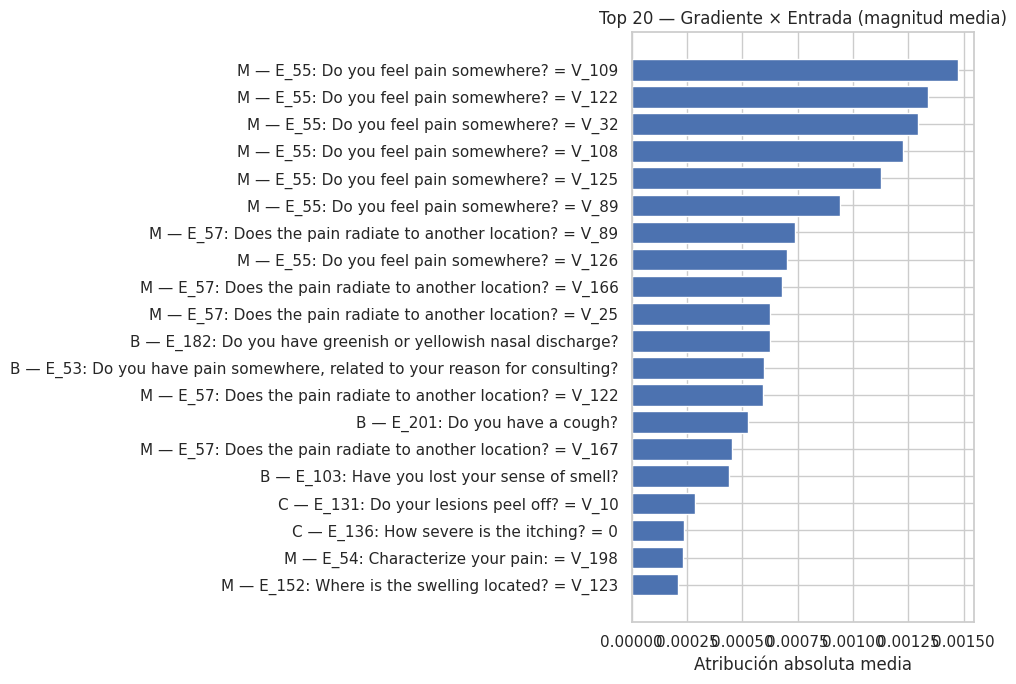

correcta_alta_confianza: real=Anemia; predicha=Anemia; confianza=1.000000


,feature,feature_label,feature_value,attribution,absolute_attribution
0,C::E_58::3,C — E_58: How precisely is the pain located? = 3,1.00000,0.0000000,0.0000000
1,C::E_56::2,C — E_56: How intense is the pain? = 2,1.00000,0.0000000,0.0000000
2,M::E_57::V_123,M — E_57: Does the pain radiate to another location? = V_123,1.00000,0.0000000,0.0000000
3,M::E_152::V_123,M — E_152: Where is the swelling located? = V_123,1.00000,0.0000000,0.0000000
4,C::E_59::5,C — E_59: How fast did the pain appear? = 5,1.00000,0.0000000,0.0000000
5,B::E_82,B — E_82: Do you feel lightheaded and dizzy or do you feel like you are about to faint?,1.00000,0.0000000,0.0000000
6,C::E_204::V_7,C — E_204: Have you traveled out of the country in the last 4 weeks? = V_7,1.00000,-0.0000000,0.0000000
7,C::E_131::V_10,C — E_131: Do your lesions peel off? = V_10,1.00000,-0.0000000,0.0000000
8,B::E_113,B — E_113: Do you have chronic kidney failure?,1.00000,0.0000000,0.0000000
9,B::E_76,B — E_76: Do you feel slightly dizzy or lightheaded?,1.00000,0.0000000,0.0000000


incorrecta_o_baja_confianza: real=Possible NSTEMI / STEMI; predicha=Stable angina; confianza=0.999681


,feature,feature_label,feature_value,attribution,absolute_attribution
0,M::E_57::V_178,M — E_57: Does the pain radiate to another location? = V_178,1.00000,0.0006906,0.0006906
1,M::E_55::V_31,M — E_55: Do you feel pain somewhere? = V_31,1.00000,0.0004421,0.0004421
2,M::E_57::V_174,M — E_57: Does the pain radiate to another location? = V_174,1.00000,0.0004034,0.0004034
3,B::E_89,B — E_89: Do you constantly feel fatigued or do you have non-restful sleep?,1.00000,-0.0003728,0.0003728
4,M::E_55::V_30,M — E_55: Do you feel pain somewhere? = V_30,1.00000,0.0003249,0.0003249
5,C::E_58::2,C — E_58: How precisely is the pain located? = 2,1.00000,0.0002945,0.0002945
6,C::E_59::8,C — E_59: How fast did the pain appear? = 8,1.00000,0.0002819,0.0002819
7,B::E_71,B — E_71: Do you have high cholesterol or do you take medications to treat high cholesterol?,1.00000,0.0002240,0.0002240
8,B::E_225,B — E_225: Do you have close family members who had a cardiovascular disease problem before the age of 50?,1.00000,0.0002131,0.0002131
9,M::E_55::V_39,M — E_55: Do you feel pain somewhere? = V_39,1.00000,0.0001885,0.0001885


Las atribuciones describen comportamiento del modelo; no son explicaciones clínicas causales.


In [52]:
def readable_feature_name(feature: str) -> str:
    if feature == 'AGE':
        return 'AGE — edad normalizada'
    if feature.startswith('SEX::'):
        return f"SEX — {feature.split('::', 1)[1]}"
    parts = feature.split('::', 2)
    if len(parts) < 2:
        return feature
    kind, code = parts[0], parts[1]
    metadata = EVIDENCE_METADATA.get(code, {})
    question = str(metadata.get('question_en') or metadata.get('question') or code).strip()
    question = question[:110] + ('…' if len(question) > 110 else '')
    suffix = '' if kind == 'B' or len(parts) < 3 else f" = {parts[2]}"
    return f"{kind} — {code}: {question}{suffix}"

def gradient_x_input(model, matrix, indices, batch_size=256):
    """Promedia |gradiente × entrada| sin densificar validation completa."""
    total = np.zeros(matrix.shape[1], dtype=np.float64)
    for start in range(0, len(indices), batch_size):
        batch_indices = indices[start:start + batch_size]
        inputs = tf.convert_to_tensor(matrix[batch_indices].toarray(), dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(inputs)
            probabilities = model(inputs, training=False)
            predicted = tf.argmax(probabilities, axis=1, output_type=tf.int32)
            selected = tf.reduce_sum(probabilities * tf.one_hot(predicted, 49), axis=1)
        total += np.abs((tape.gradient(selected, inputs) * inputs).numpy()).sum(axis=0)
    return total / len(indices)

def local_gradient_x_input(model, matrix, row_index, feature_names, top_n=12):
    inputs = tf.convert_to_tensor(matrix[row_index].toarray(), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(inputs); probabilities = model(inputs, training=False)
        predicted = int(tf.argmax(probabilities[0]).numpy()); selected = probabilities[0, predicted]
    values = inputs.numpy()[0]; attribution = (tape.gradient(selected, inputs) * inputs).numpy()[0]
    order = np.argsort(-np.abs(attribution))[:top_n]
    return pd.DataFrame({'feature': np.asarray(feature_names)[order], 'feature_label': [readable_feature_name(feature_names[i]) for i in order], 'feature_value': values[order],
                         'attribution': attribution[order], 'absolute_attribution': np.abs(attribution[order])})

interpretability_started = time.perf_counter()
feature_names_final = list(final_preprocessing_metadata['schema']['feature_names'])
global_importance_values = gradient_x_input(final_model, X_val_final, interpretability_indices, INTERPRETABILITY_BATCH_SIZE)
interpretability_seconds = time.perf_counter() - interpretability_started
global_feature_importance = pd.DataFrame({
    'feature': feature_names_final, 'feature_label': [readable_feature_name(name) for name in feature_names_final], 'mean_absolute_gradient_x_input': global_importance_values,
}).sort_values('mean_absolute_gradient_x_input', ascending=False, kind='stable').reset_index(drop=True)
display(global_feature_importance.head(20))
print(f'Importancia global: {len(interpretability_indices):,} filas en {interpretability_seconds:.2f} s.')
plt.figure(figsize=(10, 7)); table = global_feature_importance.head(20).iloc[::-1]
plt.barh(table.feature_label, table.mean_absolute_gradient_x_input)
plt.title('Top 20 — Gradiente × Entrada (magnitud media)'); plt.xlabel('Atribución absoluta media')
plt.tight_layout(); plt.show()

validation_confidence = final_val_probabilities.max(axis=1)
validation_correct = final_val_predictions == y_val_final
correct_rows = np.flatnonzero(validation_correct); error_rows = np.flatnonzero(~validation_correct)
local_correct_index = int(correct_rows[np.argmax(validation_confidence[correct_rows])])
local_challenging_index = int(error_rows[np.argmax(validation_confidence[error_rows])]) if len(error_rows) else int(np.argmin(validation_confidence))
local_explanations = {}
for label, row in [('correcta_alta_confianza', local_correct_index), ('incorrecta_o_baja_confianza', local_challenging_index)]:
    explanation = local_gradient_x_input(final_model, X_val_final, row, feature_names_final)
    local_explanations[label] = {'validation_index': row,
        'true_pathology': final_preprocessing_metadata['class_names'][int(y_val_final[row])],
        'predicted_pathology': final_preprocessing_metadata['class_names'][int(final_val_predictions[row])],
        'predicted_probability': float(validation_confidence[row]), 'attributions': explanation}
    print(f"{label}: real={local_explanations[label]['true_pathology']}; predicha={local_explanations[label]['predicted_pathology']}; confianza={validation_confidence[row]:.6f}")
    display(explanation.style.format({'feature_value':'{:.5f}','attribution':'{:.7f}','absolute_attribution':'{:.7f}'}))
print('Las atribuciones describen comportamiento del modelo; no son explicaciones clínicas causales.')


### 25.2 Sesgos y equidad por subgrupos

Las métricas macro se calculan solo sobre las clases presentes en cada subgrupo y se informa ese número, evitando interpretarlas como un macro promedio sobre clases ausentes.


In [53]:
def subgroup_metrics(group, mask):
    true, pred, proba = y_val_final[mask], final_val_predictions[mask], final_val_probabilities[mask]
    present = np.unique(true)
    if len(true) == 0: return {'group': group, 'n_cases': 0, 'classes_present': 0}
    precision, recall, f1, _ = precision_recall_fscore_support(true, pred, labels=present, average='macro', zero_division=0)
    result = {'group': group, 'n_cases': int(len(true)), 'classes_present': int(len(present)),
              'accuracy': float(accuracy_score(true, pred)), 'precision_macro_present_classes': float(precision),
              'recall_macro_present_classes': float(recall), 'f1_macro_present_classes': float(f1)}
    result.update(compute_top_k_metrics(true, proba)); return result

def group_table(groups): return pd.DataFrame([subgroup_metrics(name, np.asarray(mask, dtype=bool)) for name, mask in groups.items()])

validation_sex_values = splits['validation']['SEX'].astype(str).to_numpy()
validation_age_values = splits['validation']['AGE'].to_numpy(dtype=float)
sex_groups = {f'SEX={value}': validation_sex_values == value for value in sorted(np.unique(validation_sex_values))}
age_groups = {'AGE 0–17': validation_age_values <= 17, 'AGE 18–39': (validation_age_values >= 18) & (validation_age_values <= 39),
              'AGE 40–64': (validation_age_values >= 40) & (validation_age_values <= 64), 'AGE 65+': validation_age_values >= 65}
train_support = np.bincount(y_train_final, minlength=49); minority_cutoff = float(np.quantile(train_support, .25)); frequent_cutoff = float(np.quantile(train_support, .75))
frequency_groups = {f'Patologías minoritarias (train ≤ {minority_cutoff:.0f})': np.isin(y_val_final, np.flatnonzero(train_support <= minority_cutoff)),
                    f'Patologías frecuentes (train ≥ {frequent_cutoff:.0f})': np.isin(y_val_final, np.flatnonzero(train_support >= frequent_cutoff))}
subgroup_tables = {'sex': group_table(sex_groups), 'age': group_table(age_groups), 'pathology_frequency': group_table(frequency_groups)}
for dimension, table in subgroup_tables.items():
    print(f'\n{dimension}'); display(table.style.format({c:'{:.6f}' for c in table.columns if c not in {'group','n_cases','classes_present'}}))

gap_rows=[]
for dimension, table in subgroup_tables.items():
    for metric in ('accuracy','recall_macro_present_classes','f1_macro_present_classes','top3_accuracy','top5_accuracy'):
        valid=table[metric].dropna(); gap_rows.append({'dimension':dimension,'metric':metric,'absolute_gap':float(valid.max()-valid.min()),
            'best_group':table.loc[table[metric].idxmax(),'group'],'worst_group':table.loc[table[metric].idxmin(),'group']})
subgroup_gaps=pd.DataFrame(gap_rows).sort_values('absolute_gap',ascending=False,kind='stable'); display(subgroup_gaps)
print('Frecuencia de patología se define con train; el desempeño se mide solamente en validation.')



sex


,group,n_cases,classes_present,accuracy,precision_macro_present_classes,recall_macro_present_classes,f1_macro_present_classes,top3_accuracy,top5_accuracy
0,SEX=F,68133,49,0.997167,0.997289,0.996399,0.996711,0.999985,1.000000
1,SEX=M,64315,49,0.997186,0.997264,0.996097,0.996516,1.000000,1.000000



age


,group,n_cases,classes_present,accuracy,precision_macro_present_classes,recall_macro_present_classes,f1_macro_present_classes,top3_accuracy,top5_accuracy
0,AGE 0–17,24076,42,0.997466,0.996675,0.995953,0.996156,1.000000,1.000000
1,AGE 18–39,43902,47,0.997198,0.997348,0.996305,0.996675,1.000000,1.000000
2,AGE 40–64,44705,47,0.997025,0.997326,0.996299,0.996675,1.000000,1.000000
3,AGE 65+,19765,47,0.997116,0.997111,0.995724,0.996201,0.999949,1.000000



pathology_frequency


,group,n_cases,classes_present,accuracy,precision_macro_present_classes,recall_macro_present_classes,f1_macro_present_classes,top3_accuracy,top5_accuracy
0,Patologías minoritarias (train ≤ 15080),13867,13,0.980097,0.999885,0.988375,0.993679,1.000000,1.000000
1,Patologías frecuentes (train ≥ 25748),59628,13,0.999765,1.000000,0.999845,0.999922,1.000000,1.000000


,dimension,metric,absolute_gap,best_group,worst_group
10,pathology_frequency,accuracy,0.020,Patologías frecuentes (train ≥ 25748),Patologías minoritarias (train ≤ 15080)
11,pathology_frequency,recall_macro_present_classes,0.011,Patologías frecuentes (train ≥ 25748),Patologías minoritarias (train ≤ 15080)
12,pathology_frequency,f1_macro_present_classes,0.006,Patologías frecuentes (train ≥ 25748),Patologías minoritarias (train ≤ 15080)
6,age,recall_macro_present_classes,0.001,AGE 18–39,AGE 65+
7,age,f1_macro_present_classes,0.001,AGE 18–39,AGE 0–17
5,age,accuracy,0.000,AGE 0–17,AGE 40–64
1,sex,recall_macro_present_classes,0.000,SEX=F,SEX=M
2,sex,f1_macro_present_classes,0.000,SEX=F,SEX=M
8,age,top3_accuracy,0.000,AGE 0–17,AGE 65+
0,sex,accuracy,0.000,SEX=M,SEX=F


Frecuencia de patología se define con train; el desempeño se mide solamente en validation.


### 25.3 Calibración e incertidumbre

Se analizan probabilidades originales de validation. No se ajusta temperature scaling ni se sobrescriben probabilidades del modelo.


,metric,value
0,Top-1 accuracy,0.997
1,Top-3 accuracy,1.000
2,Top-1 errors,374.000
3,Top-3 errors,1.000


,outcome,n_cases,mean_max_probability
0,all,132448,0.997176
1,correct,132074,0.997716
2,top1_error,374,0.806540


,bin,n_cases,mean_confidence,empirical_accuracy,calibration_gap
0,7,24,0.518083,0.333333,-0.184749
1,8,57,0.564332,0.578947,0.014615
2,9,69,0.632448,0.652174,0.019726
3,10,65,0.703800,0.661538,-0.042261
4,11,219,0.771611,0.726027,-0.045584
5,12,611,0.836912,0.849427,0.012515
6,13,797,0.901534,0.905897,0.004363
7,14,130606,0.999504,0.999533,0.000029


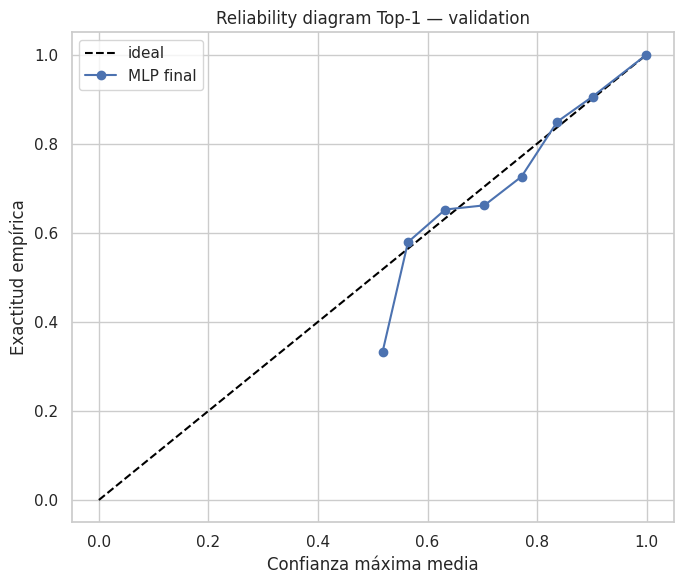

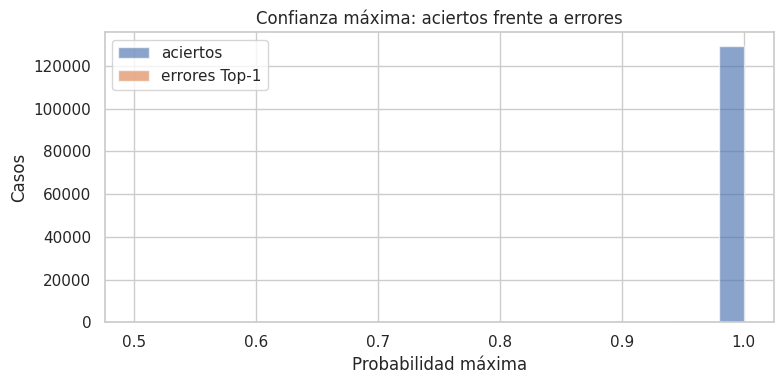

Errores Top-1 con confianza ≥ 0.90: 95. ECE=0.000259; Brier=0.004522; NLL=0.008131.


,validation_index,true_pathology,predicted_pathology,predicted_probability
0,1967,Unstable angina,Stable angina,0.998733
1,2785,Bronchitis,Acute COPD exacerbation / infection,0.993501
2,3277,Acute rhinosinusitis,Chronic rhinosinusitis,0.958997
3,6188,Croup,Larygospasm,0.968354
4,7084,Unstable angina,Stable angina,0.955066
5,7287,Acute rhinosinusitis,Chronic rhinosinusitis,0.905055
6,10661,Unstable angina,Stable angina,0.992044
7,10814,Unstable angina,Stable angina,0.953658
8,11405,Acute rhinosinusitis,Chronic rhinosinusitis,0.921862
9,11511,Acute rhinosinusitis,Chronic rhinosinusitis,0.915830


,threshold,coverage,accepted_cases,accepted_accuracy,abstention_rate
0,0.500771,1.000000,132448,0.997176,0.000000
1,1.000000,0.950094,125838,1.000000,0.049906
2,1.000000,0.944129,125048,1.000000,0.055871


,dimension,group,n_cases,low_confidence_rate,accepted_accuracy
0,sex,SEX=F,68133,0.051209,1.000000
1,sex,SEX=M,64315,0.048527,1.000000
2,age,AGE 0–17,24076,0.027289,1.000000
3,age,AGE 18–39,43902,0.054348,1.000000
4,age,AGE 40–64,44705,0.056548,1.000000
5,age,AGE 65+,19765,0.052568,1.000000
6,pathology_frequency,Patologías minoritarias (train ≤ 15080),13867,0.055888,1.000000
7,pathology_frequency,Patologías frecuentes (train ≥ 25748),59628,0.005920,1.000000


No se detectó una brecha ≥ 0.03; se conserva monitoreo por subgrupo sin aplicar mitigación específica.


### Conclusión conjunta de los bloques 15–17

- Interpretabilidad: Gradiente × Entrada sobre 2,048 filas en 0.16 s; las atribuciones no son causales.
- Mayor brecha: pathology_frequency / accuracy = 0.019669.
- Calibración original: ECE=0.000259, Brier=0.004522, NLL=0.008131; errores de alta confianza=95.
- Incertidumbre: marcar baja confianza cuando la probabilidad máxima sea < 1.000000; cobertura=95.009%, sin reentrenar ni modificar E01.
- Equidad: No se detectó una brecha ≥ 0.03; se conserva monitoreo por subgrupo sin aplicar mitigación específica.
- Tiempo total añadido: 4.85 s. Test no se usó para interpretación, equidad, calibración ni selección de umbral.

In [54]:
def top_label_calibration(y_true, probabilities, n_bins=15):
    confidence=probabilities.max(axis=1); correct=probabilities.argmax(axis=1)==y_true; bins=np.minimum((confidence*n_bins).astype(int),n_bins-1); rows=[]; ece=0.0
    for b in range(n_bins):
        mask=bins==b
        if not mask.any(): continue
        n=int(mask.sum()); mean_conf=float(confidence[mask].mean()); empirical=float(correct[mask].mean()); ece += abs(empirical-mean_conf)*n/len(y_true)
        rows.append({'bin':b,'n_cases':n,'mean_confidence':mean_conf,'empirical_accuracy':empirical,'calibration_gap':empirical-mean_conf})
    return pd.DataFrame(rows),float(ece)

def multiclass_brier(y_true, probabilities):
    return float(np.mean(np.sum((probabilities-np.eye(probabilities.shape[1],dtype=np.float32)[y_true])**2,axis=1)))

def multiclass_nll(y_true, probabilities): return float(-np.mean(np.log(np.clip(probabilities[np.arange(len(y_true)),y_true],1e-12,1.0))))

def select_low_confidence_threshold(confidence, correct):
    rows=[]
    for threshold in np.unique(np.quantile(confidence,np.linspace(0,.95,20))):
        accepted=confidence>=threshold; rows.append({'threshold':float(threshold),'coverage':float(accepted.mean()),'accepted_cases':int(accepted.sum()),
            'accepted_accuracy':float(correct[accepted].mean()) if accepted.any() else np.nan,'abstention_rate':float((~accepted).mean())})
    table=pd.DataFrame(rows); target=min(.999,max(float(correct.mean())+.001,.99)); eligible=table[(table.coverage>=.75)&(table.accepted_accuracy>=target)]
    return float((eligible.iloc[0] if len(eligible) else table.iloc[-1]).threshold),table

final_validation_ranks = np.argmax(np.argsort(-final_val_probabilities, axis=1) == y_val_final[:, None], axis=1) + 1
top1_vs_top3 = pd.DataFrame({
    'metric': ['Top-1 accuracy', 'Top-3 accuracy', 'Top-1 errors', 'Top-3 errors'],
    'value': [float((final_validation_ranks <= 1).mean()), float((final_validation_ranks <= 3).mean()), int((final_validation_ranks > 1).sum()), int((final_validation_ranks > 3).sum())],
})
display(top1_vs_top3)
reliability_table, final_validation_ece=top_label_calibration(y_val_final,final_val_probabilities)
final_validation_brier=multiclass_brier(y_val_final,final_val_probabilities); final_validation_nll=multiclass_nll(y_val_final,final_val_probabilities)
confidence_summary=pd.DataFrame({'outcome':['all','correct','top1_error'],'n_cases':[len(validation_confidence),int(validation_correct.sum()),int((~validation_correct).sum())],
    'mean_max_probability':[float(validation_confidence.mean()),float(validation_confidence[validation_correct].mean()),float(validation_confidence[~validation_correct].mean())]})
display(confidence_summary.style.format({'mean_max_probability':'{:.6f}'})); display(reliability_table.style.format({'mean_confidence':'{:.6f}','empirical_accuracy':'{:.6f}','calibration_gap':'{:.6f}'}))
plt.figure(figsize=(7,6)); plt.plot([0,1],[0,1],'--',color='black',label='ideal'); plt.plot(reliability_table.mean_confidence,reliability_table.empirical_accuracy,'o-',label='MLP final')
plt.title('Reliability diagram Top-1 — validation'); plt.xlabel('Confianza máxima media'); plt.ylabel('Exactitud empírica'); plt.legend(); plt.tight_layout(); plt.show()
plt.figure(figsize=(8,4)); plt.hist(validation_confidence[validation_correct],bins=25,alpha=.65,label='aciertos'); plt.hist(validation_confidence[~validation_correct],bins=25,alpha=.65,label='errores Top-1')
plt.title('Confianza máxima: aciertos frente a errores'); plt.xlabel('Probabilidad máxima'); plt.ylabel('Casos'); plt.legend(); plt.tight_layout(); plt.show()
high_confidence_error_threshold=.90; high_confidence_errors=np.flatnonzero((~validation_correct)&(validation_confidence>=high_confidence_error_threshold))
high_confidence_error_table=pd.DataFrame({'validation_index':high_confidence_errors[:20],
    'true_pathology':[final_preprocessing_metadata['class_names'][int(y_val_final[i])] for i in high_confidence_errors[:20]],
    'predicted_pathology':[final_preprocessing_metadata['class_names'][int(final_val_predictions[i])] for i in high_confidence_errors[:20]],
    'predicted_probability':validation_confidence[high_confidence_errors[:20]]})
print(f'Errores Top-1 con confianza ≥ {high_confidence_error_threshold:.2f}: {len(high_confidence_errors):,}. ECE={final_validation_ece:.6f}; Brier={final_validation_brier:.6f}; NLL={final_validation_nll:.6f}.')
display(high_confidence_error_table.style.format({'predicted_probability':'{:.6f}'}))
LOW_CONFIDENCE_THRESHOLD,confidence_policy_table=select_low_confidence_threshold(validation_confidence,validation_correct)
selected_policy=confidence_policy_table.loc[np.isclose(confidence_policy_table.threshold,LOW_CONFIDENCE_THRESHOLD)].iloc[0]; display(confidence_policy_table.style.format({'threshold':'{:.6f}','coverage':'{:.6f}','accepted_accuracy':'{:.6f}','abstention_rate':'{:.6f}'}))
RELEVANT_SUBGROUP_GAP = 0.03
relevant_subgroup_gap = bool(subgroup_gaps['absolute_gap'].max() >= RELEVANT_SUBGROUP_GAP)
policy_acceptance=validation_confidence>=LOW_CONFIDENCE_THRESHOLD; mitigation_rows=[]
for dimension,groups in {'sex':sex_groups,'age':age_groups,'pathology_frequency':frequency_groups}.items():
    for group,mask in groups.items():
        accepted=policy_acceptance[mask]; correct=validation_correct[mask]; mitigation_rows.append({'dimension':dimension,'group':group,'n_cases':int(mask.sum()),'low_confidence_rate':float((~accepted).mean()),'accepted_accuracy':float(correct[accepted].mean()) if accepted.any() else np.nan})
mitigation_table=pd.DataFrame(mitigation_rows); display(mitigation_table.style.format({'low_confidence_rate':'{:.6f}','accepted_accuracy':'{:.6f}'}))
mitigation_action = (
    f'Brecha relevante (≥ {RELEVANT_SUBGROUP_GAP:.2f}): la interfaz debe mostrar la advertencia de baja confianza y documentar el subgrupo con peor desempeño.'
    if relevant_subgroup_gap else
    f'No se detectó una brecha ≥ {RELEVANT_SUBGROUP_GAP:.2f}; se conserva monitoreo por subgrupo sin aplicar mitigación específica.'
)
print(mitigation_action)
analysis_total_seconds = time.perf_counter() - analysis_total_started
summary = '### Conclusión conjunta de los bloques 15–17\n\n' +     f'- Interpretabilidad: Gradiente × Entrada sobre {len(interpretability_indices):,} filas en {interpretability_seconds:.2f} s; las atribuciones no son causales.\n' +     f"- Mayor brecha: {subgroup_gaps.iloc[0]['dimension']} / {subgroup_gaps.iloc[0]['metric']} = {subgroup_gaps.iloc[0]['absolute_gap']:.6f}.\n" +     f'- Calibración original: ECE={final_validation_ece:.6f}, Brier={final_validation_brier:.6f}, NLL={final_validation_nll:.6f}; errores de alta confianza={len(high_confidence_errors):,}.\n' +     f'- Incertidumbre: marcar baja confianza cuando la probabilidad máxima sea < {LOW_CONFIDENCE_THRESHOLD:.6f}; cobertura={selected_policy.coverage:.3%}, sin reentrenar ni modificar E01.\n' +     f'- Equidad: {mitigation_action}\n' +     f'- Tiempo total añadido: {analysis_total_seconds:.2f} s. Test no se usó para interpretación, equidad, calibración ni selección de umbral.'
display(Markdown(summary))


## 26. Exportación y resumen reproducible

Los artefactos proceden exclusivamente del modelo final congelado y sus resultados oficiales.


In [55]:
import hashlib
import platform
import shutil
import subprocess
import zipfile
import scipy
import sklearn

EXPORT_REQUIRED_NAMES = [
    'final_preprocessing_metadata', 'EVIDENCE_METADATA', 'conditions_metadata', 'FINAL_CONFIG',
    'FINAL_CHECKPOINT_PATH', 'final_parameter_count', 'final_validation_metrics', 'test_metrics',
    'final_model_comparison', 'global_feature_importance', 'subgroup_gaps', 'subgroup_tables',
    'final_validation_ece', 'final_validation_brier', 'final_validation_nll',
    'LOW_CONFIDENCE_THRESHOLD', 'MODEL_DISCLAIMER', 'validation_age', 'validation_sex', 'validation_tokens', 'experimental_evidence',
]
missing_export_dependencies = [name for name in EXPORT_REQUIRED_NAMES if name not in globals()]
if missing_export_dependencies:
    raise RuntimeError('Faltan resultados para exportar artefactos: ' + ', '.join(missing_export_dependencies))

ARTIFACT_DIR = Path('/kaggle/working/vitalyx_artifacts')
ARTIFACT_ZIP_PATH = Path('/kaggle/working/vitalyx_artifacts.zip')
if ARTIFACT_DIR.exists():
    shutil.rmtree(ARTIFACT_DIR)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def json_compatible(value):
    if isinstance(value, Mapping): return {str(key): json_compatible(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set, frozenset)): return [json_compatible(item) for item in value]
    if isinstance(value, np.ndarray): return [json_compatible(item) for item in value.tolist()]
    if isinstance(value, (np.integer, np.floating, np.bool_)): return value.item()
    if isinstance(value, Path): return str(value)
    if value is None or isinstance(value, (str, int, float, bool)): return value
    raise TypeError(f'No serializable: {type(value).__name__}')

def write_json_artifact(filename, payload):
    target = ARTIFACT_DIR / filename
    target.write_text(json.dumps(json_compatible(payload), ensure_ascii=False, indent=2), encoding='utf-8')
    return target

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1_048_576), b''): digest.update(chunk)
    return digest.hexdigest()

def normalized_evidence_metadata(metadata):
    output = {}
    for code, entry in metadata.items():
        output[str(code)] = {
            'data_type': str(entry.get('data_type')),
            'allowed_values': sorted(allowed_values(entry)),
            'default_values': default_values(entry),
            'question': str(entry.get('question_en') or entry.get('question') or code),
            'is_antecedent': bool(entry.get('is_antecedent', False)),
        }
    return output

artifact_preprocessing = json_compatible(final_preprocessing_metadata)
artifact_evidence_metadata = normalized_evidence_metadata(EVIDENCE_METADATA)
artifact_conditions_metadata = json_compatible(conditions_metadata)
model_config_export = {
    'model_name': 'Vitalyx final E01', 'configuration': FINAL_CONFIG,
    'n_parameters': int(final_parameter_count), 'seed': int(TF_SEED),
    'dataset_version': 'ddxplus-english-v2', 'feature_count': 975, 'class_count': 49,
}
final_metrics_export = {
    'validation': final_validation_metrics, 'test': test_metrics,
    'model_comparison_validation': final_model_comparison.to_dict(orient='records'),
    'calibration_validation': {'ece': final_validation_ece, 'brier_multiclass': final_validation_brier, 'negative_log_loss': final_validation_nll},
    'subgroup_gaps_validation': subgroup_gaps.to_dict(orient='records'),
    'low_confidence_threshold': LOW_CONFIDENCE_THRESHOLD,
    'experimental_fast': {
        'preprocessing_reports': experimental_evidence['preprocessing_reports'].to_dict(orient='records'),
        'feature_selection_summary': experimental_evidence['feature_selection_summary'],
        'baseline_table': experimental_evidence['baseline_table'].to_dict(orient='records'),
        'balanced_comparison': experimental_evidence['balanced_comparison'].to_dict(orient='records'),
        'feature_activity_summary': experimental_evidence['feature_activity_summary'].to_dict(orient='records'),
        'mlp_initial_metrics': experimental_evidence['mlp_initial_metrics'],
        'mlp_experiment_table': experimental_evidence['mlp_experiment_table'].to_dict(orient='records'),
        'selected_config': experimental_evidence['selected_experimental_config'],
    },
}
inference_policy = {
    'model_version': 'Vitalyx final E01', 'preprocessing_version': 'metadata-ddxplus-v2',
    'disclaimer': MODEL_DISCLAIMER, 'low_confidence_threshold': LOW_CONFIDENCE_THRESHOLD,
    'valid_age_range': {'min': final_preprocessing_metadata['age_min'], 'max': final_preprocessing_metadata['age_max']},
    'accepted_sexes': sorted(final_preprocessing_metadata['schema']['sex_indices']),
    'n_features': 975, 'n_classes': 49,
    'ethics': {
        'academic_use_only': True, 'synthetic_patients_only': True, 'not_medical_diagnosis': True,
        'no_automatic_clinical_decision': True, 'monitor_by_sex_age_and_pathology_frequency': True,
        'minority_pathology_monitoring': True,
        'external_clinical_validation_required_before_real_use': True,
        'bias_statement': 'No se afirma ausencia de sesgos; se mantienen mitigaciones preventivas y monitoreo continuo.',
    },
}

shutil.copy2(FINAL_CHECKPOINT_PATH, ARTIFACT_DIR / 'vitalyx_e01.keras')
write_json_artifact('preprocessing_metadata.json', artifact_preprocessing)
write_json_artifact('evidence_metadata.json', artifact_evidence_metadata)
write_json_artifact('conditions_metadata.json', artifact_conditions_metadata)
write_json_artifact('model_config.json', model_config_export)
write_json_artifact('final_metrics.json', final_metrics_export)
write_json_artifact('inference_policy.json', inference_policy)
final_model_comparison.to_csv(ARTIFACT_DIR / 'model_comparison_validation.csv', index=False)
global_feature_importance.head(20).to_csv(ARTIFACT_DIR / 'global_feature_importance_top20.csv', index=False)
subgroup_gaps.to_csv(ARTIFACT_DIR / 'subgroup_gaps_validation.csv', index=False)
pd.concat([table.assign(dimension=name) for name, table in subgroup_tables.items()], ignore_index=True).to_csv(ARTIFACT_DIR / 'subgroup_metrics_validation.csv', index=False)
reliability_table.to_csv(ARTIFACT_DIR / 'reliability_validation.csv', index=False)
confidence_policy_table.to_csv(ARTIFACT_DIR / 'low_confidence_policy_validation.csv', index=False)

try:
    notebook_commit = subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True, stderr=subprocess.DEVNULL).strip()
except Exception:
    notebook_commit = None
source_dataset = str(globals().get('DATASET_DIR', '/kaggle/input/datasets/deveddu17xx/ddxplus-english-v2'))
manifest_base = {
    'package_name': 'vitalyx_artifacts', 'generated_at_utc': pd.Timestamp.utcnow().isoformat(),
    'dataset_source': source_dataset, 'dataset_version': 'ddxplus-english-v2', 'notebook_commit': notebook_commit,
    'versions': {'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
                 'scipy': scipy.__version__, 'scikit_learn': sklearn.__version__, 'tensorflow': tf.__version__},
    'rows': {'train_original': len(splits['train']), 'train_final': len(train_unique),
             'validation': len(splits['validation']), 'test': len(splits['test']),
             'train_duplicates_removed': len(splits['train']) - len(train_unique)},
}
payload_inventory = pd.DataFrame([
    {'file': item.name, 'type': item.suffix.lstrip('.'), 'size_bytes': item.stat().st_size,
     'sha256': sha256_file(item)}
    for item in sorted(ARTIFACT_DIR.iterdir()) if item.is_file()
])
manifest_base['files'] = payload_inventory.to_dict(orient='records')
manifest_base['hash_scope'] = 'Archivos de carga del paquete; el manifiesto e inventario no se auto-hashean.'
write_json_artifact('artifact_manifest.json', manifest_base)

artifact_inventory = pd.DataFrame([
    {'file': item.name, 'type': item.suffix.lstrip('.'), 'size_bytes': item.stat().st_size,
     'sha256': sha256_file(item), 'purpose': {
         'vitalyx_e01.keras': 'modelo final E01 congelado', 'preprocessing_metadata.json': 'esquema y ajustes de transformación',
         'evidence_metadata.json': 'validación de tokens DDXPlus', 'conditions_metadata.json': 'patologías oficiales',
         'model_config.json': 'configuración reproducible', 'final_metrics.json': 'métricas finales y análisis',
         'inference_policy.json': 'política de inferencia y ética', 'artifact_manifest.json': 'origen, versiones y recuentos',
     }.get(item.name, 'tabla de resultados')}
    for item in sorted(ARTIFACT_DIR.iterdir()) if item.is_file()
])
artifact_inventory.to_csv(ARTIFACT_DIR / 'artifact_inventory.csv', index=False)
with zipfile.ZipFile(ARTIFACT_ZIP_PATH, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for item in sorted(ARTIFACT_DIR.iterdir()):
        if item.is_file(): archive.write(item, arcname=item.name)
with zipfile.ZipFile(ARTIFACT_ZIP_PATH) as archive:
    zipped_names = sorted(archive.namelist())
expected_names = sorted(item.name for item in ARTIFACT_DIR.iterdir() if item.is_file())
assert zipped_names == expected_names
assert not any(name.endswith(('.ipynb', '.csv.gz')) or 'checkpoint' in name.lower() for name in zipped_names)
display(artifact_inventory)
print(f'Paquete: {ARTIFACT_DIR}; ZIP: {ARTIFACT_ZIP_PATH}; tamaño ZIP={ARTIFACT_ZIP_PATH.stat().st_size:,} bytes.')


,file,type,size_bytes,sha256,purpose
0,artifact_manifest.json,json,3126,13cf3546fe0d1edf96fc264aac0d898007d3c6ae23f69cc91571752a931223d9,"origen, versiones y recuentos"
1,conditions_metadata.json,json,28473,743e3a3282f5c4297f1c7880036735850f490e2709b824619f3f9002f0bc6dd7,patologías oficiales
2,evidence_metadata.json,json,57894,aaf8e5dc28870dbef32ff55b9c641df395abe14b48e640ae53d1526dec38331c,validación de tokens DDXPlus
3,final_metrics.json,json,20959,9c1e106ae365e8272a3adf47e304833dd385d65bee94910cf0b4de2387826133,métricas finales y análisis
4,global_feature_importance_top20.csv,csv,1824,51d19b849e8c3edebb654e6f3b1cb78245c37510c6425af82f7a11547692ee18,tabla de resultados
5,inference_policy.json,json,874,fc56303fe05bf135ff77fd7a9893ab724cd962eee0f6870cf30eea5e40091255,política de inferencia y ética
6,low_confidence_policy_validation.csv,csv,242,a6dfd9b78d027629f35dc276e8ee7ace4b35623b6c6cb6143d81d55614127848,tabla de resultados
7,model_comparison_validation.csv,csv,999,18b0bf4009b6040b3001924c94fa6984311a1a7a461df852005f39dc22180821,tabla de resultados
8,model_config.json,json,458,0de2948d5bbc48c63ffe7a29db0c18b8e6d4ce4fdd2b6fd15692b89e2c5025fc,configuración reproducible
9,preprocessing_metadata.json,json,54864,6b26f7ad92b1b08adb5e17bd3ca85ce2504377a6a10fb5b2cf89b7cb1bbcca0a,esquema y ajustes de transformación


Paquete: /kaggle/working/vitalyx_artifacts; ZIP: /kaggle/working/vitalyx_artifacts.zip; tamaño ZIP=5,809,441 bytes.


### 26.1 Prueba aislada de recarga

La siguiente implementación no usa particiones, matrices globales, parser del notebook ni variables temporales. Solo consume el directorio exportado y los tres campos de entrada.


In [56]:
def load_exported_vitalyx_artifacts(artifact_directory: Path):
    artifact_directory = Path(artifact_directory)
    def read_json(name): return json.loads((artifact_directory / name).read_text(encoding='utf-8'))
    preprocessing = read_json('preprocessing_metadata.json')
    schema = preprocessing['schema']
    schema['default_feature_values'] = {int(key): np.float32(value) for key, value in schema['default_feature_values'].items()}
    schema['binary_indices'] = {str(key): int(value) for key, value in schema['binary_indices'].items()}
    schema['categorical_indices'] = {str(key): {str(value): int(index) for value, index in values.items()} for key, values in schema['categorical_indices'].items()}
    schema['multiselect_indices'] = {str(key): {str(value): int(index) for value, index in values.items()} for key, values in schema['multiselect_indices'].items()}
    schema['sex_indices'] = {str(key): int(value) for key, value in schema['sex_indices'].items()}
    preprocessing['class_names'] = [str(name) for name in preprocessing['class_names']]
    return {'model': tf.keras.models.load_model(artifact_directory / 'vitalyx_e01.keras'),
            'preprocessing': preprocessing, 'evidences': read_json('evidence_metadata.json'),
            'policy': read_json('inference_policy.json')}

def predict_top_k_from_artifacts(age, sex, evidences, artifacts, k=5):
    if isinstance(age, (bool, np.bool_)) or not np.isfinite(float(age)): raise ValueError('age debe ser numérica finita y no booleana.')
    if isinstance(k, (bool, np.bool_)) or not isinstance(k, int) or not 1 <= k <= 49: raise ValueError('k debe ser entero entre 1 y 49.')
    if not isinstance(evidences, (list, tuple)) or not evidences or not all(isinstance(token, str) for token in evidences): raise ValueError('evidences debe ser una lista no vacía de strings.')
    fitted, metadata = artifacts['preprocessing'], artifacts['evidences']; schema = fitted['schema']; age = float(age); sex = str(sex)
    if not fitted['age_min'] <= age <= fitted['age_max']: raise ValueError('age fuera de rango permitido.')
    if sex not in schema['sex_indices']: raise ValueError('sex desconocido.')
    values = dict(schema['default_feature_values']); explicit_multiselect = set()
    for token in evidences:
        code, value = (token.split('_@_', 1) + [None])[:2] if '_@_' in token else (token, None)
        entry = metadata.get(code)
        if entry is None: raise ValueError(f'Código de evidencia desconocido: {code}.')
        kind, allowed = entry['data_type'], set(entry['allowed_values'])
        if kind == 'B':
            if value is not None: raise ValueError(f'La evidencia B {code} no acepta valor explícito.')
            values[schema['binary_indices'][code]] = np.float32(1)
        elif kind == 'C':
            if value is None or value not in allowed: raise ValueError(f'Valor inválido para {code}.')
            for index in schema['categorical_indices'][code].values(): values.pop(index, None)
            values[schema['categorical_indices'][code][value]] = np.float32(1)
        elif kind == 'M':
            if value is None or value not in allowed: raise ValueError(f'Valor inválido para {code}.')
            if code not in explicit_multiselect:
                for default in schema['evidence_defaults'][code]:
                    index = schema['multiselect_indices'][code].get(default)
                    if index is not None: values.pop(index, None)
                explicit_multiselect.add(code)
            values[schema['multiselect_indices'][code][value]] = np.float32(1)
        else: raise ValueError(f'Tipo de evidencia no soportado: {kind}.')
    age_value = np.float32((age - fitted['age_mean']) / fitted['age_std'])
    if age_value != 0: values[0] = age_value
    values[schema['sex_indices'][sex]] = np.float32(1)
    matrix = sparse.coo_matrix((np.asarray(list(values.values()), dtype=np.float32),
        (np.zeros(len(values), dtype=np.int32), np.asarray(list(values), dtype=np.int32))),
        shape=(1, len(schema['feature_names'])), dtype=np.float32).tocsr()
    probabilities = artifacts['model'](matrix.toarray(), training=False).numpy()[0]
    if matrix.shape != (1, 975) or probabilities.shape != (49,) or not np.isfinite(probabilities).all() or not np.isclose(probabilities.sum(), 1.0, atol=1e-6):
        raise RuntimeError('Artefactos recargados produjeron una salida inválida.')
    order = np.argsort(-probabilities)[:k]
    return matrix, probabilities, {'top_k': int(k), 'predictions': [
        {'rank': int(rank), 'pathology': str(fitted['class_names'][index]), 'probability': float(probabilities[index])}
        for rank, index in enumerate(order, 1)], 'model': artifacts['policy']['model_version'],
        'input_summary': {'age': age, 'sex': sex, 'evidence_count': len(evidences)}, 'disclaimer': artifacts['policy']['disclaimer']}

reference_matrix = transform_individual_input(validation_age, validation_sex, validation_tokens, final_preprocessing_metadata)
reference_probabilities = run_individual_model(reference_matrix, final_model)
reloaded_artifacts = load_exported_vitalyx_artifacts(ARTIFACT_DIR)
reloaded_matrix, reloaded_probabilities, reloaded_response = predict_top_k_from_artifacts(
    validation_age, validation_sex, validation_tokens, reloaded_artifacts, k=5
)
assert (reference_matrix != reloaded_matrix).nnz == 0
assert np.allclose(reference_probabilities, reloaded_probabilities, atol=1e-6)
assert [item['pathology'] for item in reloaded_response['predictions']] == [
    final_preprocessing_metadata['class_names'][index] for index in np.argsort(-reference_probabilities)[:5]
]
assert json.dumps(reloaded_response)
print('Prueba aislada aprobada: vector 1×975, probabilidades y orden Top-K coinciden con la referencia.')


Prueba aislada aprobada: vector 1×975, probabilidades y orden Top-K coinciden con la referencia.


## 27. Resumen automático final

El resumen se construye desde los objetos calculados y los artefactos exportados; no sustituye resultados dinámicos por texto estático.


In [57]:
SUMMARY_REQUIRED_NAMES = [
    'final_model_comparison', 'final_validation_metrics', 'test_metrics', 'final_parameter_count',
    'global_feature_importance', 'local_explanations', 'subgroup_tables', 'subgroup_gaps',
    'final_validation_ece', 'final_validation_brier', 'final_validation_nll',
    'high_confidence_errors', 'top1_vs_top3', 'LOW_CONFIDENCE_THRESHOLD', 'selected_policy',
    'artifact_inventory', 'ARTIFACT_ZIP_PATH', 'reloaded_response', 'experimental_evidence',
]
missing_summary_dependencies = [name for name in SUMMARY_REQUIRED_NAMES if name not in globals()]
if missing_summary_dependencies:
    raise RuntimeError('Faltan resultados críticos para el resumen final: ' + ', '.join(missing_summary_dependencies))

final_summary_markdown = f"""# Vitalyx — Resumen final verificable

## 1. Proyecto

Vitalyx es un sistema académico de orientación diagnóstica multiclase, entrenado exclusivamente con pacientes sintéticos DDXPlus English v2. {MODEL_DISCLAIMER} No debe emplearse para decisión clínica automática.

## 2. Datos y preprocesamiento

- Particiones originales: train={len(splits['train']):,}, validation={len(splits['validation']):,}, test={len(splits['test']):,}.
- Train final={len(train_unique):,}; duplicados exactos eliminados solo de train={len(splits['train']) - len(train_unique):,}.
- {len(EVIDENCE_METADATA):,} evidencias, tipos B/C/M, 49 patologías y 975 características CSR `float32`.
- Entradas: AGE, SEX y EVIDENCES. Se excluyen DIFFERENTIAL_DIAGNOSIS por fuga potencial e INITIAL_EVIDENCE por duplicar EVIDENCES.
- Vocabulario derivado de metadata oficial; AGE se ajusta solo en train y la transformación es determinista.

## 3. Selección y modelo

La variante `full` de 975 columnas se conserva. La máscara obtenida en la fase experimental no se adoptó como final porque el escaneo completo mostró que actividad ausente en la muestra puede activarse fuera de ella. E01 usa 512 → 256 → 128 → 49, {final_parameter_count:,} parámetros, Adam 1e-3 y batch 512.

La relación MLP frente a LogisticRegression se calcula con la tolerancia F1={F1_FINAL_TOLERANCE:.0e}: **{mlp_relation}**.

## 4. Resultados finales

Validation y test se reportan por separado; test se evaluó una sola vez después de congelar E01 mediante validation, sin participar en EarlyStopping, selección ni comparación de modelos.

## 5. Inferencia Top-K

La interfaz recibe AGE, SEX y una lista de tokens EVIDENCES, genera 1×975 y devuelve Top-K JSON serializable. La prueba individual/batch y la prueba aislada desde artefactos coinciden. {MODEL_DISCLAIMER}

## 6. Transparencia, equidad e incertidumbre

Gradiente × Entrada se calculó sobre {len(interpretability_indices):,} filas y describe sensibilidad del modelo, no causalidad. La mayor brecha medida fue {subgroup_gaps.iloc[0]['absolute_gap']:.6f} en {subgroup_gaps.iloc[0]['dimension']} / {subgroup_gaps.iloc[0]['metric']}. No se afirma ausencia de sesgos; se mantienen monitoreo por sexo, edad, frecuencia de patología y vigilancia de clases minoritarias.

ECE={final_validation_ece:.6f}; Brier multiclase={final_validation_brier:.6f}; NLL={final_validation_nll:.6f}; errores de alta confianza={len(high_confidence_errors):,}. El umbral de baja confianza recomendado es {LOW_CONFIDENCE_THRESHOLD:.6f}, con cobertura={selected_policy.coverage:.3%} y abstención={selected_policy.abstention_rate:.3%} en validation.

## 7. Artefactos y limitaciones

Paquete: `{ARTIFACT_DIR}`. ZIP: `{ARTIFACT_ZIP_PATH}`.

Limitaciones: datos sintéticos, solapamientos documentados entre particiones, alta separabilidad, probabilidades concentradas, patologías minoritarias, ausencia de validación clínica y falta de garantía de generalización a pacientes reales.

## 8. Estado del roadmap

Bloques 1–19 completados en el notebook. Bloque 20 pendiente. API, Docker, monitoreo e informe permanecen fuera de este notebook.
"""
display(Markdown(final_summary_markdown))

print('### Evidencia experimental reproducible (muestras FAST; no oficial)')
display(experimental_evidence['preprocessing_reports'])
display(experimental_evidence['baseline_table'])
display(experimental_evidence['balanced_comparison'])
display(experimental_evidence['feature_activity_summary'])
display(experimental_evidence['mlp_experiment_table'])
print('Configuración seleccionada para la fase oficial:', experimental_evidence['selected_experimental_config'])

print('### Resultados oficiales (train completo y validation/test oficiales)')
display(final_model_comparison[['model', 'accuracy', 'f1_macro', 'top3_accuracy', 'top5_accuracy', 'fit_seconds', 'inference_seconds']])
print('Validation'); display(pd.DataFrame([final_validation_metrics]))
print('Test'); display(pd.DataFrame([test_metrics]))
print('Top 20 de interpretabilidad'); display(global_feature_importance.head(20))
print('Ejemplos locales')
for label, detail in local_explanations.items():
    print(label, '| real:', detail['true_pathology'], '| predicha:', detail['predicted_pathology'])
    display(detail['attributions'])
print('Equidad por subgrupos')
for name, table in subgroup_tables.items():
    print(name); display(table)
print('Top-1 frente a Top-3'); display(top1_vs_top3)
print('Artefactos'); display(artifact_inventory)
print('ZIP final:', ARTIFACT_ZIP_PATH)


# Vitalyx — Resumen final verificable

## 1. Proyecto

Vitalyx es un sistema académico de orientación diagnóstica multiclase, entrenado exclusivamente con pacientes sintéticos DDXPlus English v2. Modelo entrenado con pacientes sintéticos; resultado académico y orientativo. No constituye un diagnóstico médico. No debe emplearse para decisión clínica automática.

## 2. Datos y preprocesamiento

- Particiones originales: train=1,025,602, validation=132,448, test=134,529.
- Train final=1,015,440; duplicados exactos eliminados solo de train=10,162.
- 223 evidencias, tipos B/C/M, 49 patologías y 975 características CSR `float32`.
- Entradas: AGE, SEX y EVIDENCES. Se excluyen DIFFERENTIAL_DIAGNOSIS por fuga potencial e INITIAL_EVIDENCE por duplicar EVIDENCES.
- Vocabulario derivado de metadata oficial; AGE se ajusta solo en train y la transformación es determinista.

## 3. Selección y modelo

La variante `full` de 975 columnas se conserva. La máscara obtenida en la fase experimental no se adoptó como final porque el escaneo completo mostró que actividad ausente en la muestra puede activarse fuera de ella. E01 usa 512 → 256 → 128 → 49, 672,561 parámetros, Adam 1e-3 y batch 512.

La relación MLP frente a LogisticRegression se calcula con la tolerancia F1=1e-04: **supera    a**.

## 4. Resultados finales

Validation y test se reportan por separado; test se evaluó una sola vez después de congelar E01 mediante validation, sin participar en EarlyStopping, selección ni comparación de modelos.

## 5. Inferencia Top-K

La interfaz recibe AGE, SEX y una lista de tokens EVIDENCES, genera 1×975 y devuelve Top-K JSON serializable. La prueba individual/batch y la prueba aislada desde artefactos coinciden. Modelo entrenado con pacientes sintéticos; resultado académico y orientativo. No constituye un diagnóstico médico.

## 6. Transparencia, equidad e incertidumbre

Gradiente × Entrada se calculó sobre 2,048 filas y describe sensibilidad del modelo, no causalidad. La mayor brecha medida fue 0.019669 en pathology_frequency / accuracy. No se afirma ausencia de sesgos; se mantienen monitoreo por sexo, edad, frecuencia de patología y vigilancia de clases minoritarias.

ECE=0.000259; Brier multiclase=0.004522; NLL=0.008131; errores de alta confianza=95. El umbral de baja confianza recomendado es 1.000000, con cobertura=95.009% y abstención=4.991% en validation.

## 7. Artefactos y limitaciones

Paquete: `/kaggle/working/vitalyx_artifacts`. ZIP: `/kaggle/working/vitalyx_artifacts.zip`.

Limitaciones: datos sintéticos, solapamientos documentados entre particiones, alta separabilidad, probabilidades concentradas, patologías minoritarias, ausencia de validación clínica y falta de garantía de generalización a pacientes reales.

## 8. Estado del roadmap

Bloques 1–19 completados en el notebook. Bloque 20 pendiente. API, Docker, monitoreo e informe permanecen fuera de este notebook.


### Evidencia experimental reproducible (muestras FAST; no oficial)


,partition,seconds,rows,columns,nnz,density,memory_mb,unknown_tokens,unknown_details
0,train_experimental,41.274,100000,975,2962932,0.030,22.987,0,{}
1,validation_experimental,8.435,20000,975,595495,0.031,4.620,0,{}
2,test_experimental,2.192,5000,975,148652,0.030,1.153,0,{}


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy,model,feature_variant,train_rows,validation_rows,n_features,fit_seconds,inference_seconds,converged,notes
0,0.996,0.996,0.995,0.996,0.996,1.000,1.000,LogisticRegression,full,100000,20000,975,18.400,0.058,True,class_weight=None
1,0.996,0.996,0.995,0.996,0.996,1.000,1.000,LogisticRegression,filtered,100000,20000,502,14.189,0.073,True,class_weight=None
2,0.995,0.996,0.993,0.994,0.995,1.000,1.000,ExtraTreesClassifier,filtered,100000,20000,502,8.477,0.350,True,CSR validado con prueba pequeña; profundidad limitada
3,0.996,0.992,0.995,0.993,0.996,1.000,1.000,LogisticRegression(balanced),full,100000,20000,975,13.771,0.064,True,class_weight=balanced
4,0.996,0.992,0.995,0.993,0.996,1.000,1.000,LogisticRegression(balanced),filtered,100000,20000,502,14.854,0.056,True,class_weight=balanced
5,0.994,0.995,0.992,0.993,0.994,1.000,1.000,ExtraTreesClassifier,full,100000,20000,975,11.998,0.339,True,CSR validado con prueba pequeña; profundidad limitada
6,0.065,0.001,0.020,0.003,0.008,0.180,0.237,DummyClassifier(prior),full,100000,20000,975,0.006,0.003,True,
7,0.065,0.001,0.020,0.003,0.008,0.180,0.237,DummyClassifier(prior),filtered,100000,20000,502,0.005,0.002,True,


,configuration,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,top3_accuracy,top5_accuracy,fit_seconds,inference_seconds,converged,notes
0,LogisticRegression,0.996,0.996,0.995,0.996,0.996,1.000,1.000,NaN,NaN,NaN,NaN
1,LogisticRegression(balanced),0.996,0.992,0.995,0.993,0.996,1.000,1.000,14.004,0.060,True,


...

Top-1 frente a Top-3


,metric,value
0,Top-1 accuracy,0.997
1,Top-3 accuracy,1.000
2,Top-1 errors,374.000
3,Top-3 errors,1.000


Artefactos


,file,type,size_bytes,sha256,purpose
0,artifact_manifest.json,json,3126,13cf3546fe0d1edf96fc264aac0d898007d3c6ae23f69cc91571752a931223d9,"origen, versiones y recuentos"
1,conditions_metadata.json,json,28473,743e3a3282f5c4297f1c7880036735850f490e2709b824619f3f9002f0bc6dd7,patologías oficiales
2,evidence_metadata.json,json,57894,aaf8e5dc28870dbef32ff55b9c641df395abe14b48e640ae53d1526dec38331c,validación de tokens DDXPlus
3,final_metrics.json,json,20959,9c1e106ae365e8272a3adf47e304833dd385d65bee94910cf0b4de2387826133,métricas finales y análisis
4,global_feature_importance_top20.csv,csv,1824,51d19b849e8c3edebb654e6f3b1cb78245c37510c6425af82f7a11547692ee18,tabla de resultados
5,inference_policy.json,json,874,fc56303fe05bf135ff77fd7a9893ab724cd962eee0f6870cf30eea5e40091255,política de inferencia y ética
6,low_confidence_policy_validation.csv,csv,242,a6dfd9b78d027629f35dc276e8ee7ace4b35623b6c6cb6143d81d55614127848,tabla de resultados
7,model_comparison_validation.csv,csv,999,18b0bf4009b6040b3001924c94fa6984311a1a7a461df852005f39dc22180821,tabla de resultados
8,model_config.json,json,458,0de2948d5bbc48c63ffe7a29db0c18b8e6d4ce4fdd2b6fd15692b89e2c5025fc,configuración reproducible
9,preprocessing_metadata.json,json,54864,6b26f7ad92b1b08adb5e17bd3ca85ce2504377a6a10fb5b2cf89b7cb1bbcca0a,esquema y ajustes de transformación


ZIP final: /kaggle/working/vitalyx_artifacts.zip
